In [17]:
import warnings
warnings.filterwarnings('ignore')


##  ***Modélisation mathématique : Classification 0/1 + Krigeage annuel***

### ***1. Objectif général***

On observe, pour chaque unité spatiale $ i $ :

- ses coordonnées géographiques $(x_i, y_i)$,
- son année d'observation $ t_i $,
- un vecteur de covariables $ \mathbf{X}_i \in \mathbb{R}^p $,
- une variable binaire à prédire $ Y_i \in \{0,1\} $.

On veut modéliser la probabilité :

$$
p_i = \mathbb{P}(Y_i = 1 \mid \mathbf{X}_i, x_i, y_i, t_i)
$$

en combinant :

- un modèle de classification non spatial (RF, LR, XGBoost, etc.),
- une correction spatiale par krigeage,

en restreignant la dépendance spatiale aux observations de la même année :

$$
\text{si } t_j \neq t_i \quad \Rightarrow \quad j \notin \mathcal{N}(i)
$$

où $ \mathcal{N}(i) $ est l’ensemble des *voisins* utilisés pour la correction spatiale.



### ***2.  Modèle de classification binaire***

On entraîne un modèle discriminant pour approximer :

$$
\widehat{p}_i^{\,\text{clf}} = f(\mathbf{X}_i) \approx \mathbb{P}(Y_i = 1 \mid \mathbf{X}_i)
$$

La fonction $ f $ peut être un **Random Forest**, un modèle **logistique**, une **SVM** avec sortie probabiliste, etc.  
Cette première étape ignore la structure spatiale.



### ***3. Traitement année par année***

Comme les phénomènes environnementaux (ex. sécheresse) sont spécifiques à chaque année, on impose :

$$
\text{Cov}\big( p_i, p_j \big) = 0 \quad \text{si} \quad t_i \neq t_j
$$

On partitionne donc l’ensemble des observations par année :

$$
\mathcal{D}_t = \{ i : t_i = t \}
$$

et on traite chaque sous-ensemble indépendamment.



### ***4.  Modélisation spatiale des probabilités brutes***

Pour une année donnée $ t $, on considère le champ spatial :

$$
Z_t(s) = \widehat{p}^{\,\text{clf}}(s), \quad s = (x, y)
$$

On suppose que :

$$
Z_t(s) = \mu_t + \varepsilon_t(s)
$$

avec :

- $ \mu_t $ : tendance annuelle globale,
- $ \varepsilon_t(s) $ : champ spatial centré, supposé **second-ordre stationnaire** dans l’année.

On estime alors un variogramme empirique :

$$
\gamma_t(h) = \frac{1}{2} \mathbb{E}\left[ \big( Z_t(s) - Z_t(s+h) \big)^2 \right]
$$

et on ajuste un modèle paramétrique (ex. sphérique, exponentiel, gaussien…).



### ***5. Krigeage ordinaire par année***

Pour une année fixée $ t $, on cherche une estimation améliorée de $ Z_t(s_0) $ au point $ s_0 $.

Le **krigeage ordinaire** donne :

$$
\widehat{Z}_t(s_0) = \sum_{i \in \mathcal{D}_t} \lambda_i(s_0)\, Z_t(s_i)
$$

sous les contraintes :

- **Exactitude :**  
  $\widehat{Z}_t(s_j) = Z_t(s_j)$
- **Non-biais :**  
  $\sum_{i \in \mathcal{D}_t} \lambda_i = 1$
- **Minimisation de la variance :**  
  $\min \operatorname{Var}\left[ \widehat{Z}_t(s_0) - Z_t(s_0) \right]$

Les poids $ \lambda_i(s_0) $ proviennent du système linéaire :

$$
\begin{cases}
\sum_{j \in \mathcal{D}_t} \lambda_j(s_0) \, C_t(s_i,s_j) + \mu = C_t(s_i,s_0) \\[6pt]
\sum_{j \in \mathcal{D}_t} \lambda_j(s_0) = 1
\end{cases}
$$

où $ C_t $ est la covariance spatiale dérivée du variogramme.



### ***6.  Probabilité corrigée***

Deux stratégies possibles :

**(A)** Utiliser directement le champ krigé  
$$
\widehat{p}_i^{\,\text{corr}} = \widehat{Z}_{t_i}(s_i)
$$

**(B)** Combinaison convexe modèle + krigeage  
$$
\widehat{p}_i^{\,\text{corr}} = \alpha \, \widehat{p}_i^{\,\text{clf}} + (1-\alpha)\, \widehat{Z}_{t_i}(s_i), 
\quad \alpha \in [0,1]
$$



### ***7. Propriété clé – Voisinage limité à l’année***

Parce que le krigeage est effectué sur chaque sous-ensemble $ \mathcal{D}_t $, on a automatiquement :

$$
\lambda_j(s_i) = 0 \quad \text{si} \quad t_j \neq t_i
$$

Donc :

- pas de dépendance spatio-temporelle inter-annuelle,  
- modélisation propre de la structure spatiale intra-annuelle,  
- pas de contamination temporelle (ex. sécheresse 2018 n’influence pas 2019).


### ***8. Étape finale – Classification 0/1***

On obtient une prédiction finale :

$$
\widehat{Y}_i =
\begin{cases}
1 & \text{si } \widehat{p}_i^{\text{corr}} > \tau,\\[4pt]
0 & \text{sinon},
\end{cases}
$$

avec un seuil $ \tau $ (souvent  $0.5$).



## ***Implémentation de notre Algorithm***


In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
df = pd.read_csv("panel_final_centroides.csv", sep=";")
df.columns

Index(['N° Insee', 'Nom de la commune', 'event_period', 'Decision_text',
       'recognized', 'Dernier_lag_decision', 'n_events',
       'nbr_demandes_passees', 'nbr_demandes_passees_acceptées',
       'avg_duration_days', 'first_date_debut', 'last_date_fin', 'Code_peril',
       'Departement', 'NB_DEP', 'dep_recog_last5', 'Catnat_intensity_dep',
       'accept_rate_dep', 'dep_ever_recog', 'dep_delay_median',
       'total_dep_requests', 'years_all_communes_recognized_before',
       'argile_niveau', 'swi_unif_min', 'centroid_x', 'centroid_y'],
      dtype='object')

In [19]:
df["event_period"] = pd.to_datetime(df["event_period"])
df["year"] = df["event_period"].dt.year
df = df[~df['year'].isin([2007, 2008, 2009, 2010, 2011, 2012])]
df = df.rename(columns={
    'centroid_x': 'x',
    'centroid_y': 'y'
})
df["lag_decision"] = df["Dernier_lag_decision"].apply(lambda x: 1 if x == "Reconnue" else 0)
df.head()

,N° Insee,Nom de la commune,event_period,Decision_text,recognized,Dernier_lag_decision,n_events,nbr_demandes_passees,nbr_demandes_passees_acceptées,avg_duration_days,...,dep_ever_recog,dep_delay_median,total_dep_requests,years_all_communes_recognized_before,argile_niveau,swi_unif_min,x,y,year,lag_decision
0,1004,AMBERIEU EN BUGEY,2018-07-01,Reconnue,1,Non reconnue,1,0,0,183.0,...,0.434783,534.0,70.0,0.0,1.0,0.221,883369.647078,6542480.6,2018,0
1,1004,AMBERIEU EN BUGEY,2020-04-01,Reconnue,1,Reconnue,2,1,1,182.0,...,0.434783,443.0,237.0,0.0,1.0,0.563,883369.647078,6542480.6,2020,1
2,1004,AMBERIEU EN BUGEY,2022-01-01,Reconnue,1,Reconnue,3,2,2,272.0,...,0.434783,412.0,331.0,0.0,1.0,0.972,883369.647078,6542480.6,2022,1
3,1004,AMBERIEU EN BUGEY,2023-01-01,Reconnue,1,Reconnue,4,3,3,89.0,...,0.434783,412.0,416.0,0.0,1.0,0.910,883369.647078,6542480.6,2023,1
4,1007,AMBRONAY,2015-07-01,Non reconnue,0,Non reconnue,1,0,0,91.0,...,0.434783,568.0,2.0,0.0,1.0,0.092,882262.861838,6548290.2,2015,0


In [4]:
df = df.sort_values(["N° Insee", "year"])

df["mean_past_duration"] = (
    df.groupby("N° Insee")["avg_duration_days"]
      .transform(lambda x: x.shift().expanding().mean())
)

df["mean_past_duration"] = df["mean_past_duration"].fillna(0)
df.columns

Index(['N° Insee', 'Nom de la commune', 'event_period', 'Decision_text',
       'recognized', 'Dernier_lag_decision', 'n_events',
       'nbr_demandes_passees', 'nbr_demandes_passees_acceptées',
       'avg_duration_days', 'first_date_debut', 'last_date_fin', 'Code_peril',
       'Departement', 'NB_DEP', 'dep_recog_last5', 'Catnat_intensity_dep',
       'accept_rate_dep', 'dep_ever_recog', 'dep_delay_median',
       'total_dep_requests', 'years_all_communes_recognized_before',
       'argile_niveau', 'swi_unif_min', 'x', 'y', 'year', 'lag_decision',
       'mean_past_duration'],
      dtype='object')

In [5]:
from classifier import run_pipeline, get_model, plot_variograms_grid, print_metrics, plot_roc_curve, compare_variogram_models, compare_variogram_models_with_mean, compute_mean_variogram, fit_kriging_with_mean_variogram, apply_kriging_by_year
features = ["lag_decision",'nbr_demandes_passees_acceptées','accept_rate_dep','argile_niveau', 'swi_unif_min','mean_past_duration','dep_ever_recog']
target = "recognized"
year_col="year"
test_years=[2023,2024]

In [6]:
df[features]=(df[features]-df[features].mean())/df[features].std() # standardisation

In [7]:
df.head()

,N° Insee,Nom de la commune,event_period,Decision_text,recognized,Dernier_lag_decision,n_events,nbr_demandes_passees,nbr_demandes_passees_acceptées,avg_duration_days,...,dep_delay_median,total_dep_requests,years_all_communes_recognized_before,argile_niveau,swi_unif_min,x,y,year,lag_decision,mean_past_duration
32768,71177,DOMMARTIN LES CUISEAUX,2015-04-01,Non reconnue,0,Non reconnue,1,0,-0.720429,182.0,...,NaN,0.0,0.0,-1.391782,0.939241,875442.584950,6602691.25,2015,-0.667867,-1.134014
32769,71177,DOMMARTIN LES CUISEAUX,2018-07-01,Reconnue,1,Non reconnue,2,1,-0.720429,183.0,...,569.0,78.0,0.0,-1.391782,-0.682456,875442.584950,6602691.25,2018,-0.667867,0.311964
32770,71177,DOMMARTIN LES CUISEAUX,2022-04-01,Reconnue,1,Reconnue,3,2,0.237727,90.0,...,380.0,793.0,0.0,-1.391782,0.815745,875442.584950,6602691.25,2022,1.497270,0.315936
32771,71179,DOMPIERRE SOUS SANVIGNES,2019-07-01,Reconnue,1,Non reconnue,1,0,-0.720429,91.0,...,380.0,367.0,0.0,-1.391782,-1.140691,793951.318401,6619023.00,2019,-0.667867,-1.134014
32772,71182,DRACY LE FORT,2017-07-01,Non reconnue,0,Non reconnue,1,0,-0.720429,91.0,...,629.0,57.0,0.0,-1.391782,-0.841700,835182.209108,6634618.65,2017,-0.667867,-1.134014


In [8]:
#  Split by year
df_train = df.loc[~df[year_col].isin(test_years)].copy()
df_test = df.loc[df[year_col].isin(test_years)].copy()

print(f"\nTrain years = {df_train[year_col].unique()}")
print(f"Test years  = {df_test[year_col].unique()}")
print(f"Train size  = {len(df_train)}")
print(f"Test size   = {len(df_test)}")


Train years = [2015 2018 2022 2019 2017 2020 2016 2021 2013 2014]
Test years  = [2023 2024]
Train size  = 37462
Test size   = 5898


### ***Random-Forest***

In [8]:

model_name = "RandomForest"
model = get_model(model_name)
print(f"\n======== SELECTED MODEL: {model_name} ========")


======== SELECTED MODEL: RandomForest ========


In [9]:
# 2. Train ML
print("\n--- TRAINING MODEL ---")
model.fit(df_train[features], df_train[target])


--- TRAINING MODEL ---


,n_estimators,3000
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



--- RAW PROBABILITY METRICS (TEST) ---

---------------- Metrics ----------------
AUC : 0.8660638651665651

Confusion Matrix:
[[3354 1361]
 [ 154 1029]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82      4715
           1       0.43      0.87      0.58      1183

    accuracy                           0.74      5898
   macro avg       0.69      0.79      0.70      5898
weighted avg       0.85      0.74      0.77      5898



<Figure size 600x500 with 0 Axes>

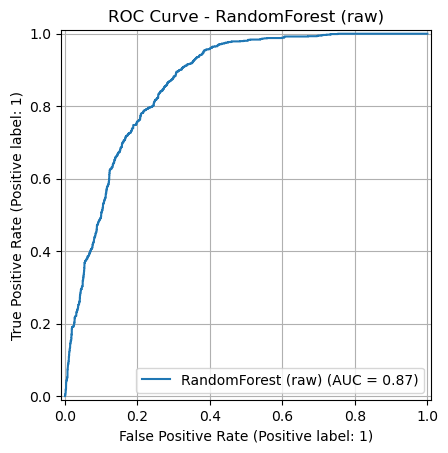

In [10]:

# 3. Predict raw probabilities
df_train["p_raw"] = model.predict_proba(df_train[features])[:, 1]
df_test["p_raw"] = model.predict_proba(df_test[features])[:, 1]
print("\n--- RAW PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test["p_raw"])
plot_roc_curve(df_test[target], df_test["p_raw"], model_name + " (raw)")

### Visualisation des différentes structures spatiales dans le temps


   MODEL: gaussian



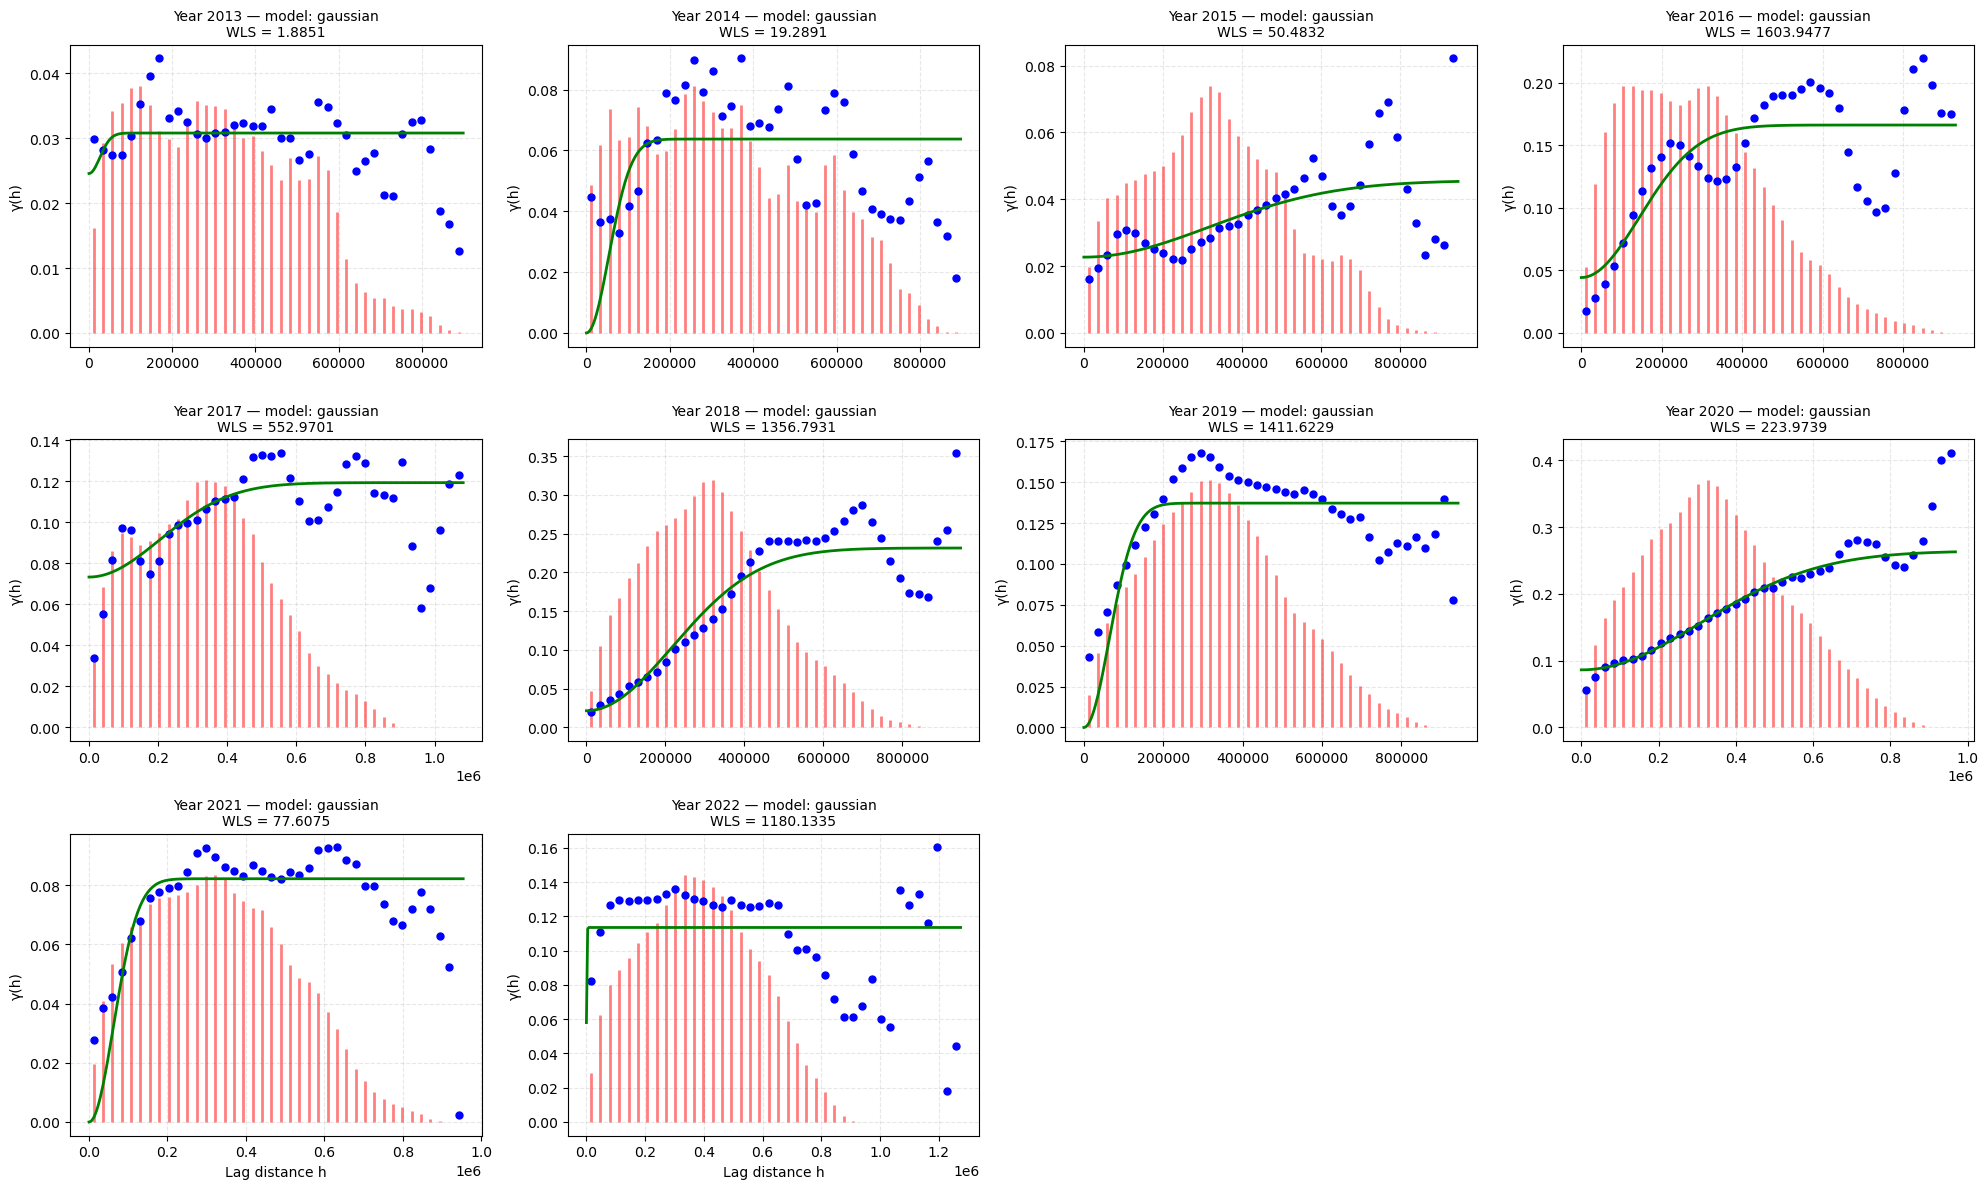


   MODEL: spherical



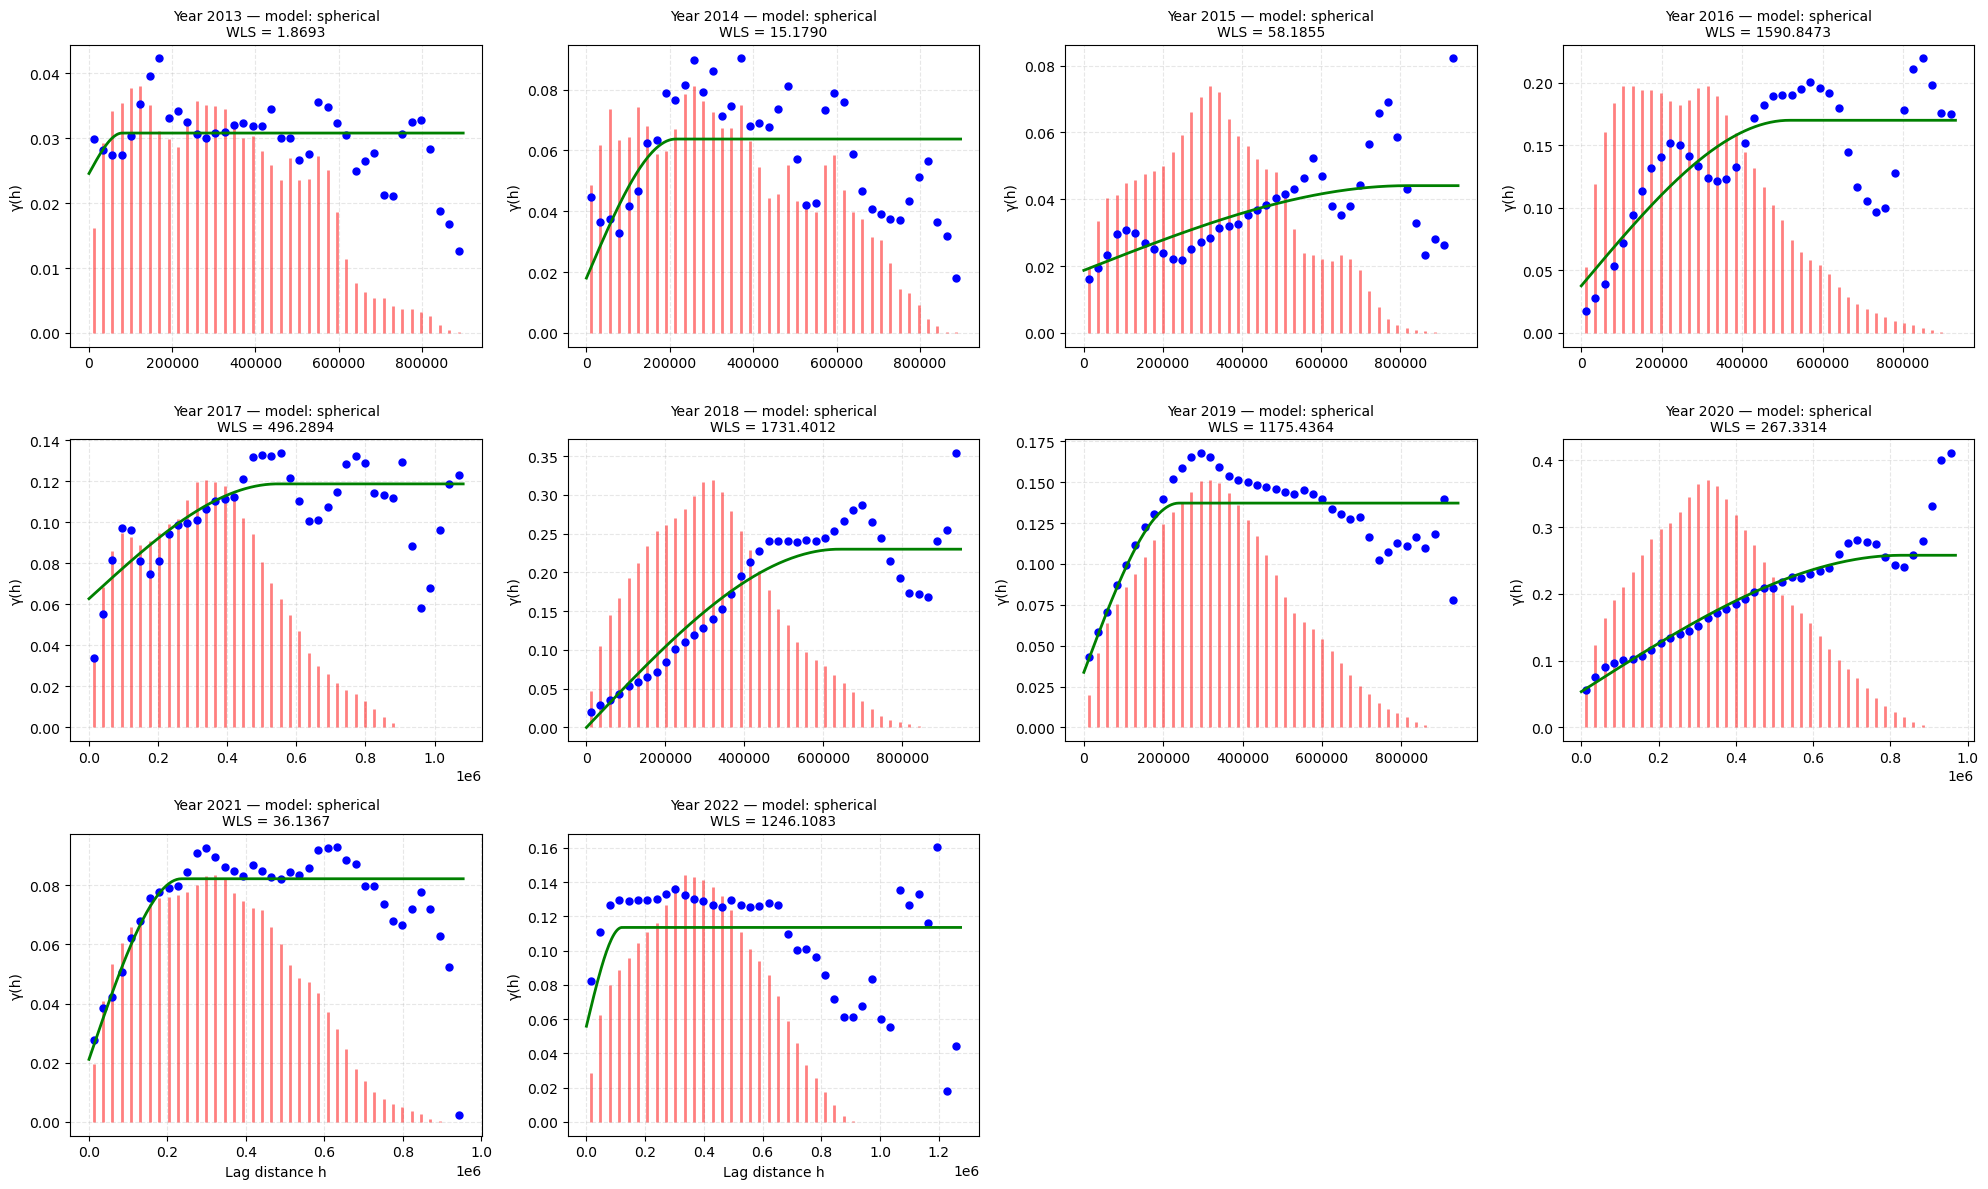


   MODEL: exponential



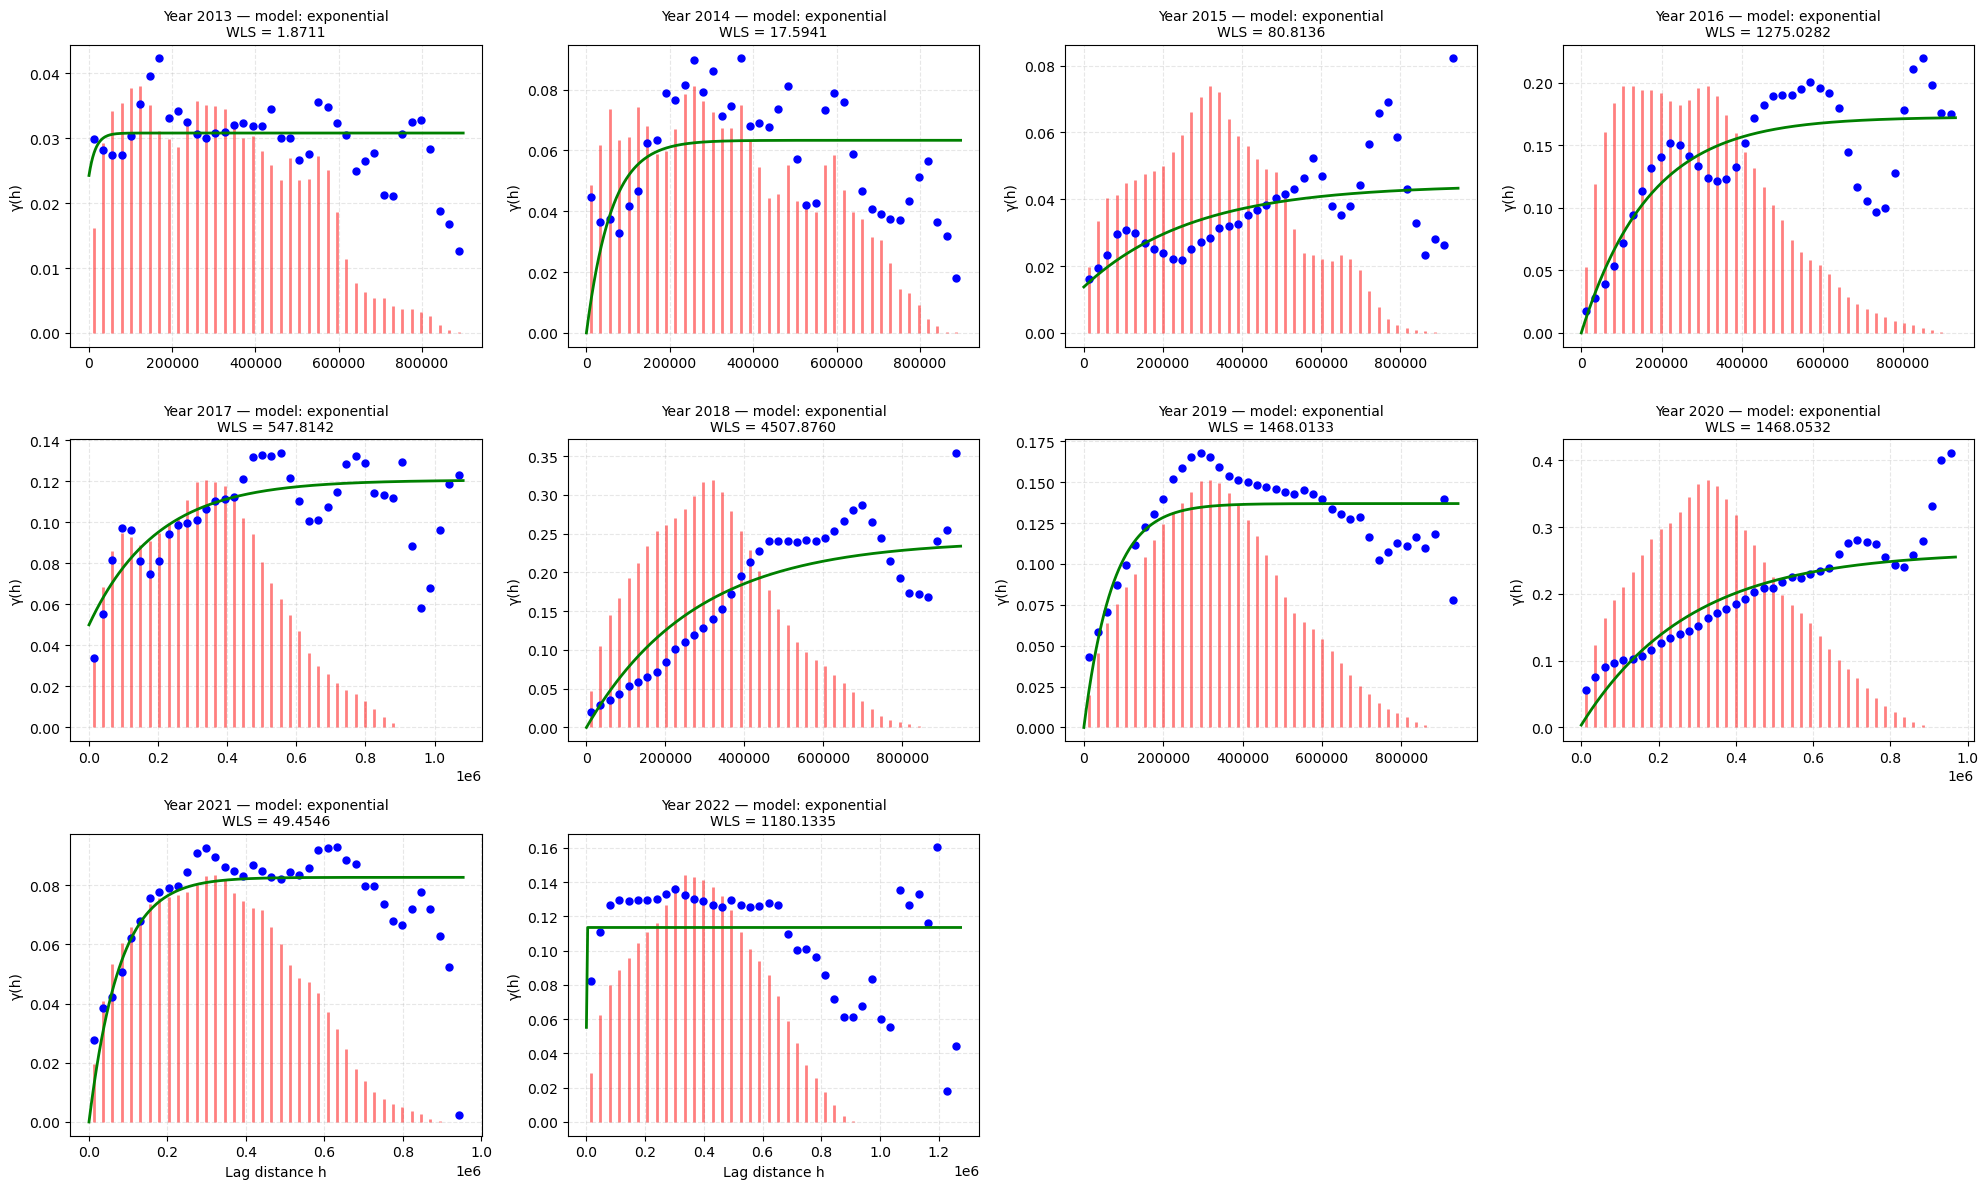


   MODEL: power



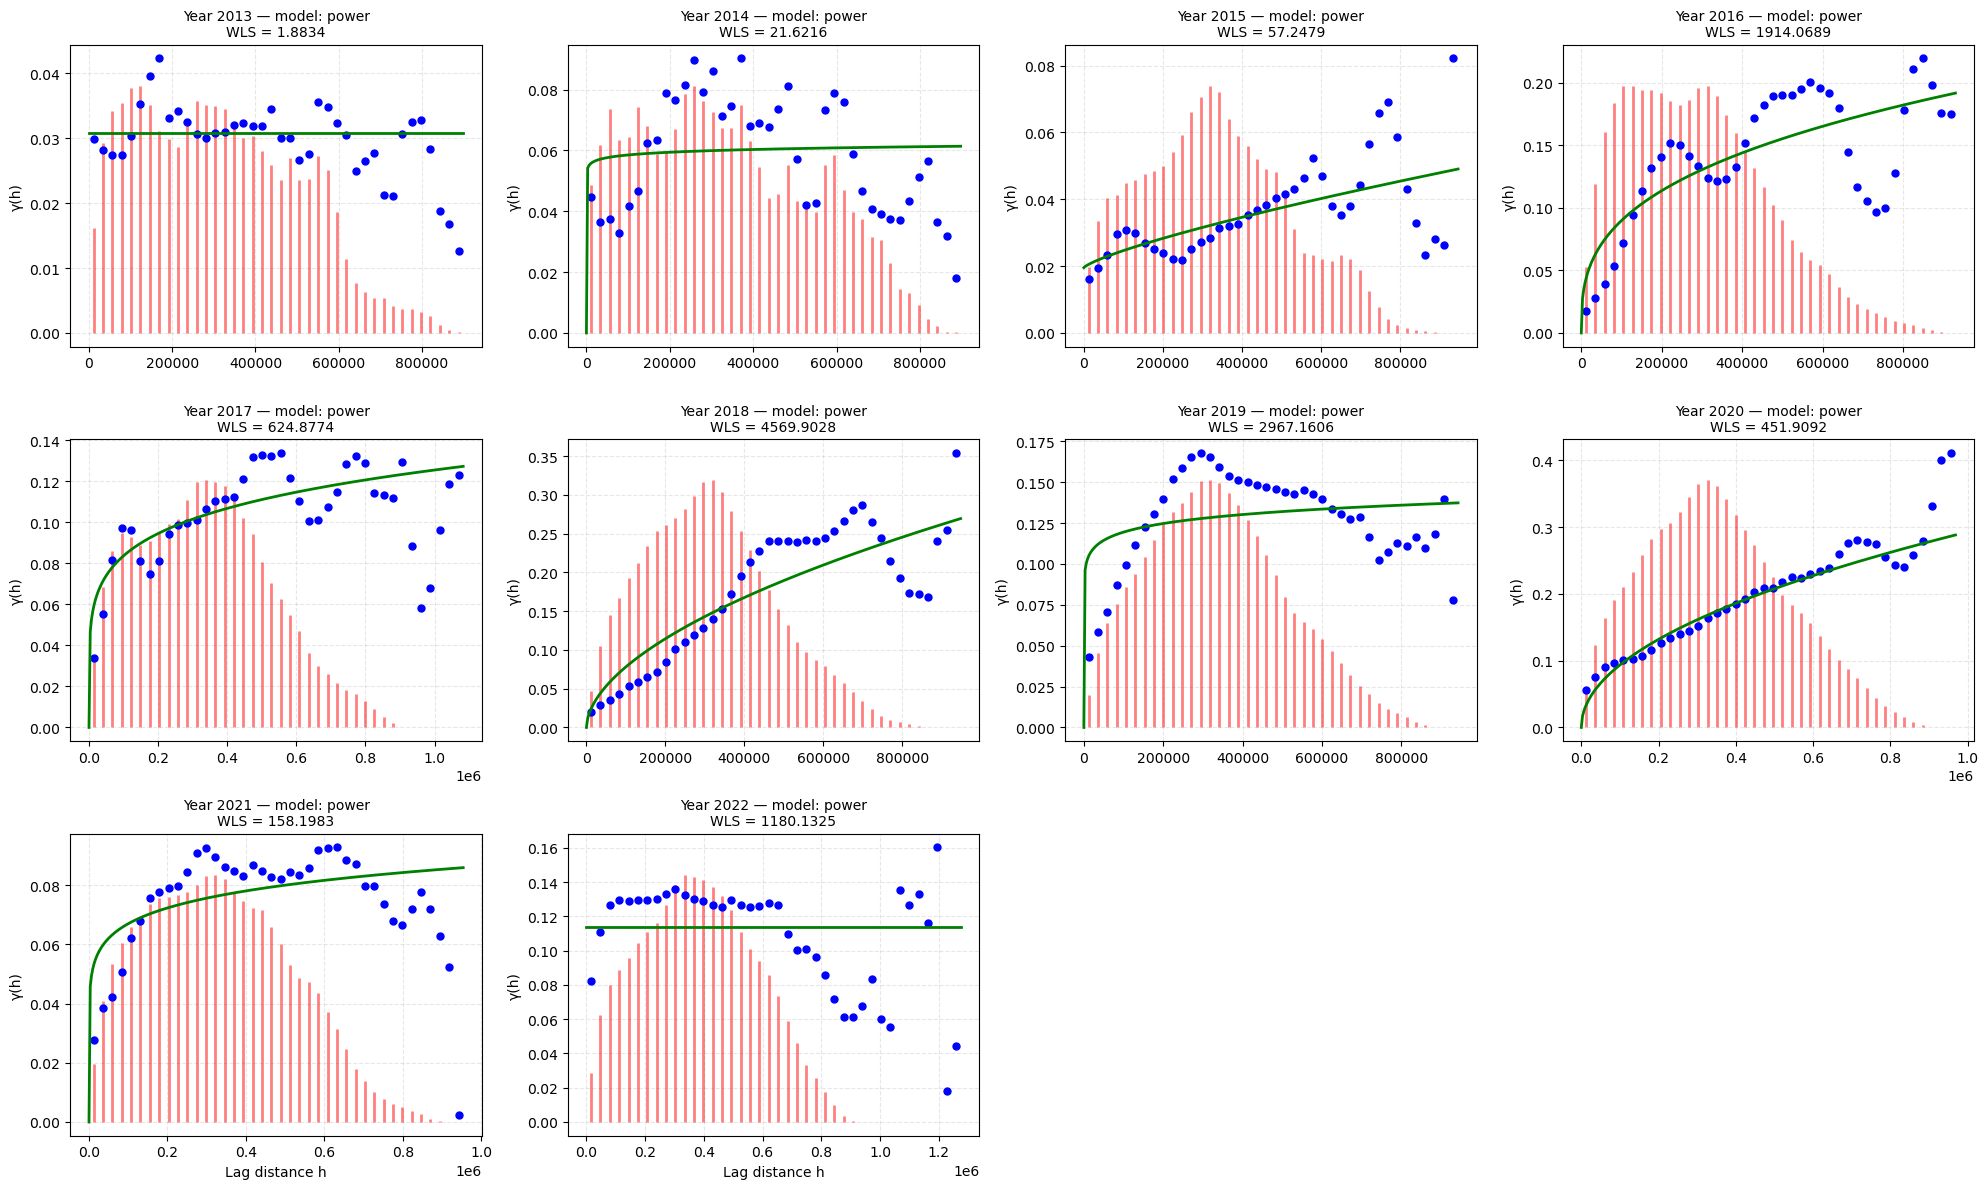


   MODEL: hole-effect



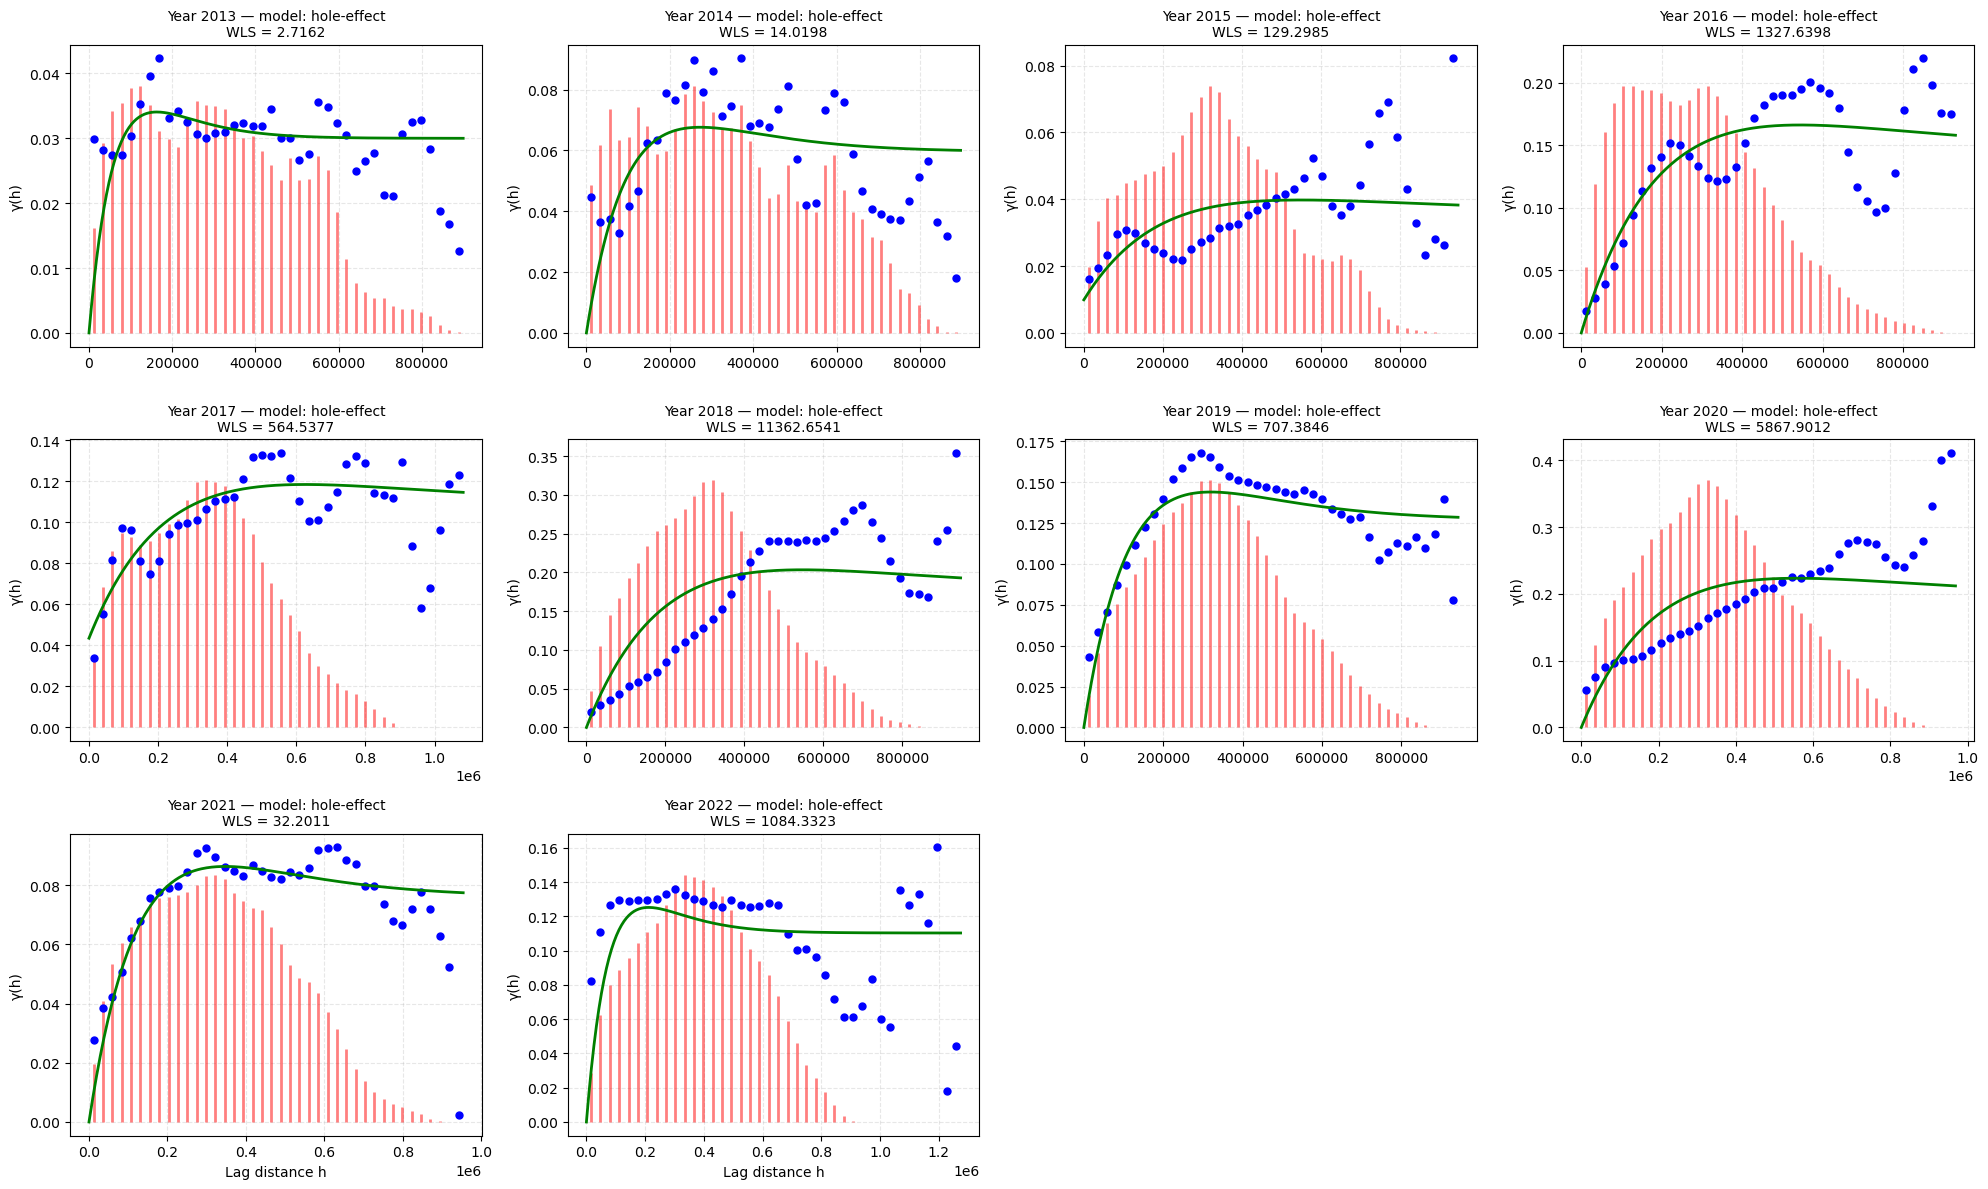


================ WLS METRIC TABLE ================

         gaussian    spherical  exponential        power  hole-effect  \
2013     1.885115     1.869311     1.871059     1.883362     2.716154   
2014    19.289087    15.179034    17.594149    21.621579    14.019799   
2015    50.483171    58.185487    80.813569    57.247912   129.298452   
2016  1603.947704  1590.847333  1275.028242  1914.068858  1327.639812   
2017    552.97012   496.289383   547.814228   624.877392    564.53773   
2018  1356.793105   1731.40124  4507.875978  4569.902848  11362.65408   
2019  1411.622936  1175.436354  1468.013338  2967.160616   707.384575   
2020   223.973873   267.331383  1468.053226   451.909201  5867.901153   
2021    77.607535     36.13672    49.454601     158.1983    32.201108   
2022  1180.133464  1246.108307  1180.133464  1180.132519  1084.332334   

       Best Model  
2013    spherical  
2014  hole-effect  
2015     gaussian  
2016  exponential  
2017    spherical  
2018     gaussian  
201

In [11]:
_ = compare_variogram_models(df_train, prob_col="p_raw", year_col=year_col,
                             n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect"))

Les résultats montrent une forte variabilité interannuelle du modèle de variogramme optimal : aucun modèle ne domine systématiquement, ce qui révèle une structure spatiale instable d’une année à l’autre. Cette hétérogénéité rend difficile l’utilisation d’un variogramme spécifique par année et suggère qu’un variogramme moyen capterait mieux la tendance spatiale globale. En stabilisant l'information, cette structure moyenne fournirait un modèle plus robuste et généralisable

### Proxi pour une structure spaciale stable dans le temps


Detected years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

=== STEP 1: Annual variograms ===


=== Mean variogram computed ===


=== STEP 2: Fitting models to mean variogram ===

Model gaussian: params=[7.38632798e-02 2.95988993e+05 4.43104826e-02] → WLS=0.001776
Model spherical: params=[8.76415588e-02 2.95988993e+05 2.90276463e-02] → WLS=0.002342
Model exponential: params=[1.05864944e-01 2.95988993e+05 1.15855464e-02] → WLS=0.002425
Model power: params=[0.00206475 0.21090091 0.07914683] → WLS=0.014116
Model hole-effect: params=[8.73777012e-02 2.95988993e+05 1.84516715e-02] → WLS=0.013343


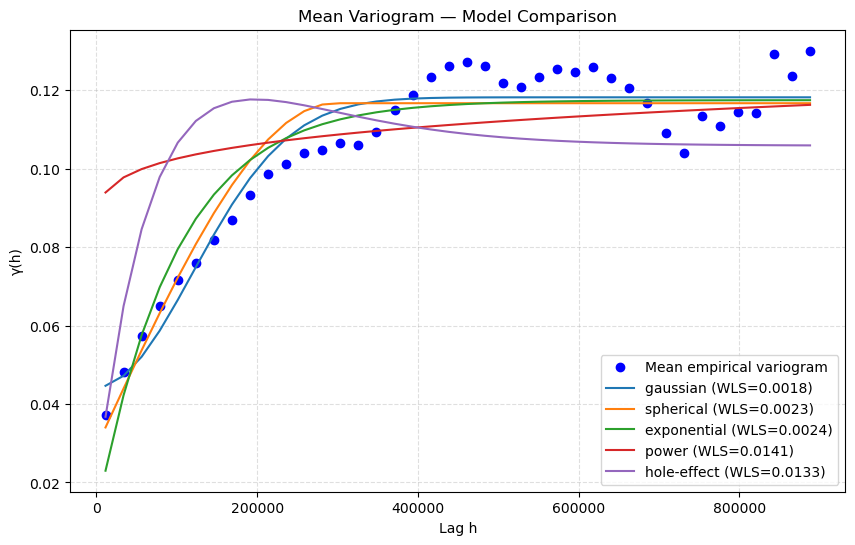


=== FINAL MODEL COMPARISON ===

                  WLS  Rank
gaussian     0.001776   1.0
spherical    0.002342   2.0
exponential  0.002425   3.0
hole-effect  0.013343   4.0
power        0.014116   5.0


In [12]:
_,_ = compare_variogram_models_with_mean(df_train, prob_col="p_raw", year_col=year_col,
                              n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect")   )

In [13]:
# 4. Mean variogram (sur TRAIN)
print("\n--- COMPUTING MEAN VARIOGRAM ---")
mean_params = compute_mean_variogram(df_train, "p_raw", year_col)



--- COMPUTING MEAN VARIOGRAM ---
[Variogram] Fitting variogram for year 2013...
[Variogram] Fitting variogram for year 2014...
[Variogram] Fitting variogram for year 2015...
[Variogram] Fitting variogram for year 2016...
[Variogram] Fitting variogram for year 2017...
[Variogram] Fitting variogram for year 2018...
[Variogram] Fitting variogram for year 2019...
[Variogram] Fitting variogram for year 2020...
[Variogram] Fitting variogram for year 2021...
[Variogram] Fitting variogram for year 2022...

=== MEAN VARIOGRAM PARAMETERS ===
Mean range  = 347065.3327
Mean sill   = 0.0919
Mean nugget = 0.0334



--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---
[Kriging] Fitting Kriging for year 2013 with mean variogram.
[Kriging] Fitting Kriging for year 2014 with mean variogram.
[Kriging] Fitting Kriging for year 2015 with mean variogram.
[Kriging] Fitting Kriging for year 2016 with mean variogram.
[Kriging] Fitting Kriging for year 2017 with mean variogram.
[Kriging] Fitting Kriging for year 2018 with mean variogram.
[Kriging] Fitting Kriging for year 2019 with mean variogram.
[Kriging] Fitting Kriging for year 2020 with mean variogram.
[Kriging] Fitting Kriging for year 2021 with mean variogram.
[Kriging] Fitting Kriging for year 2022 with mean variogram.

--- APPLYING SPATIAL CORRECTION (TEST) ---

--- CORRECTED PROBABILITY METRICS (TEST) ---

---------------- Metrics ----------------
AUC : 0.8660638651665651

Confusion Matrix:
[[3354 1361]
 [ 154 1029]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82      

<Figure size 600x500 with 0 Axes>

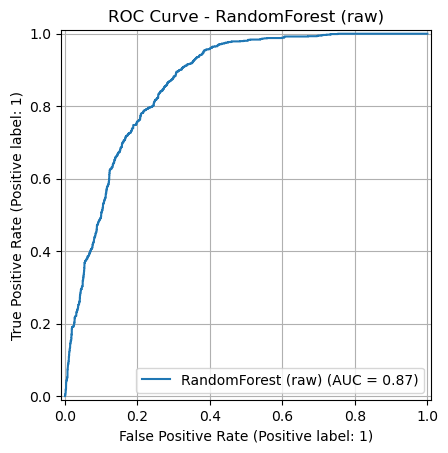

In [14]:

# 5. Kriging par année avec variogramme moyen (sur TRAIN)
print("\n--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---")
kriging_models = fit_kriging_with_mean_variogram(
    df_train, "p_raw", mean_params, year_col
)
# 6. Application de la correction spatiale sur le TEST
print("\n--- APPLYING SPATIAL CORRECTION (TEST) ---")
df_test_corr = apply_kriging_by_year(
    df_test, "p_raw", kriging_models, year_col
)
print("\n--- CORRECTED PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test_corr["p_corr"])
plot_roc_curve(df_test[target], df_test_corr["p_corr"], model_name + " (raw)")


In [ ]:
results = run_pipeline(df, features, target, model_name, year_col, test_years=test_years)

### ***Logistique***

In [18]:
model_name_1 = "Logistic"
L_model = get_model(model_name_1)
print(f"\n======== SELECTED MODEL: {model_name_1} ========")


======== SELECTED MODEL: Logistic ========


In [19]:

# 2. Train ML
print("\n--- TRAINING MODEL ---")
L_model.fit(df_train[features], df_train[target])


--- TRAINING MODEL ---


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'



--- RAW PROBABILITY METRICS (TEST) ---

---------------- Metrics ----------------
AUC : 0.8665112601730596

Confusion Matrix:
[[3519 1196]
 [ 110 1073]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.75      0.84      4715
           1       0.47      0.91      0.62      1183

    accuracy                           0.78      5898
   macro avg       0.72      0.83      0.73      5898
weighted avg       0.87      0.78      0.80      5898



<Figure size 600x500 with 0 Axes>

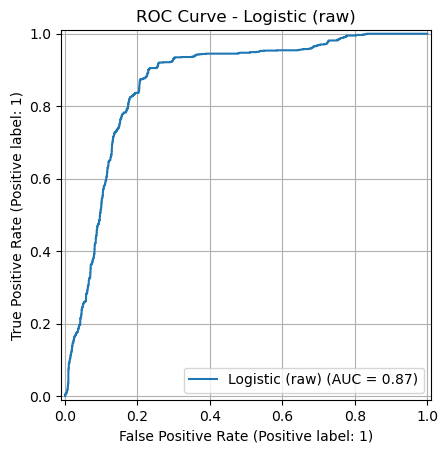

In [20]:

# 3. Predict raw probabilities
df_train["p_raw"] = L_model.predict_proba(df_train[features])[:, 1]
df_test["p_raw"] = L_model.predict_proba(df_test[features])[:, 1]
print("\n--- RAW PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test["p_raw"])
plot_roc_curve(df_test[target], df_test["p_raw"], model_name_1 + " (raw)")


   MODEL: gaussian



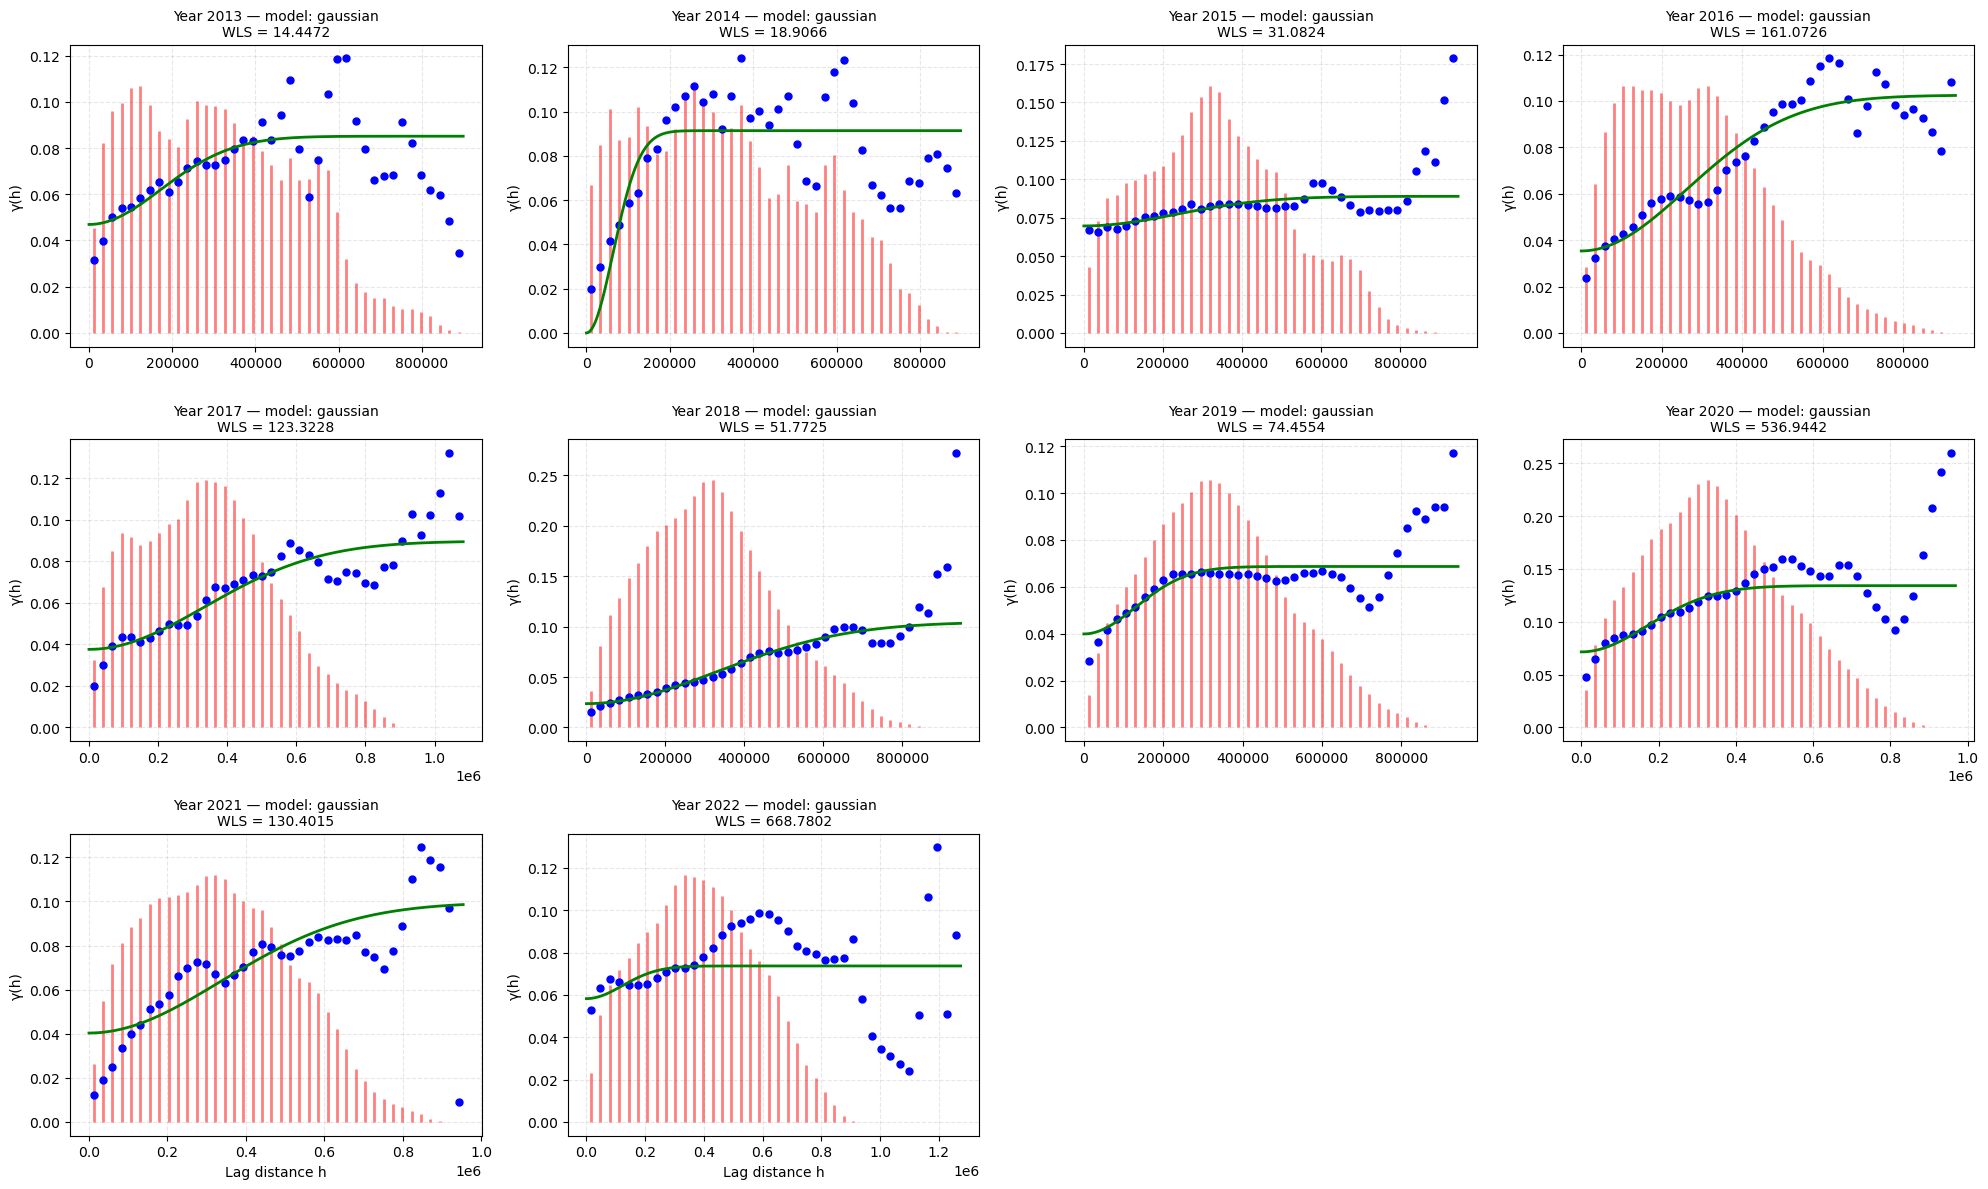


   MODEL: spherical



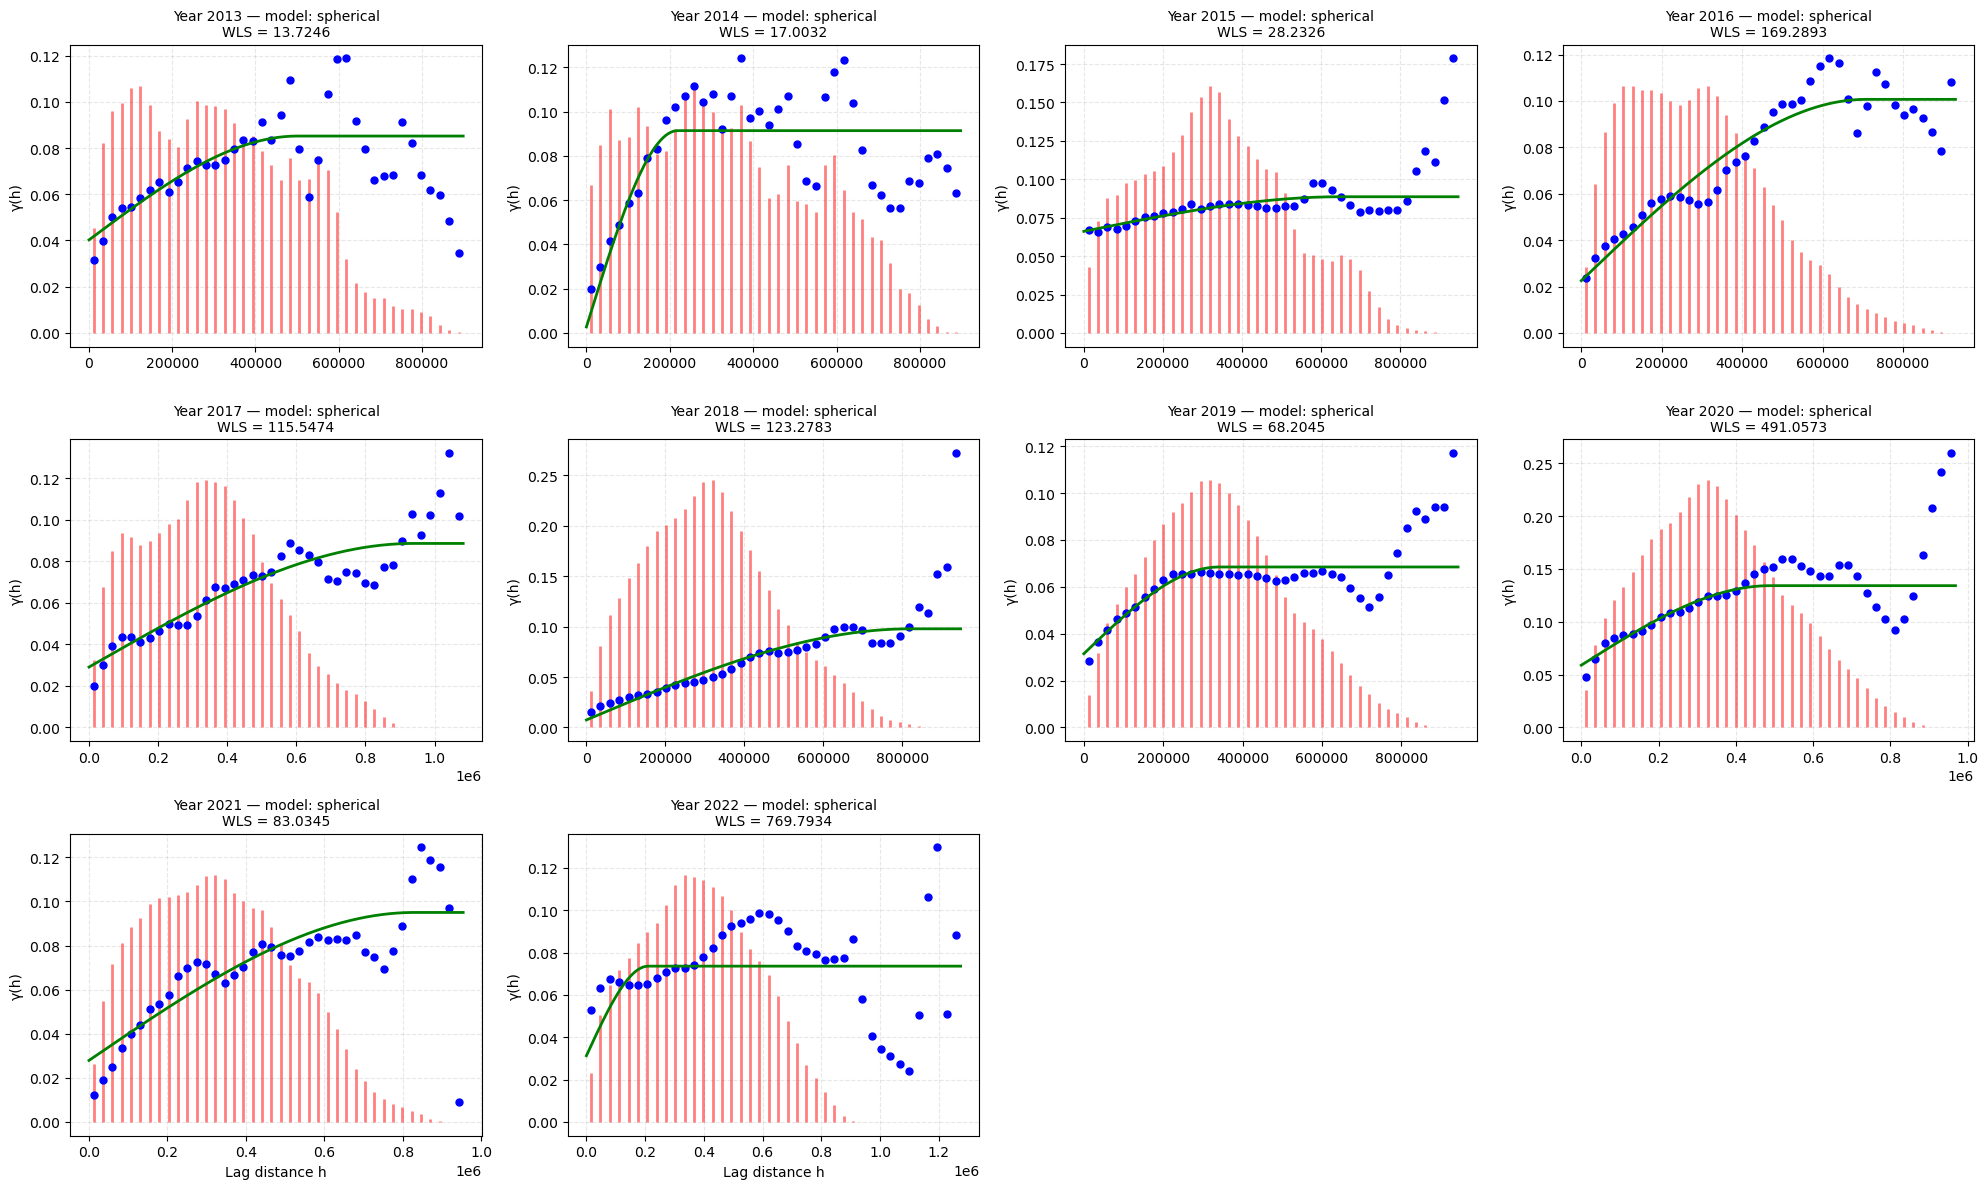


   MODEL: exponential



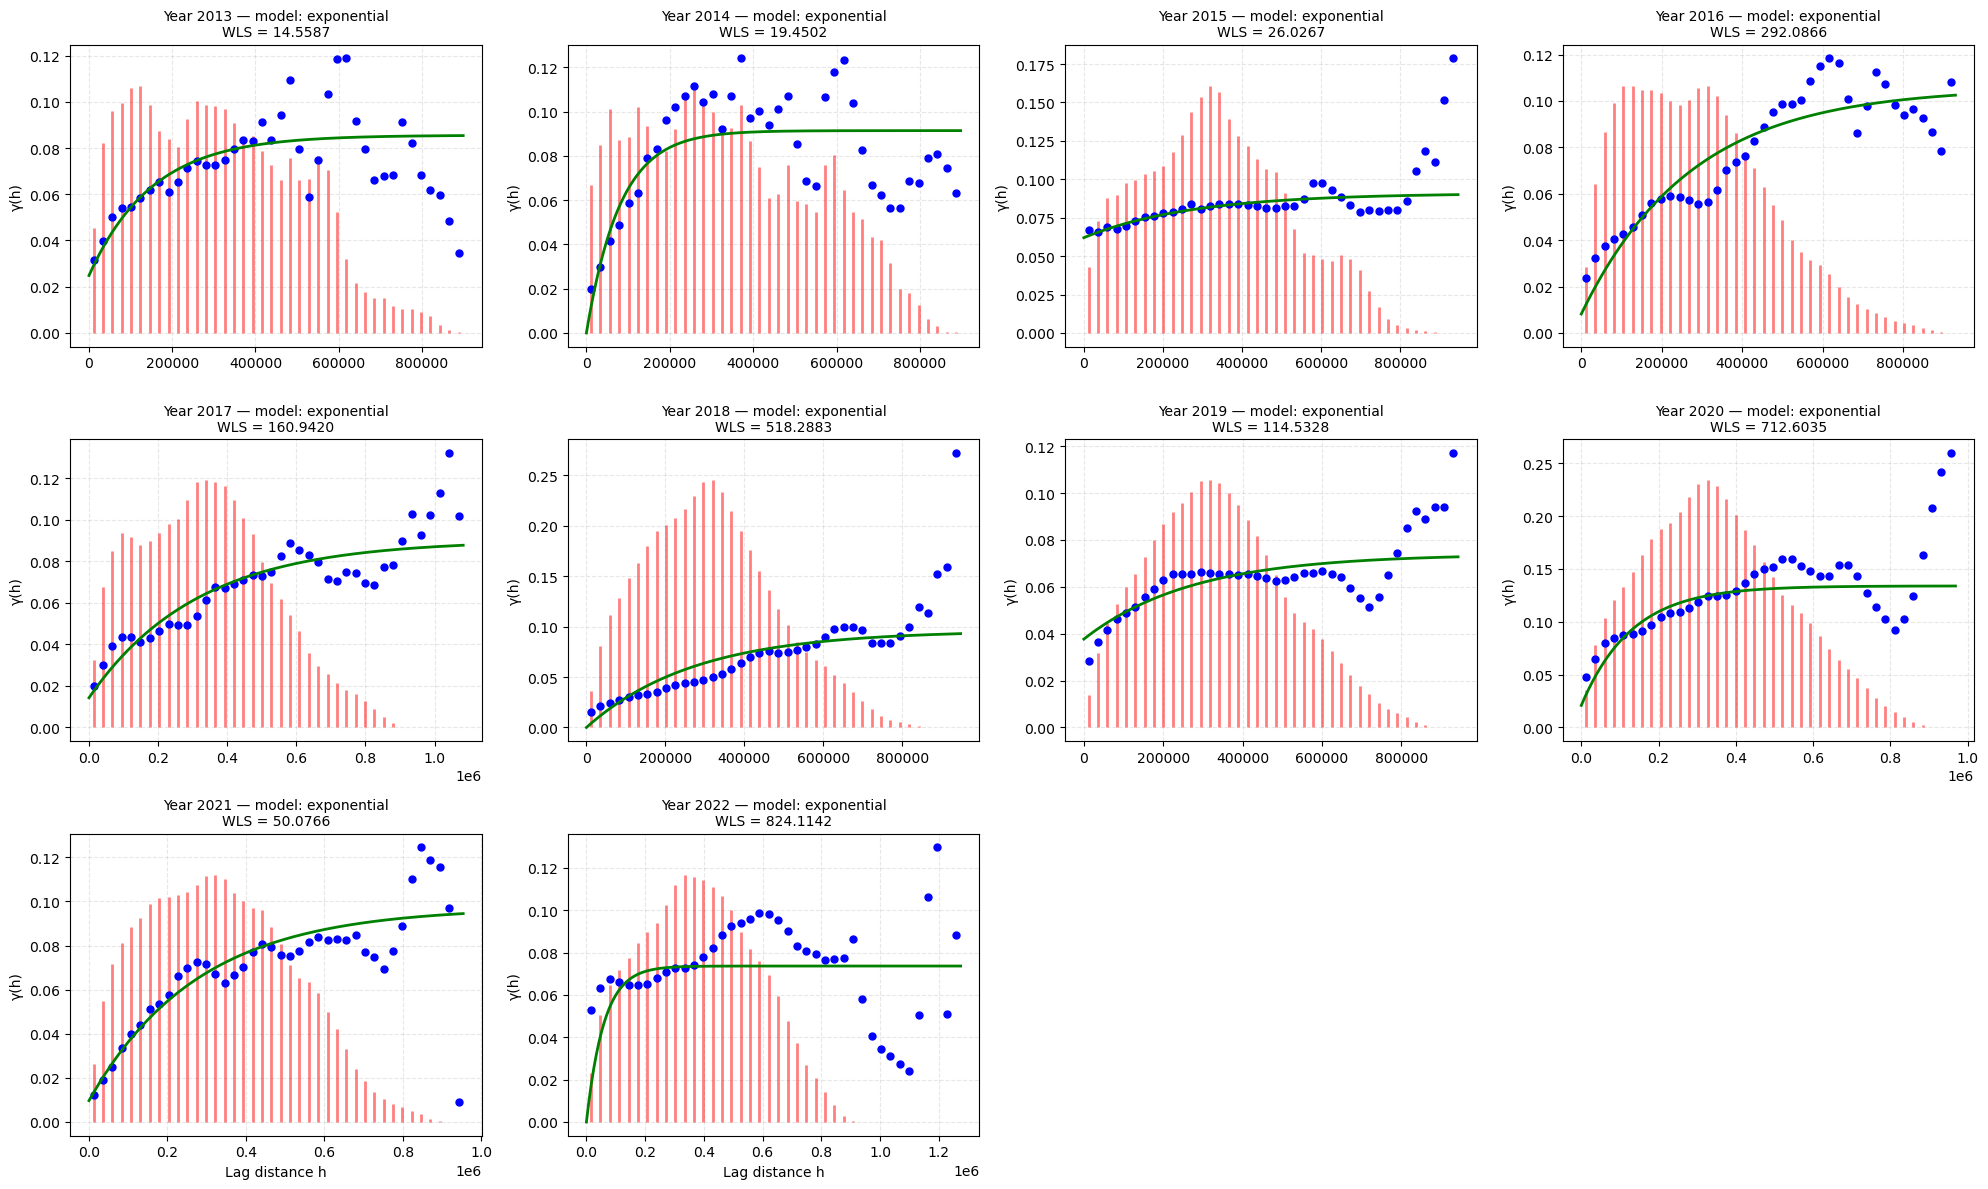


   MODEL: power



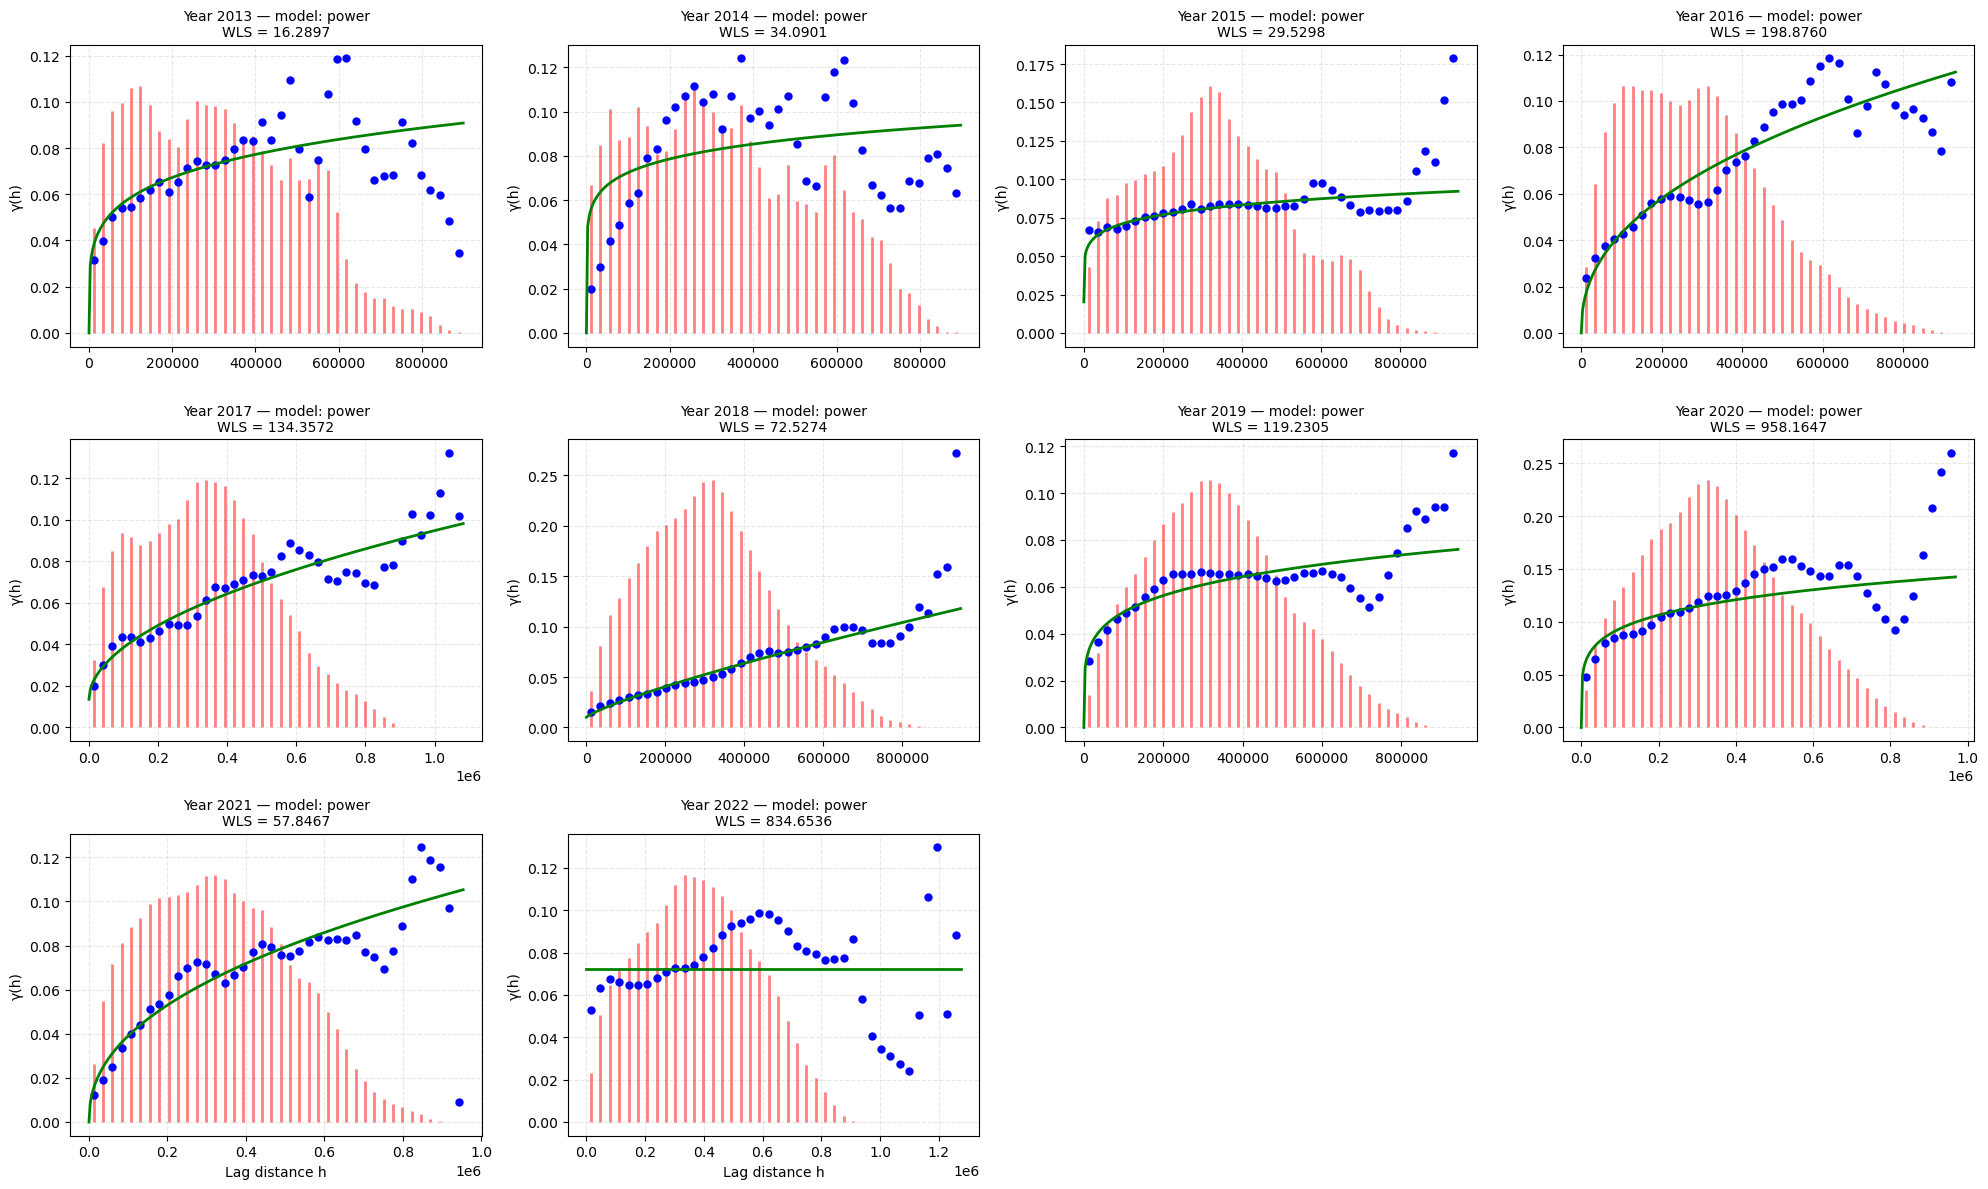


   MODEL: hole-effect



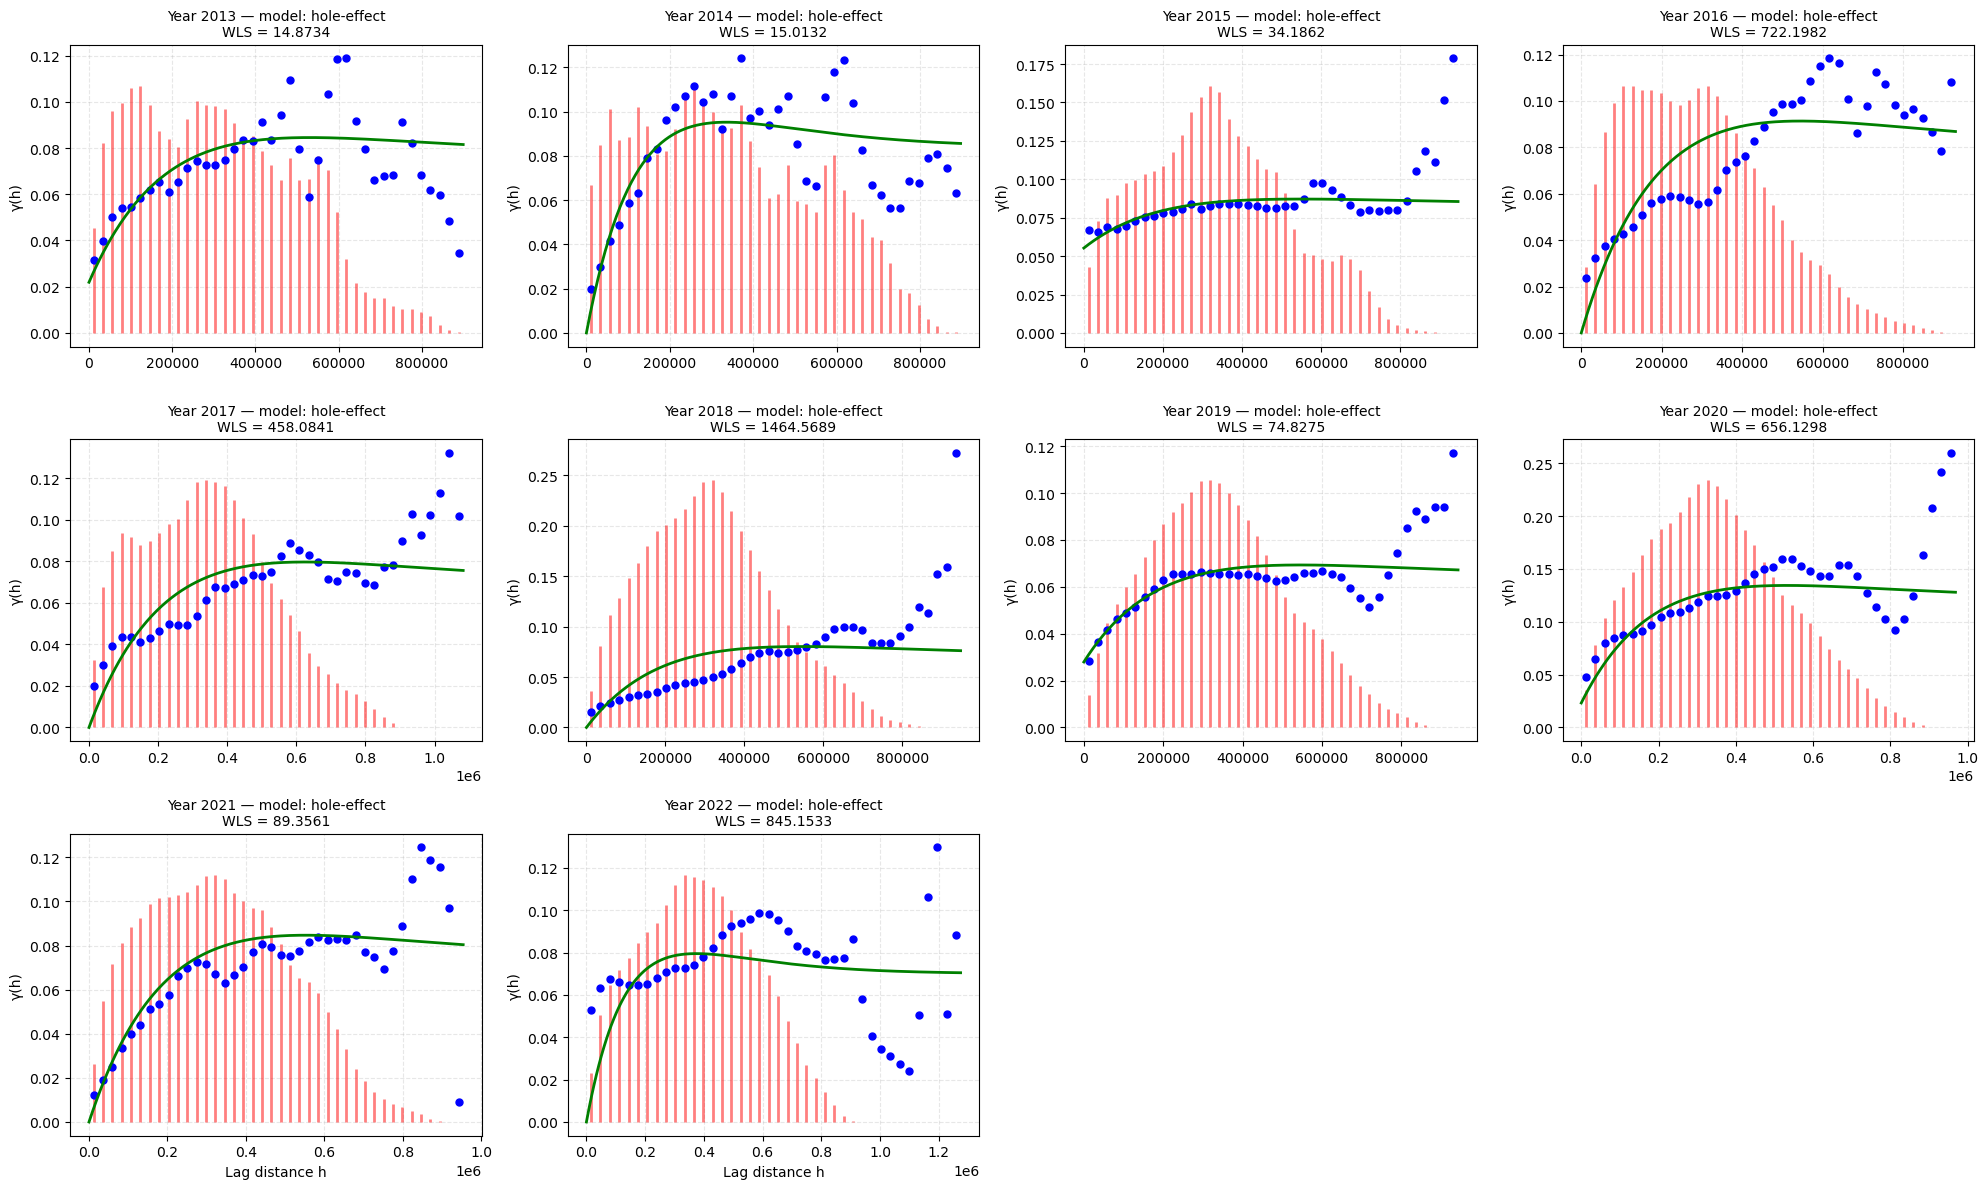


================ WLS METRIC TABLE ================

        gaussian   spherical exponential       power  hole-effect   Best Model
2013     14.4472   13.724636   14.558704    16.28974    14.873413    spherical
2014   18.906553   17.003208   19.450233   34.090069    15.013202  hole-effect
2015   31.082424   28.232635   26.026653   29.529824    34.186212  exponential
2016   161.07265  169.289314   292.08661  198.875992   722.198184     gaussian
2017   123.32284  115.547395  160.942006  134.357153   458.084112    spherical
2018   51.772533  123.278341  518.288298   72.527394  1464.568924     gaussian
2019   74.455398    68.20446  114.532849  119.230458    74.827478    spherical
2020  536.944186  491.057348  712.603483  958.164686   656.129837    spherical
2021  130.401539    83.03445   50.076621    57.84673    89.356095  exponential
2022  668.780167  769.793355  824.114184  834.653581   845.153326     gaussian


In [21]:

_ = compare_variogram_models(df_train, prob_col="p_raw", year_col=year_col,
                             n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect"))


Detected years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

=== STEP 1: Annual variograms ===


=== Mean variogram computed ===


=== STEP 2: Fitting models to mean variogram ===

Model gaussian: params=[5.41904573e-02 2.95988993e+05 3.52414538e-02] → WLS=0.004432
Model spherical: params=[6.34402792e-02 2.95988993e+05 2.47818994e-02] → WLS=0.005009
Model exponential: params=[7.71789564e-02 2.95988993e+05 1.16686989e-02] → WLS=0.004910
Model power: params=[0.00466524 0.19227209 0.02799409] → WLS=0.006181
Model hole-effect: params=[5.63000496e-02 2.95988993e+05 2.40781252e-02] → WLS=0.011654


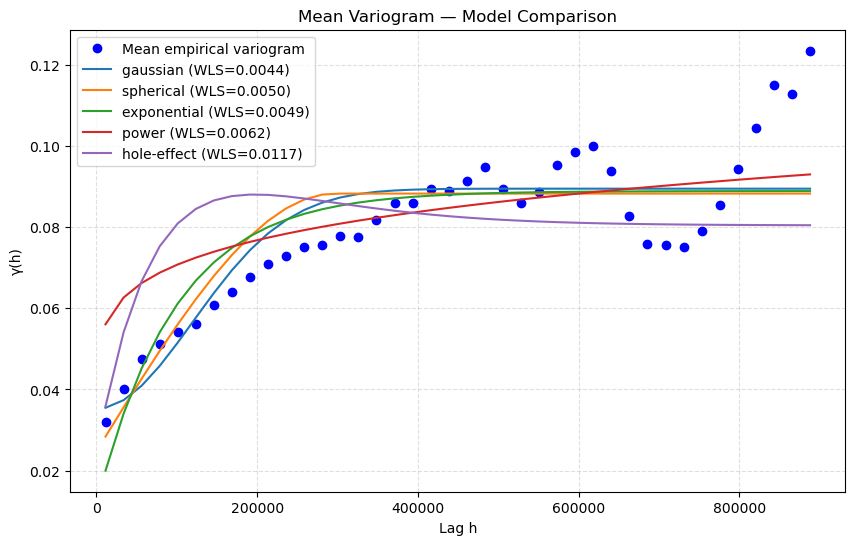


=== FINAL MODEL COMPARISON ===

                  WLS  Rank
gaussian     0.004432   1.0
exponential  0.004910   2.0
spherical    0.005009   3.0
power        0.006181   4.0
hole-effect  0.011654   5.0


In [22]:

_,_ = compare_variogram_models_with_mean(df_train, prob_col="p_raw", year_col=year_col,
                              n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect")   )

In [23]:

# 4. Mean variogram (sur TRAIN)
print("\n--- COMPUTING MEAN VARIOGRAM ---")
mean_params = compute_mean_variogram(df_train, "p_raw", year_col)



--- COMPUTING MEAN VARIOGRAM ---
[Variogram] Fitting variogram for year 2013...
[Variogram] Fitting variogram for year 2014...
[Variogram] Fitting variogram for year 2015...
[Variogram] Fitting variogram for year 2016...
[Variogram] Fitting variogram for year 2017...
[Variogram] Fitting variogram for year 2018...
[Variogram] Fitting variogram for year 2019...
[Variogram] Fitting variogram for year 2020...
[Variogram] Fitting variogram for year 2021...
[Variogram] Fitting variogram for year 2022...

=== MEAN VARIOGRAM PARAMETERS ===
Mean range  = 540351.7203
Mean sill   = 0.0521
Mean nugget = 0.0422



--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---
[Kriging] Fitting Kriging for year 2013 with mean variogram.
[Kriging] Fitting Kriging for year 2014 with mean variogram.
[Kriging] Fitting Kriging for year 2015 with mean variogram.
[Kriging] Fitting Kriging for year 2016 with mean variogram.
[Kriging] Fitting Kriging for year 2017 with mean variogram.
[Kriging] Fitting Kriging for year 2018 with mean variogram.
[Kriging] Fitting Kriging for year 2019 with mean variogram.
[Kriging] Fitting Kriging for year 2020 with mean variogram.
[Kriging] Fitting Kriging for year 2021 with mean variogram.
[Kriging] Fitting Kriging for year 2022 with mean variogram.

--- APPLYING SPATIAL CORRECTION (TEST) ---

--- CORRECTED PROBABILITY METRICS (TEST) ---

---------------- Metrics ----------------
AUC : 0.8665112601730596

Confusion Matrix:
[[3519 1196]
 [ 110 1073]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.75      0.84      

<Figure size 600x500 with 0 Axes>

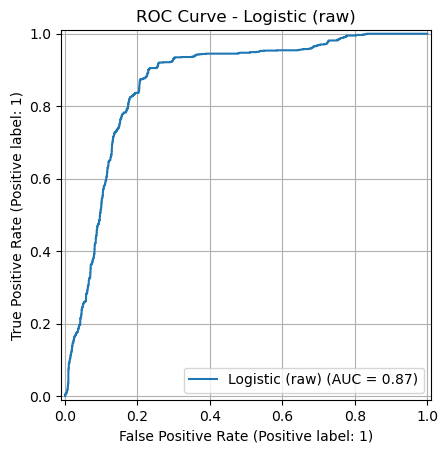

In [25]:

# 5. Kriging par année avec variogramme moyen (sur TRAIN)
print("\n--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---")
kriging_models = fit_kriging_with_mean_variogram(
    df_train, "p_raw", mean_params, year_col
)
# 6. Application de la correction spatiale sur le TEST
print("\n--- APPLYING SPATIAL CORRECTION (TEST) ---")
df_test_corr = apply_kriging_by_year(
    df_test, "p_raw", kriging_models, year_col
)
print("\n--- CORRECTED PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test_corr["p_corr"])
plot_roc_curve(df_test[target], df_test_corr["p_corr"], model_name_1 + " (raw)")


### ***SVM***

In [7]:
model_name_2 = "SVM"
S_model = get_model(model_name_2)
print(f"\n======== SELECTED MODEL: {model_name_2} ========")


======== SELECTED MODEL: SVM ========


In [8]:
# 2. Train ML
print("\n--- TRAINING MODEL ---")
S_model.fit(df_train[features], df_train[target])


--- TRAINING MODEL ---


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False



--- RAW PROBABILITY METRICS (TEST) ---

---------------- Metrics ----------------
AUC : 0.8405741823231015

Confusion Matrix:
[[3148 1567]
 [ 171 1012]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.67      0.78      4715
           1       0.39      0.86      0.54      1183

    accuracy                           0.71      5898
   macro avg       0.67      0.76      0.66      5898
weighted avg       0.84      0.71      0.73      5898



<Figure size 600x500 with 0 Axes>

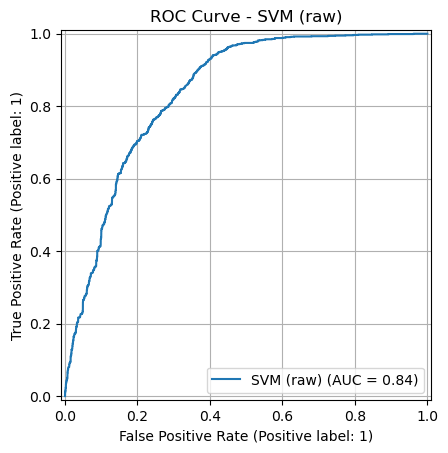

In [9]:
# 3. Predict raw probabilities
df_train["p_raw"] = S_model.predict_proba(df_train[features])[:, 1]
df_test["p_raw"] = S_model.predict_proba(df_test[features])[:, 1]
print("\n--- RAW PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test["p_raw"])
plot_roc_curve(df_test[target], df_test["p_raw"], model_name_2 + " (raw)")


   MODEL: gaussian



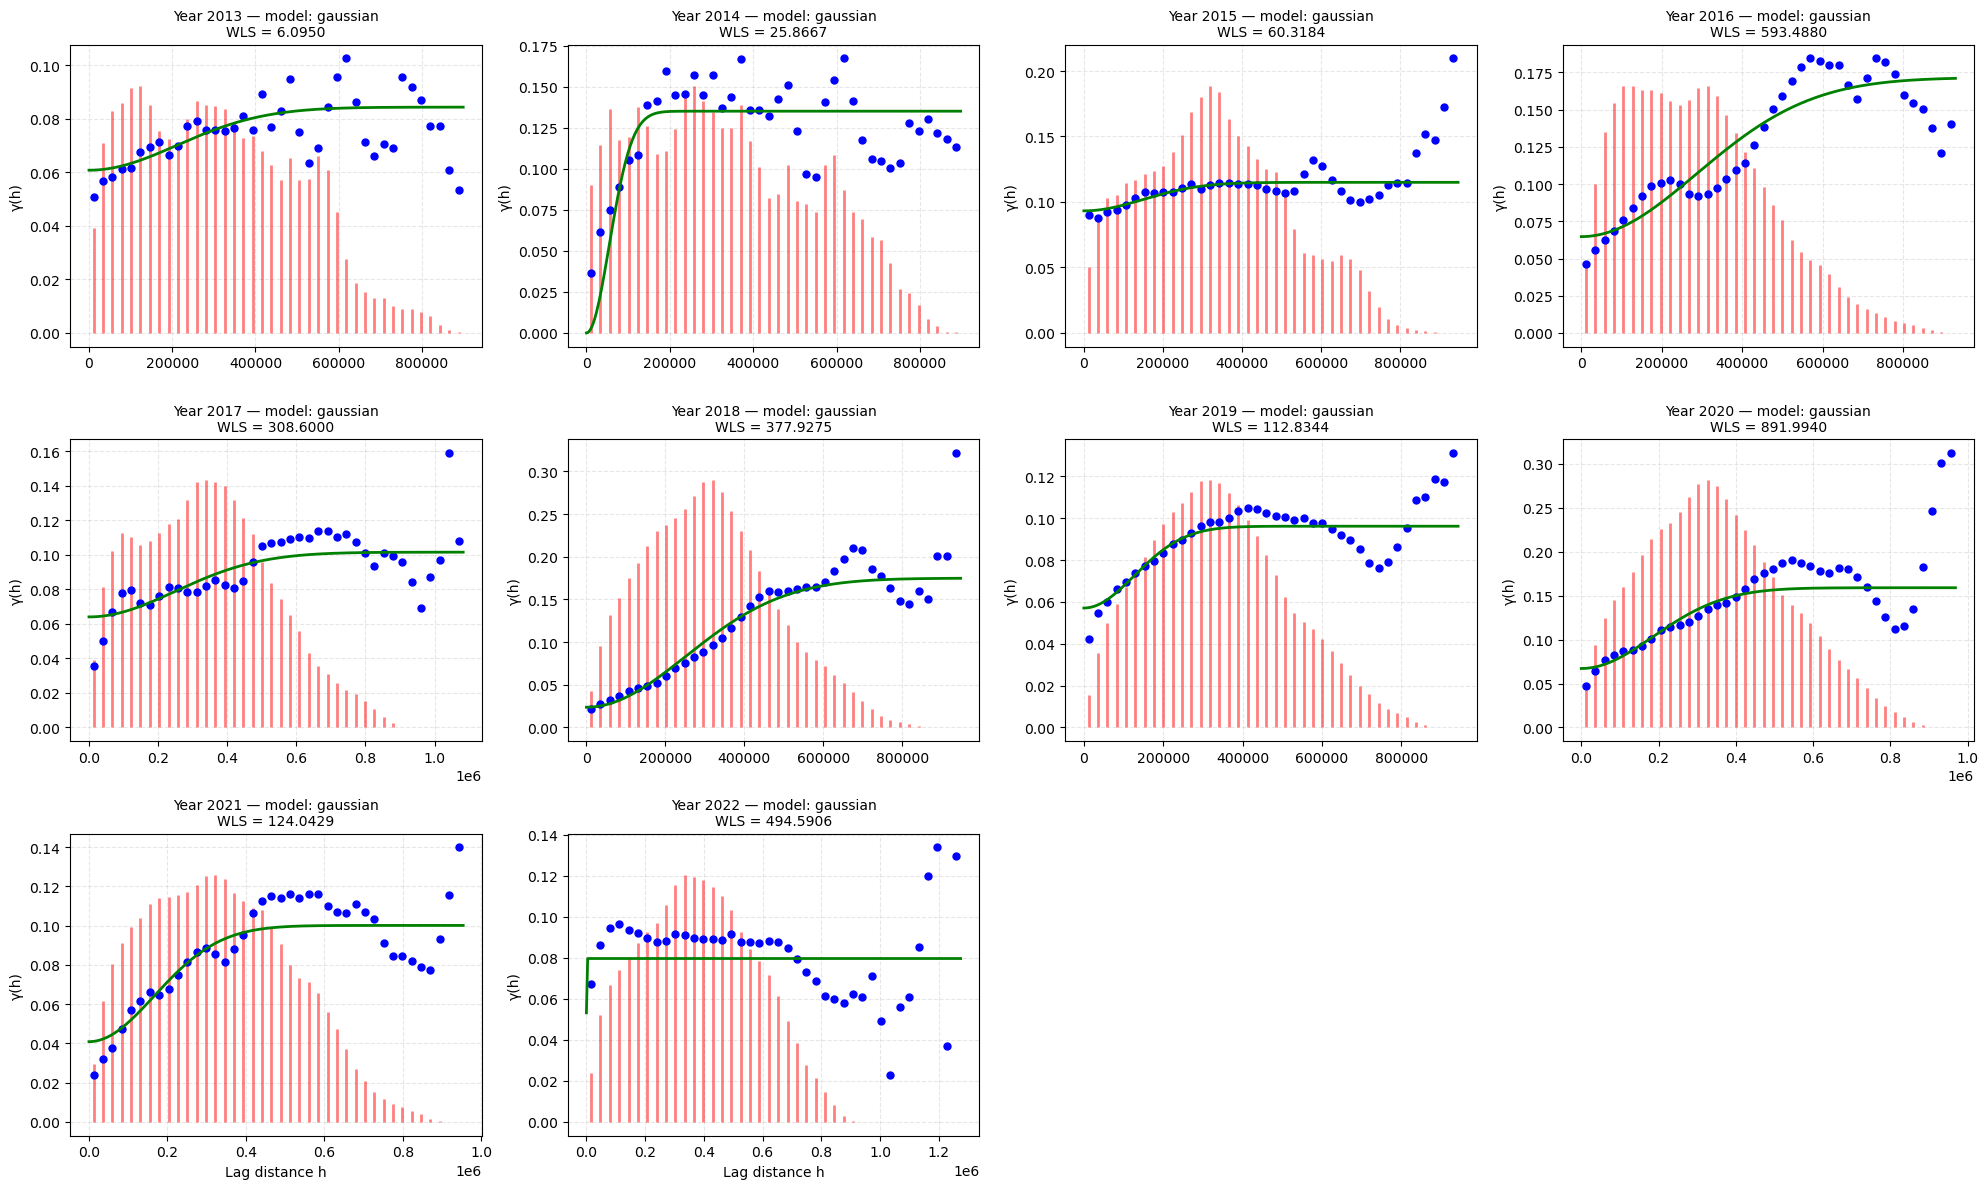


   MODEL: spherical



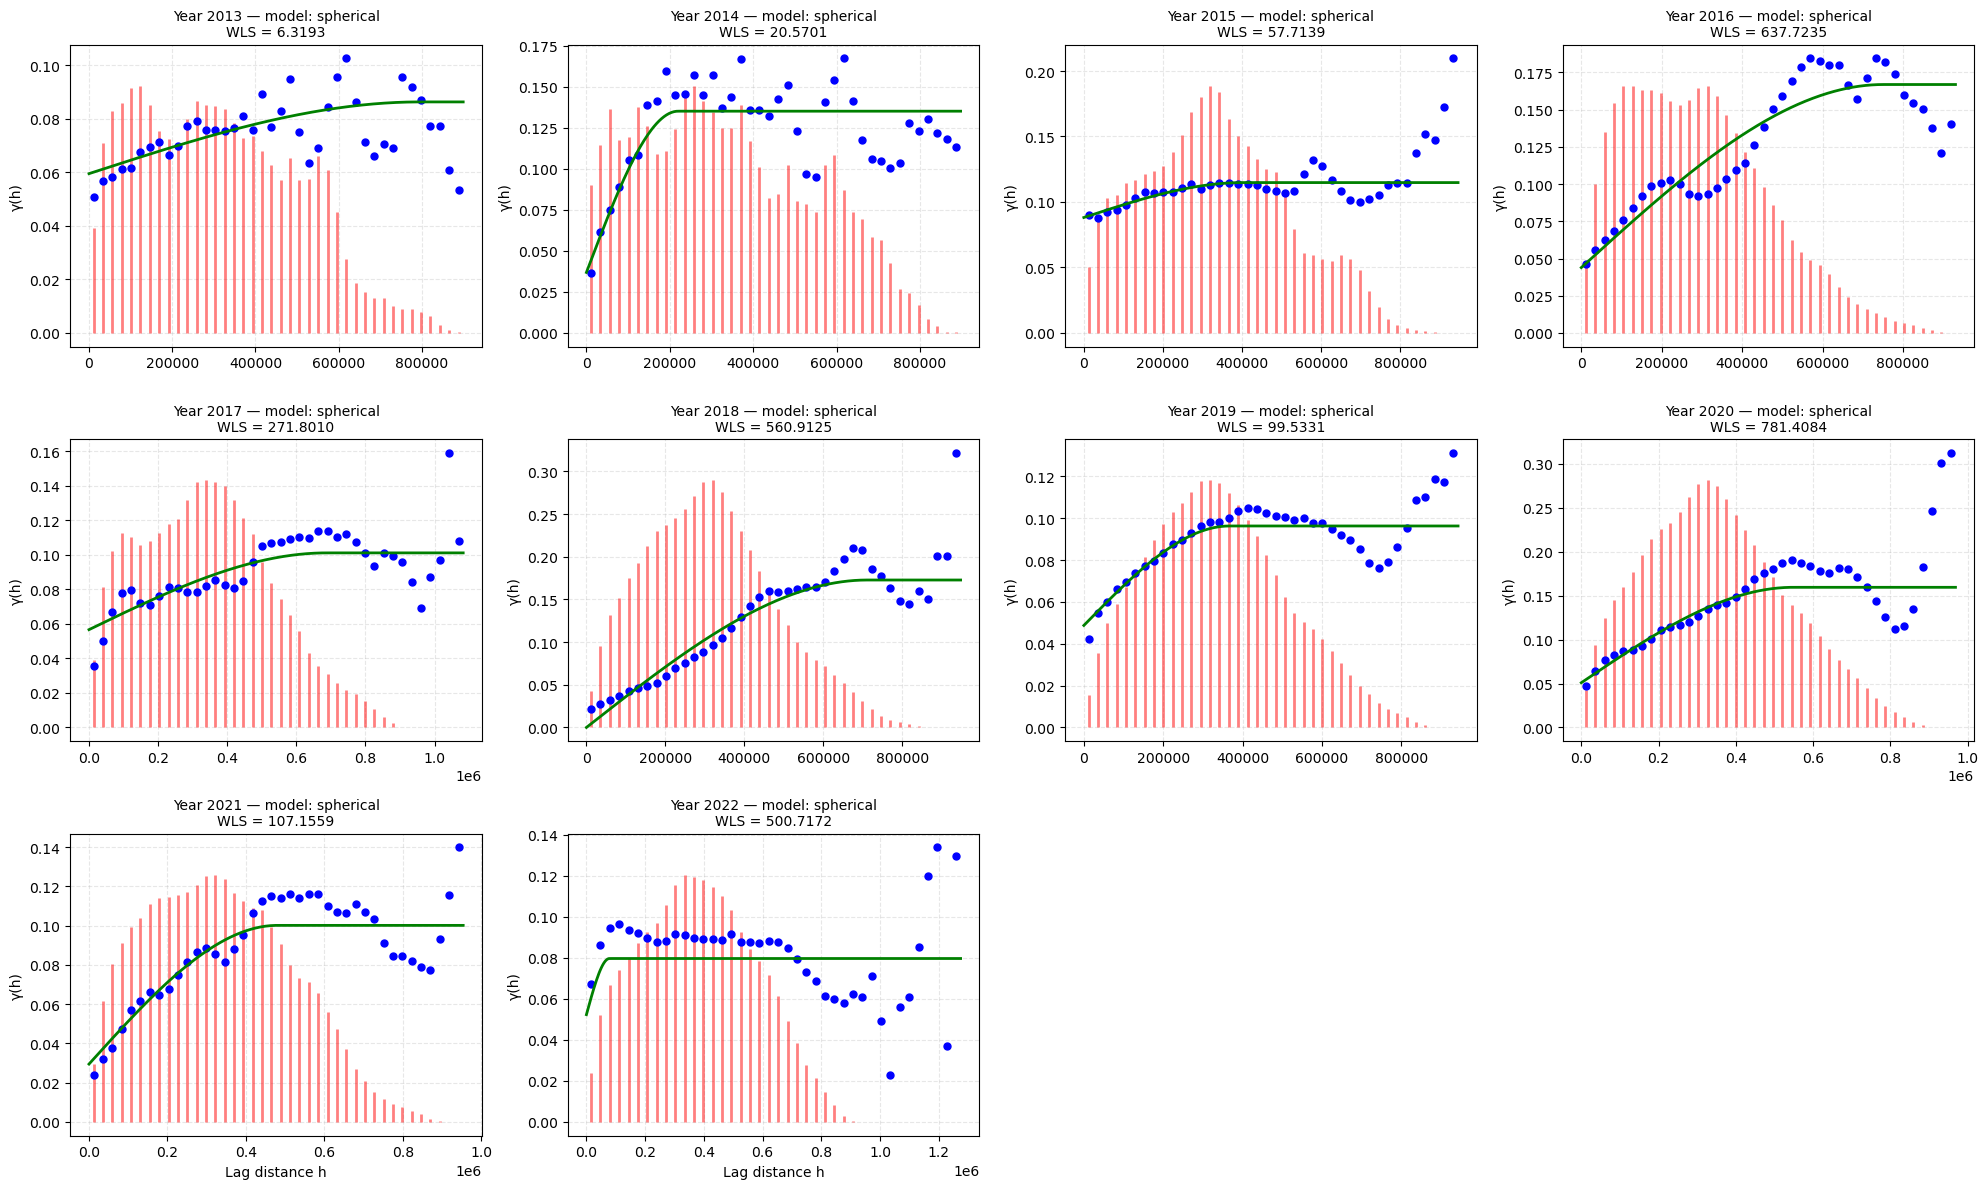


   MODEL: exponential



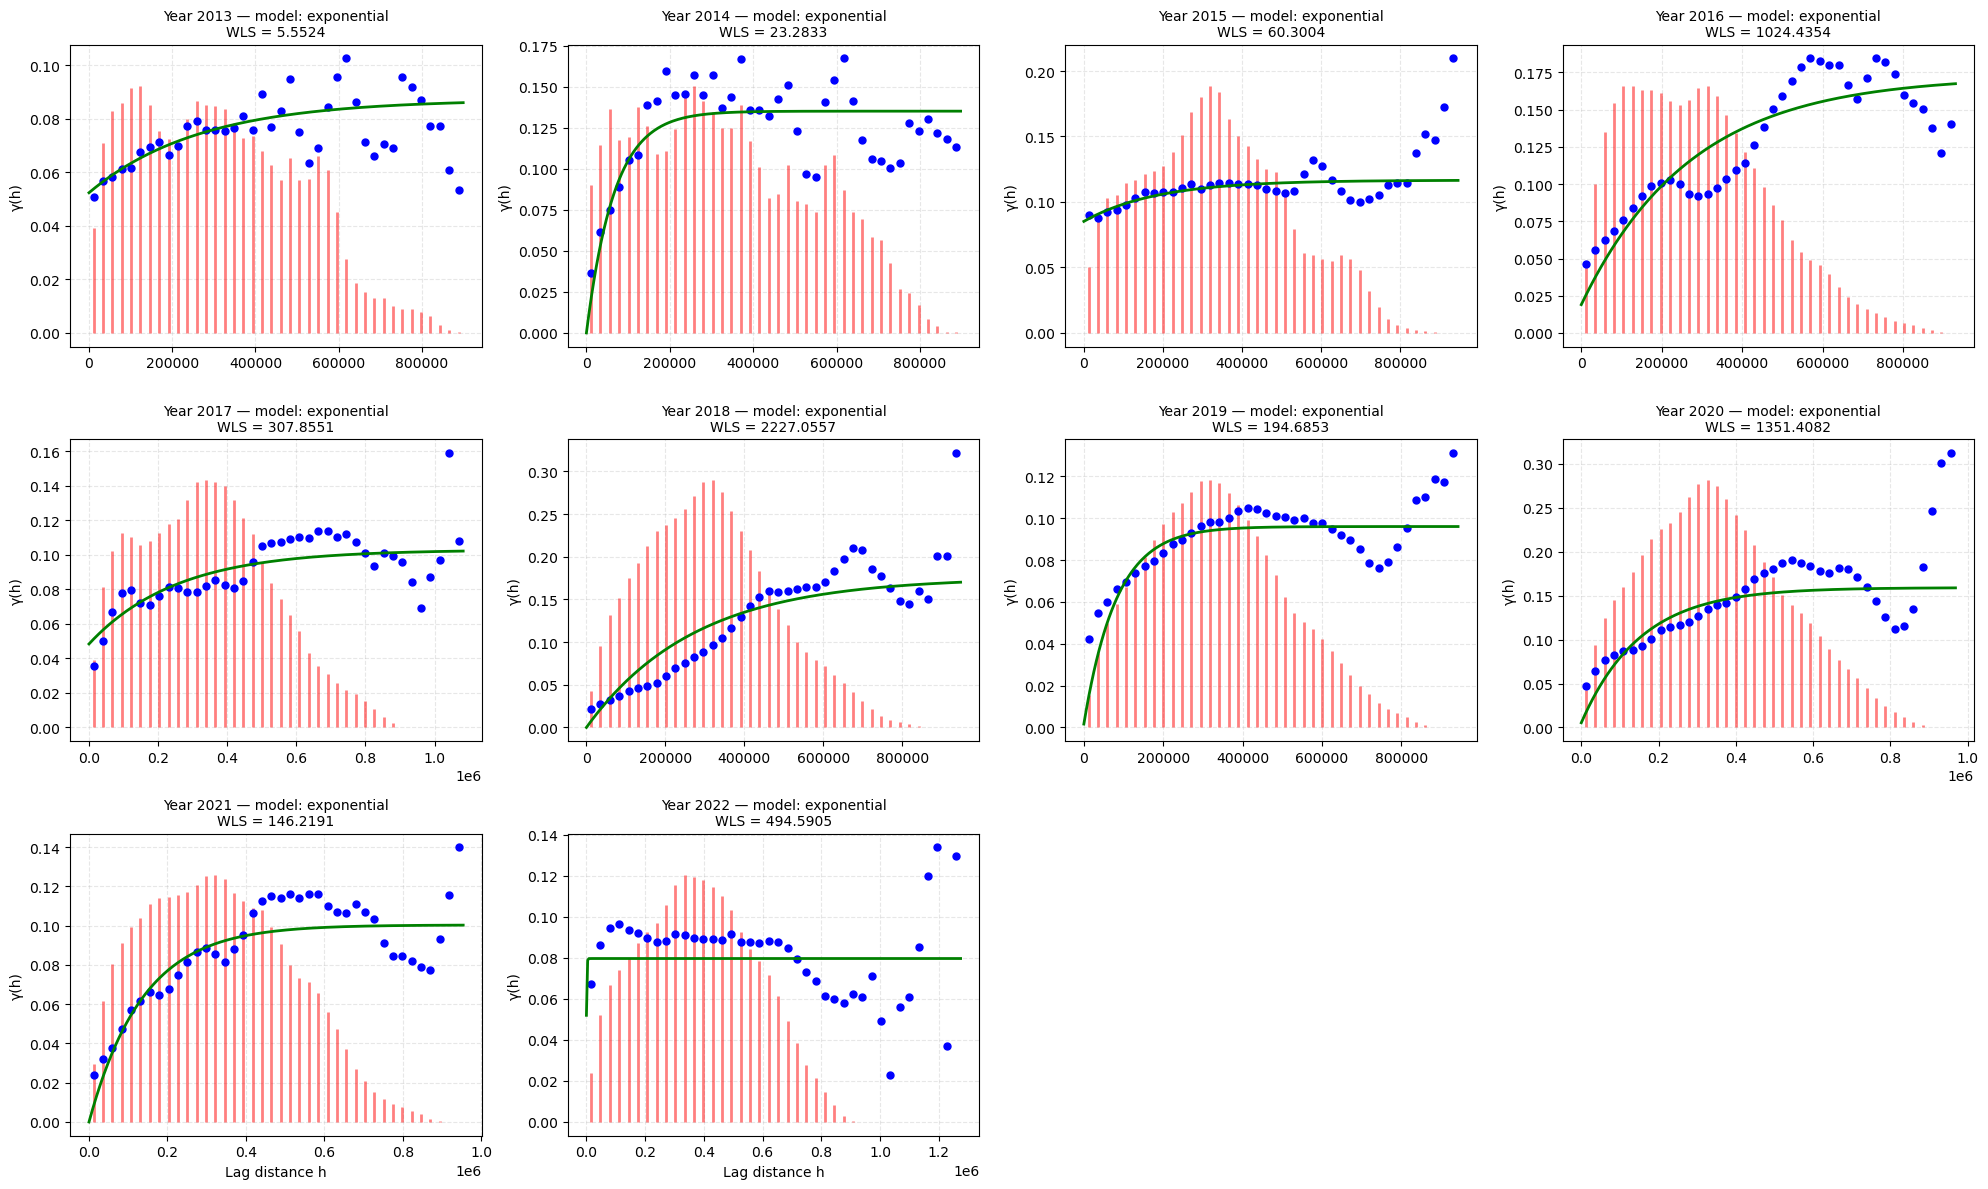


   MODEL: power



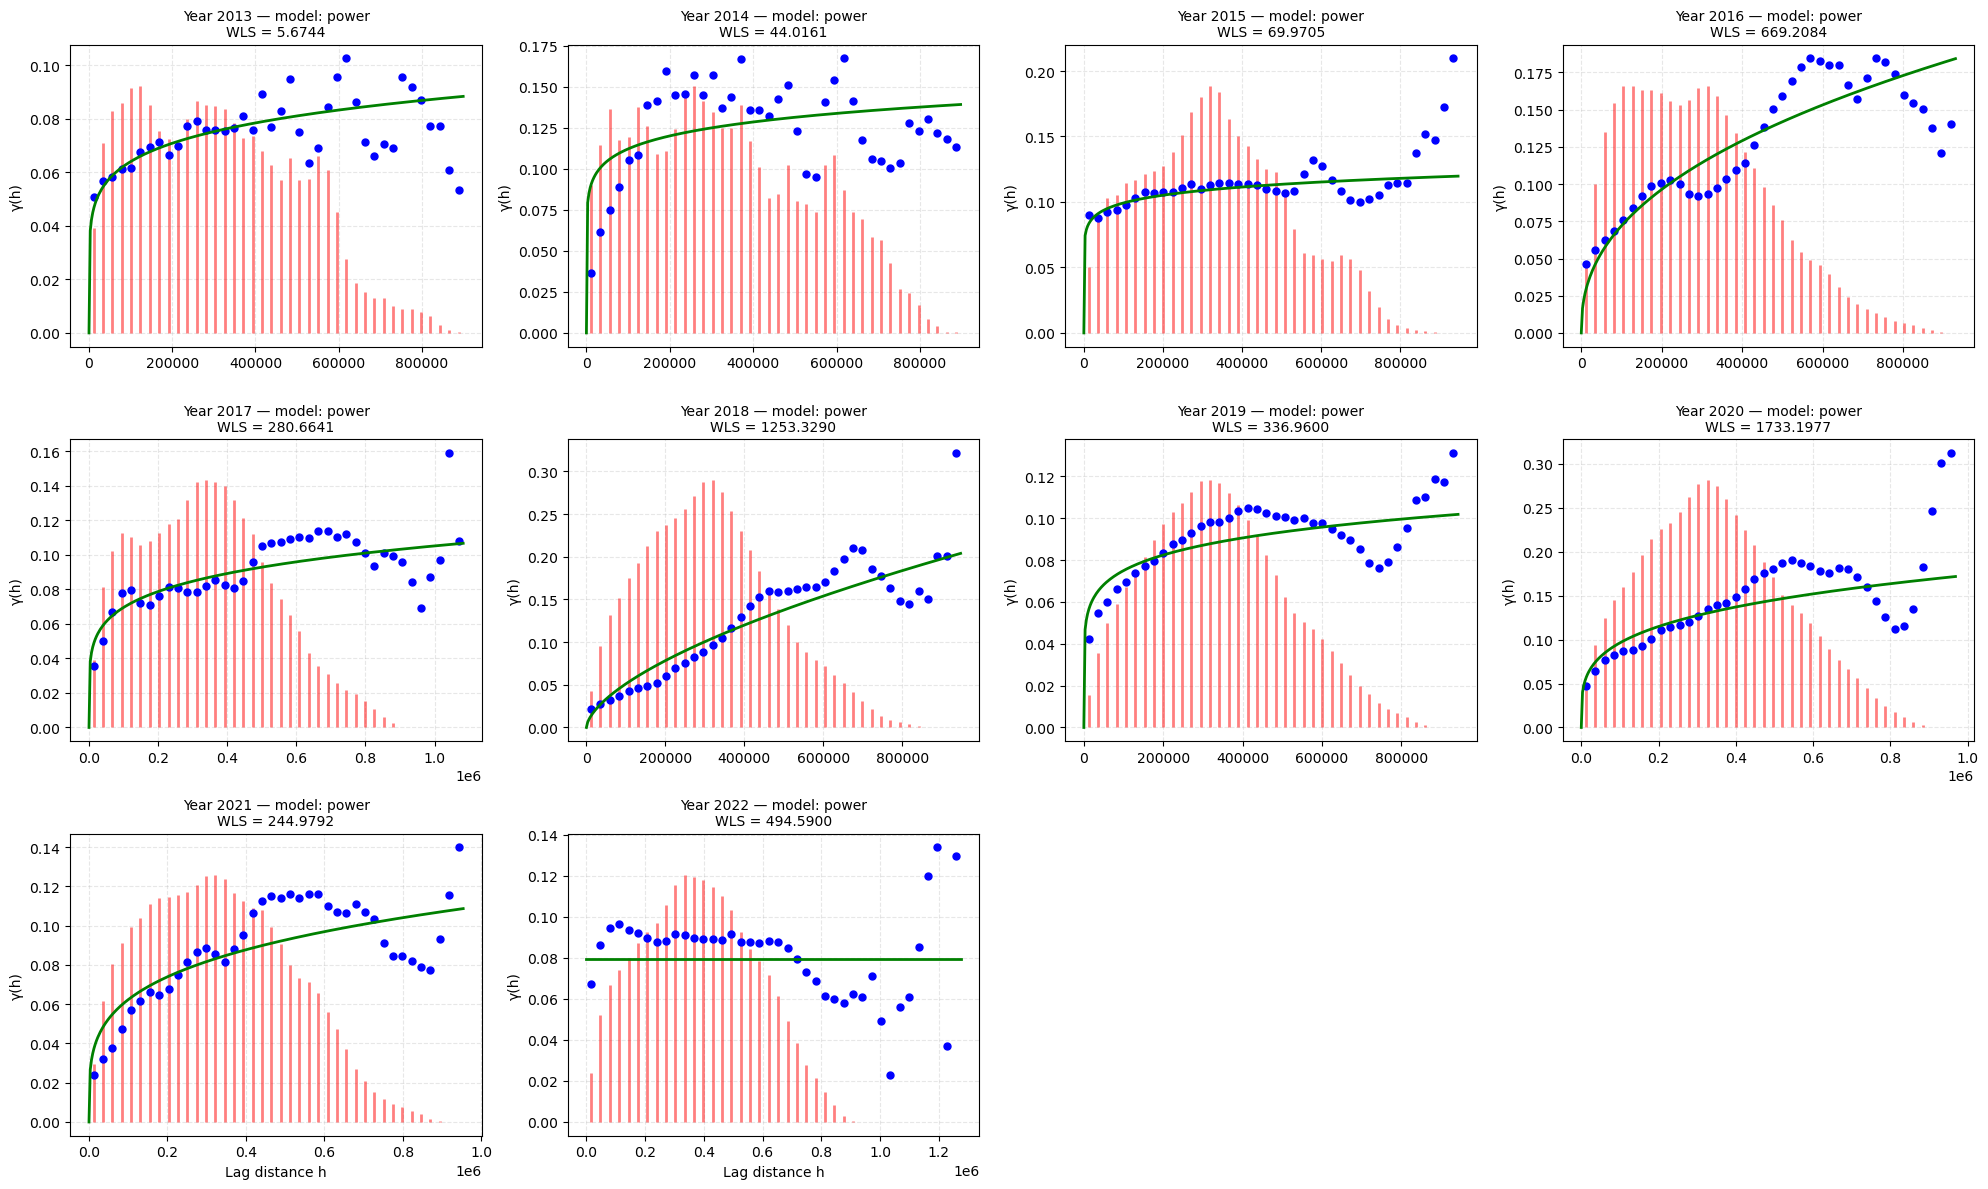


   MODEL: hole-effect



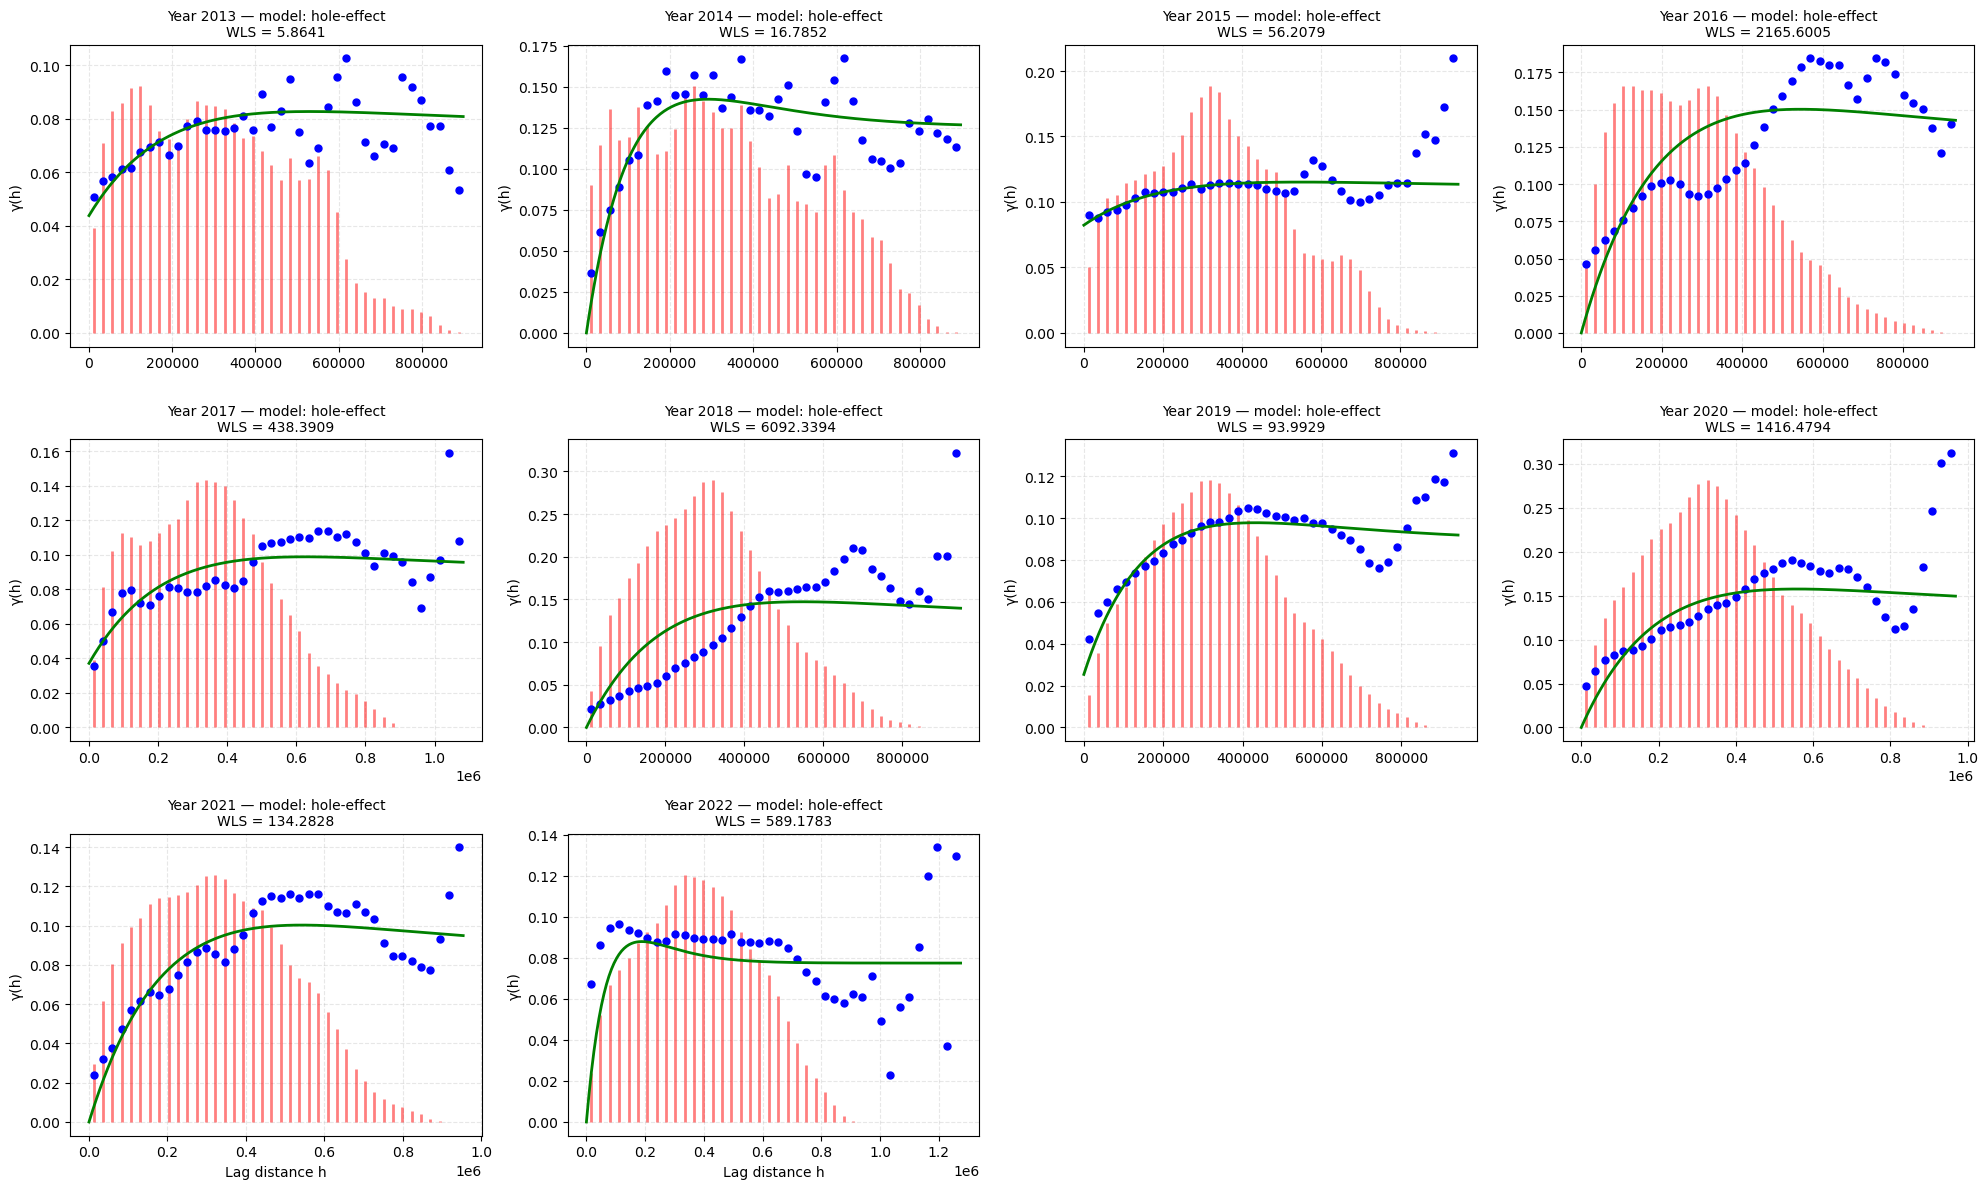


================ WLS METRIC TABLE ================

        gaussian   spherical  exponential        power  hole-effect  \
2013    6.095013    6.319259     5.552375      5.67444     5.864143   
2014   25.866665   20.570148    23.283278    44.016121    16.785213   
2015   60.318369   57.713864    60.300377    69.970513    56.207854   
2016  593.488016  637.723463  1024.435384   669.208384  2165.600547   
2017   308.59998  271.801049   307.855085   280.664051   438.390889   
2018  377.927519  560.912493  2227.055672  1253.329042  6092.339448   
2019  112.834427   99.533094   194.685273   336.959976    93.992868   
2020  891.993974  781.408424  1351.408218    1733.1977  1416.479446   
2021  124.042917   107.15593   146.219139    244.97924   134.282763   
2022  494.590617  500.717227   494.590544   494.590039   589.178295   

       Best Model  
2013  exponential  
2014  hole-effect  
2015  hole-effect  
2016     gaussian  
2017    spherical  
2018     gaussian  
2019  hole-effect  
2020 

In [10]:
_ = compare_variogram_models(df_train, prob_col="p_raw", year_col=year_col,
                             n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect"))


Detected years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

=== STEP 1: Annual variograms ===


=== Mean variogram computed ===


=== STEP 2: Fitting models to mean variogram ===

Model gaussian: params=[6.67330674e-02 2.95988993e+05 5.19042689e-02] → WLS=0.005679
Model spherical: params=[7.82039894e-02 2.95988993e+05 3.89535057e-02] → WLS=0.006523
Model exponential: params=[9.56666378e-02 2.95988993e+05 2.23195568e-02] → WLS=0.006202
Model power: params=[0.00928284 0.15054302 0.04644575] → WLS=0.010815
Model hole-effect: params=[7.07121697e-02 2.95988993e+05 3.67754030e-02] → WLS=0.016426


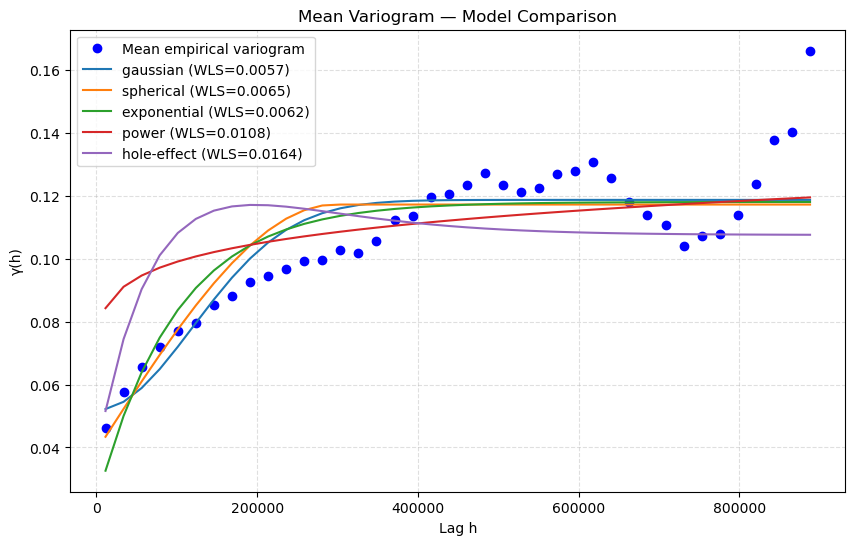


=== FINAL MODEL COMPARISON ===

                  WLS  Rank
gaussian     0.005679   1.0
exponential  0.006202   2.0
spherical    0.006523   3.0
power        0.010815   4.0
hole-effect  0.016426   5.0


In [11]:
_,_ = compare_variogram_models_with_mean(df_train, prob_col="p_raw", year_col=year_col,
                              n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect")   )

In [12]:

# 4. Mean variogram (sur TRAIN)
print("\n--- COMPUTING MEAN VARIOGRAM ---")
mean_params = compute_mean_variogram(df_train, "p_raw", year_col)



--- COMPUTING MEAN VARIOGRAM ---
[Variogram] Fitting variogram for year 2013...
[Variogram] Fitting variogram for year 2014...
[Variogram] Fitting variogram for year 2015...
[Variogram] Fitting variogram for year 2016...
[Variogram] Fitting variogram for year 2017...
[Variogram] Fitting variogram for year 2018...
[Variogram] Fitting variogram for year 2019...
[Variogram] Fitting variogram for year 2020...
[Variogram] Fitting variogram for year 2021...
[Variogram] Fitting variogram for year 2022...

=== MEAN VARIOGRAM PARAMETERS ===
Mean range  = 423964.0889
Mean sill   = 0.0694
Mean nugget = 0.0536



--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---
[Kriging] Fitting Kriging for year 2013 with mean variogram.
[Kriging] Fitting Kriging for year 2014 with mean variogram.
[Kriging] Fitting Kriging for year 2015 with mean variogram.
[Kriging] Fitting Kriging for year 2016 with mean variogram.
[Kriging] Fitting Kriging for year 2017 with mean variogram.
[Kriging] Fitting Kriging for year 2018 with mean variogram.
[Kriging] Fitting Kriging for year 2019 with mean variogram.
[Kriging] Fitting Kriging for year 2020 with mean variogram.
[Kriging] Fitting Kriging for year 2021 with mean variogram.
[Kriging] Fitting Kriging for year 2022 with mean variogram.

--- APPLYING SPATIAL CORRECTION (TEST) ---

--- CORRECTED PROBABILITY METRICS (TEST) ---

---------------- Metrics ----------------
AUC : 0.8405741823231015

Confusion Matrix:
[[3148 1567]
 [ 171 1012]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.67      0.78      

<Figure size 600x500 with 0 Axes>

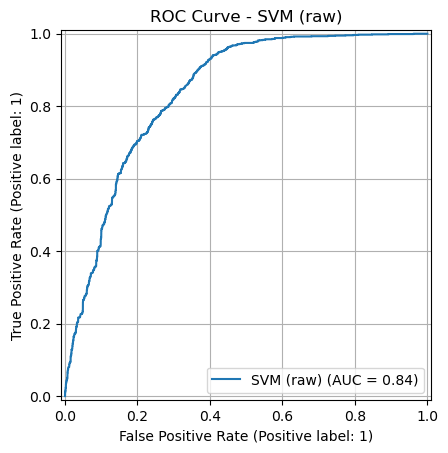

In [13]:

# 5. Kriging par année avec variogramme moyen (sur TRAIN)
print("\n--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---")
kriging_models = fit_kriging_with_mean_variogram(
    df_train, "p_raw", mean_params, year_col
)
# 6. Application de la correction spatiale sur le TEST
print("\n--- APPLYING SPATIAL CORRECTION (TEST) ---")
df_test_corr = apply_kriging_by_year(
    df_test, "p_raw", kriging_models, year_col
)
print("\n--- CORRECTED PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test_corr["p_corr"])
plot_roc_curve(df_test[target], df_test_corr["p_corr"], model_name_2 + " (raw)")


### ***XGBOOST***

In [14]:
model_name_3= "XGBoost"
X_model = get_model(model_name_3)
print(f"\n======== SELECTED MODEL: {model_name_3} ========")


======== SELECTED MODEL: XGBoost ========


In [15]:
# 2. Train ML
print("\n--- TRAINING MODEL ---")
X_model.fit(df_train[features], df_train[target])


--- TRAINING MODEL ---


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'



--- RAW PROBABILITY METRICS (TEST) ---

---------------- Metrics ----------------
AUC : 0.7992401187196848

Confusion Matrix:
[[3343 1372]
 [ 311  872]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      4715
           1       0.39      0.74      0.51      1183

    accuracy                           0.71      5898
   macro avg       0.65      0.72      0.65      5898
weighted avg       0.81      0.71      0.74      5898



<Figure size 600x500 with 0 Axes>

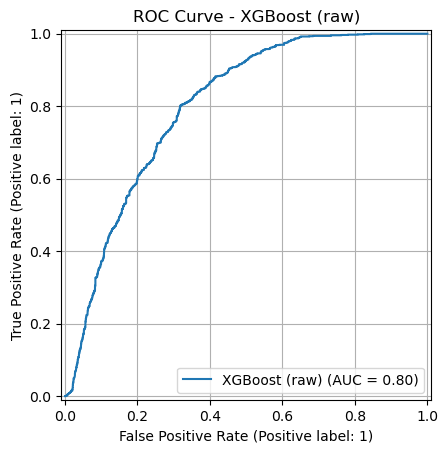

In [16]:
# 3. Predict raw probabilities
df_train["p_raw"] = X_model.predict_proba(df_train[features])[:, 1]
df_test["p_raw"] = X_model.predict_proba(df_test[features])[:, 1]
print("\n--- RAW PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test["p_raw"])
plot_roc_curve(df_test[target], df_test["p_raw"], model_name_3 + " (raw)")


   MODEL: gaussian



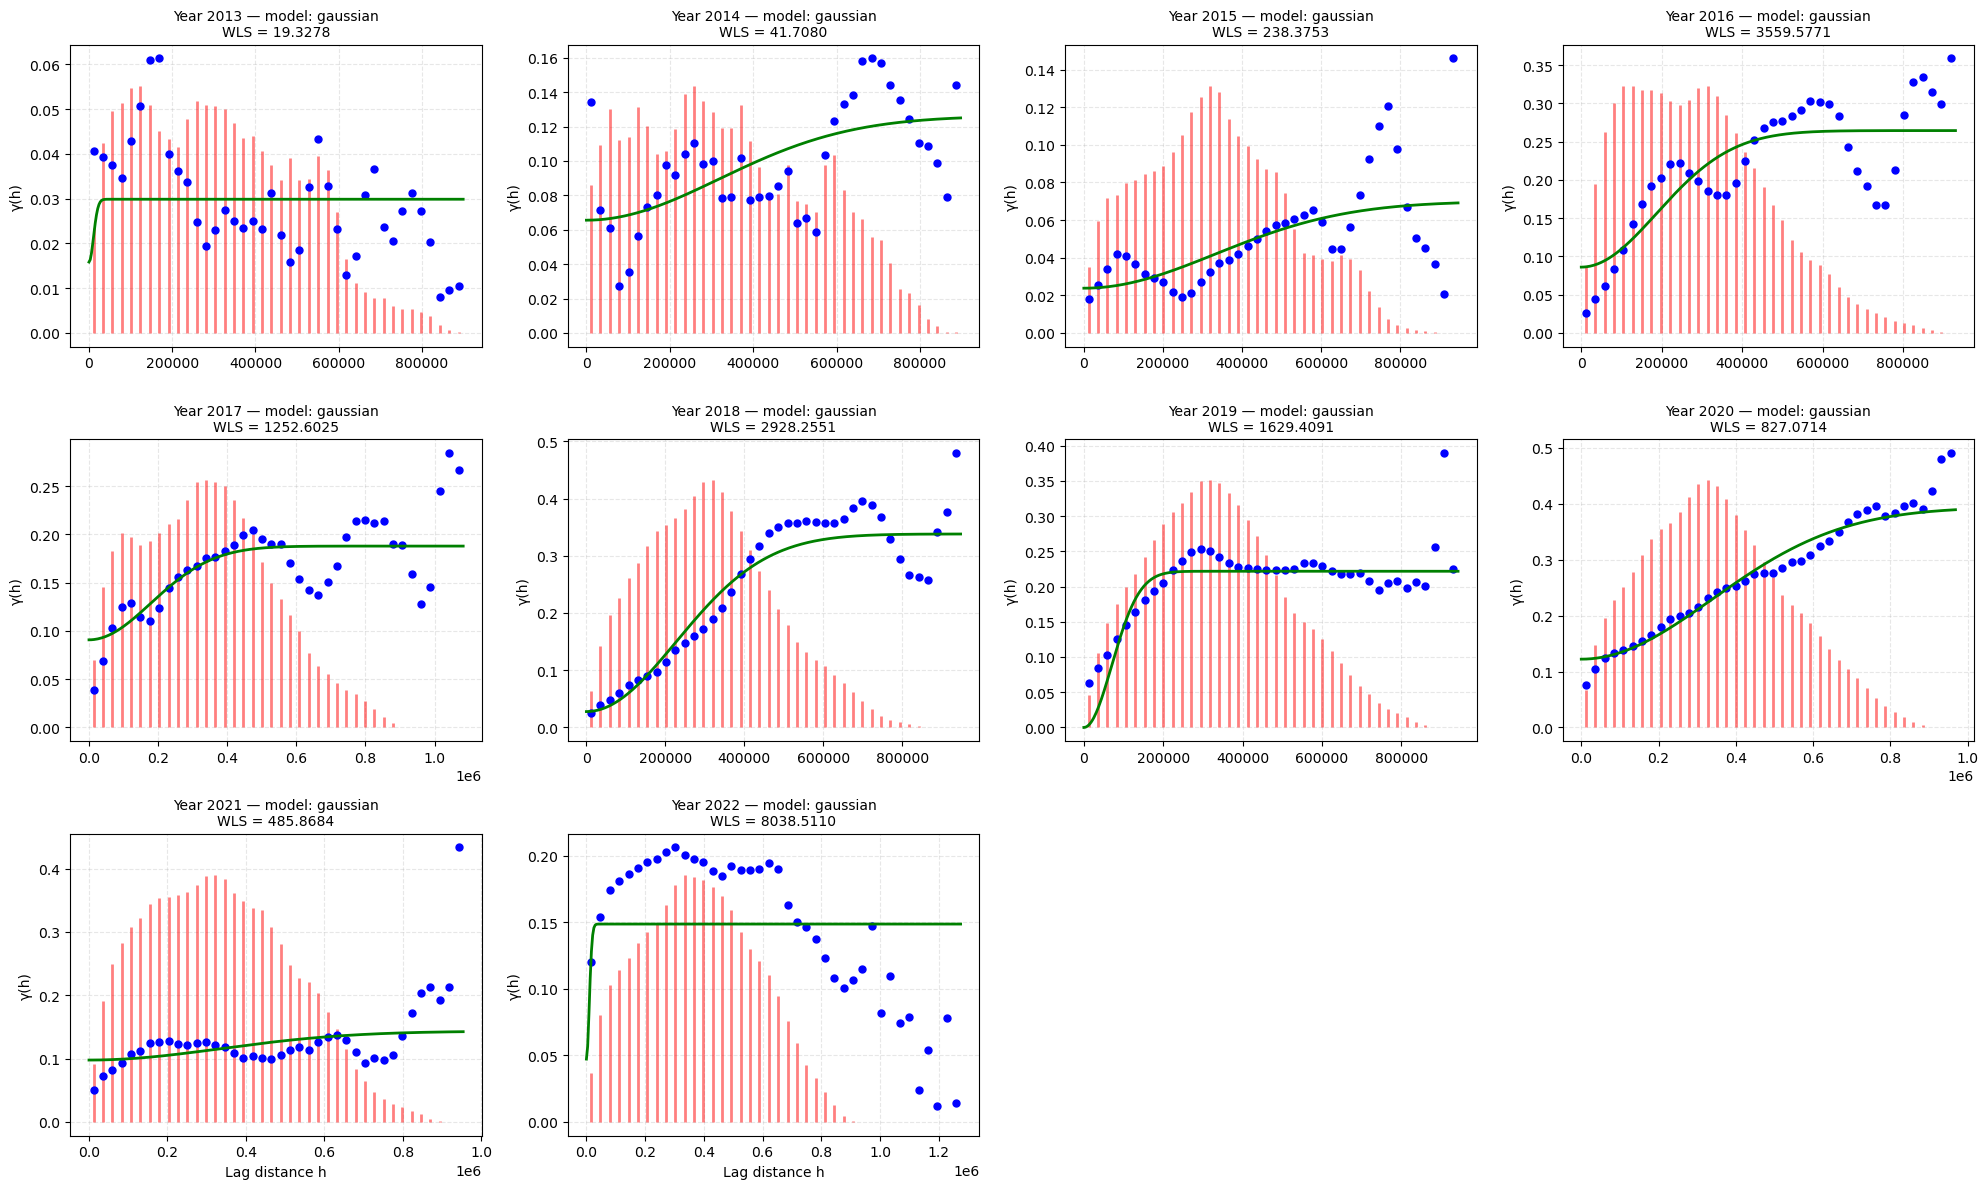


   MODEL: spherical



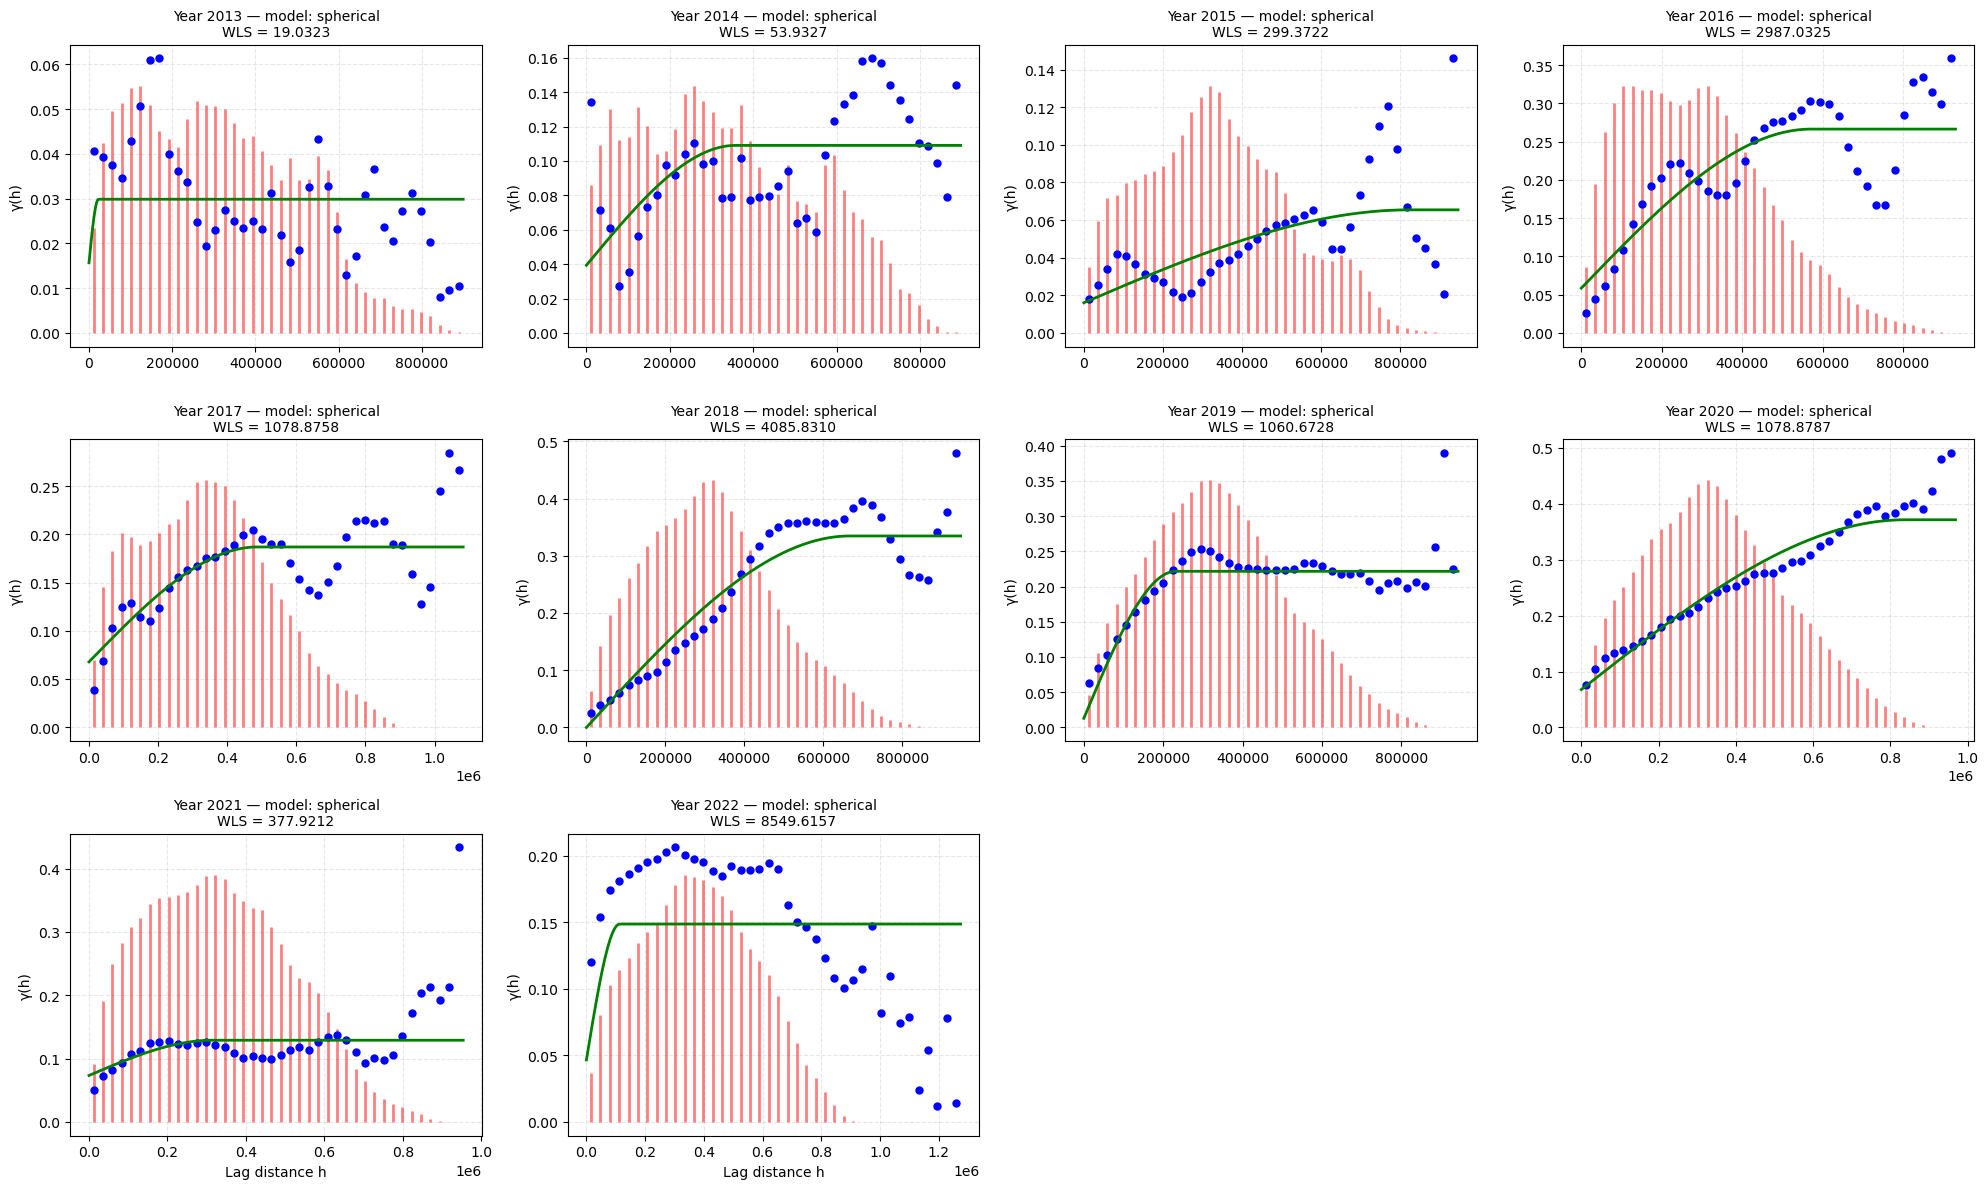


   MODEL: exponential



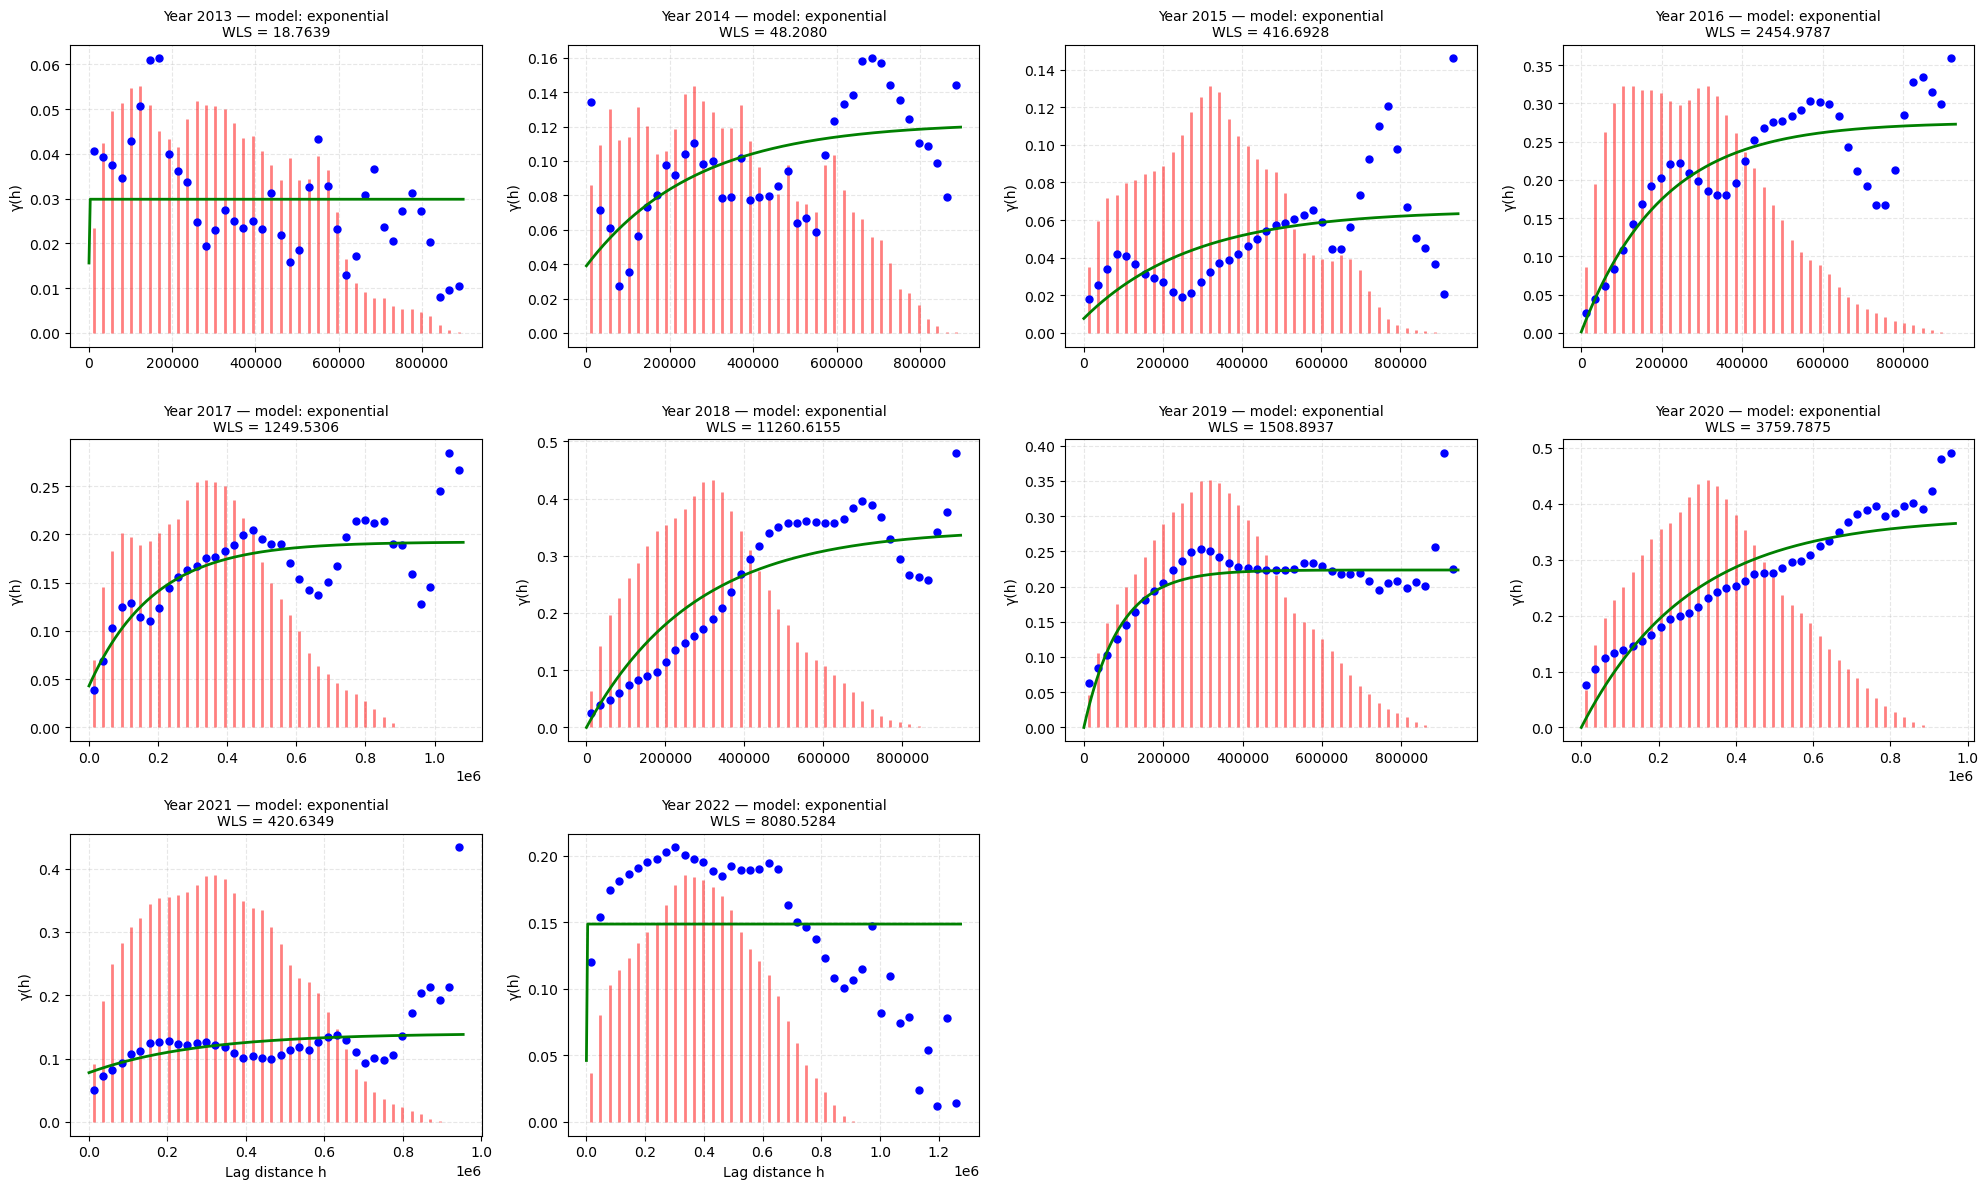


   MODEL: power



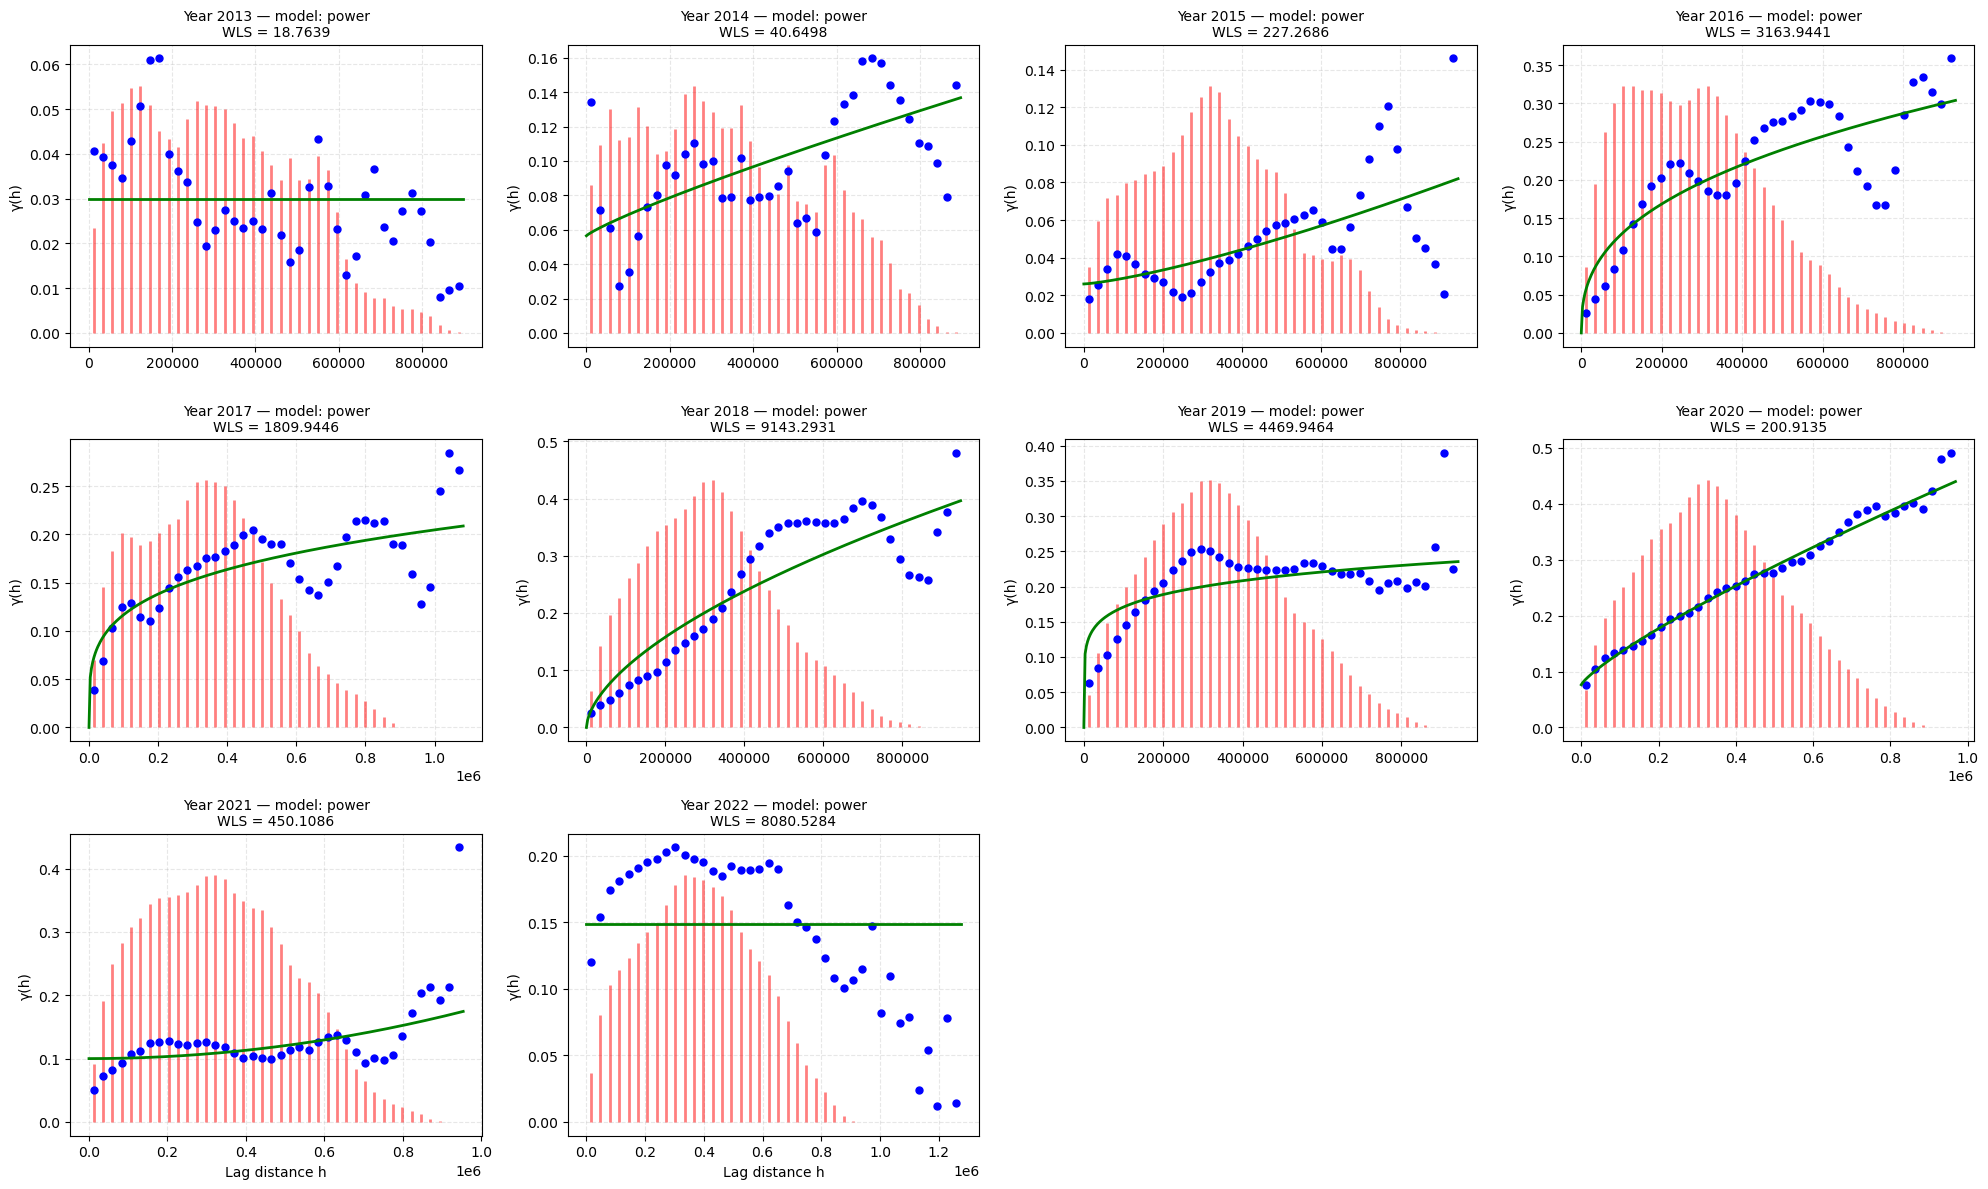


   MODEL: hole-effect



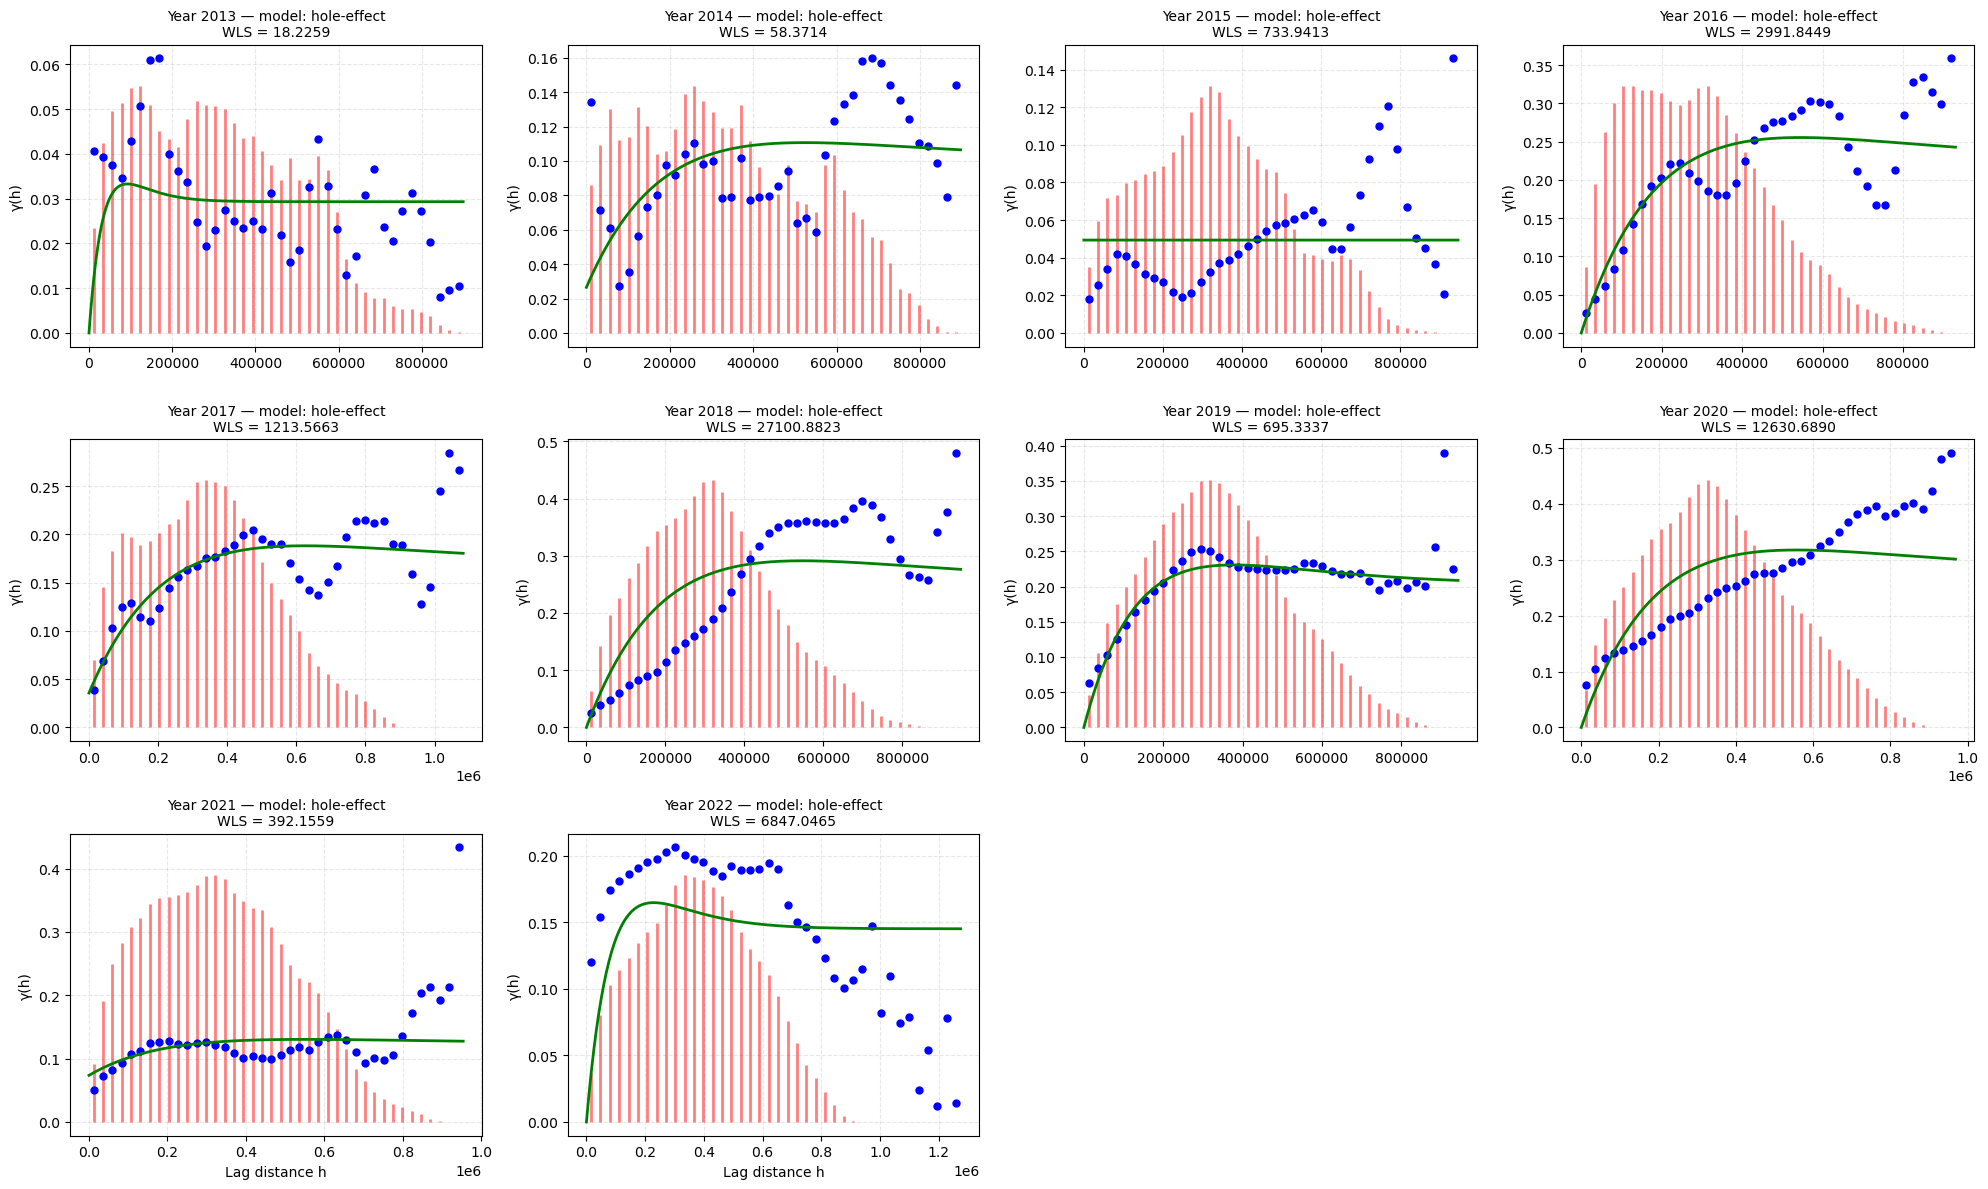


================ WLS METRIC TABLE ================

         gaussian    spherical   exponential        power   hole-effect  \
2013    19.327793    19.032275     18.763915    18.763908     18.225904   
2014    41.707955    53.932723     48.207979    40.649811     58.371432   
2015   238.375294   299.372215    416.692776   227.268585    733.941335   
2016  3559.577146  2987.032475   2454.978711  3163.944129   2991.844941   
2017   1252.60252  1078.875817   1249.530645  1809.944551   1213.566332   
2018  2928.255061  4085.831032  11260.615471  9143.293073  27100.882268   
2019   1629.40909  1060.672809   1508.893742  4469.946413    695.333745   
2020   827.071379   1078.87871   3759.787488    200.91349  12630.689009   
2021   485.868425   377.921226     420.63494   450.108623    392.155938   
2022  8038.511043  8549.615726   8080.528437  8080.528432   6847.046469   

       Best Model  
2013  hole-effect  
2014        power  
2015        power  
2016  exponential  
2017    spherical  
2

In [17]:
_ = compare_variogram_models(df_train, prob_col="p_raw", year_col=year_col,
                             n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect"))


Detected years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

=== STEP 1: Annual variograms ===


=== Mean variogram computed ===


=== STEP 2: Fitting models to mean variogram ===

Model gaussian: params=[1.15998120e-01 2.95988993e+05 6.14996391e-02] → WLS=0.012958
Model spherical: params=[1.35780580e-01 2.95988993e+05 3.91255278e-02] → WLS=0.015616
Model exponential: params=[1.65205562e-01 2.95988993e+05 1.10414617e-02] → WLS=0.015150
Model power: params=[0.01004622 0.21623004 0.        ] → WLS=0.009231
Model hole-effect: params=[1.18869377e-01 2.95988993e+05 3.92488812e-02] → WLS=0.046468


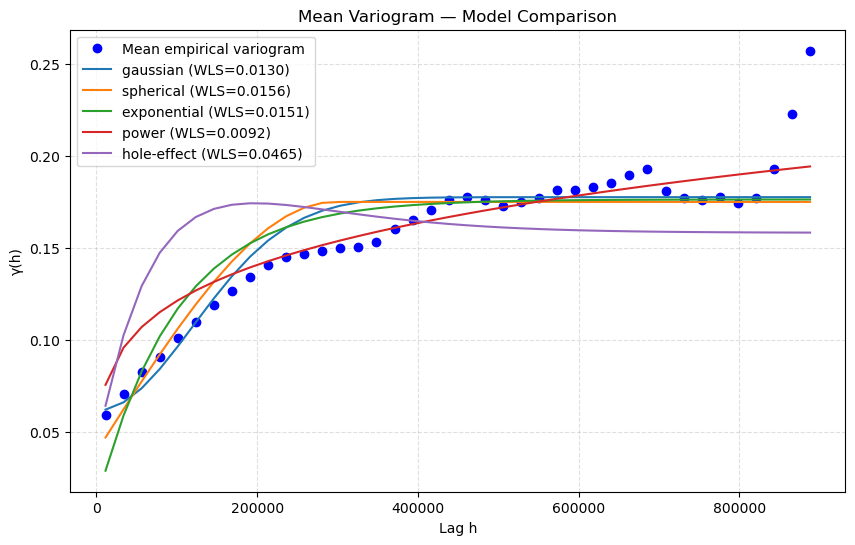


=== FINAL MODEL COMPARISON ===

                  WLS  Rank
power        0.009231   1.0
gaussian     0.012958   2.0
exponential  0.015150   3.0
spherical    0.015616   4.0
hole-effect  0.046468   5.0


In [18]:
_,_ = compare_variogram_models_with_mean(df_train, prob_col="p_raw", year_col=year_col,
                              n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect")   )

In [19]:

# 4. Mean variogram (sur TRAIN)
print("\n--- COMPUTING MEAN VARIOGRAM ---")
mean_params = compute_mean_variogram(df_train, "p_raw", year_col)



--- COMPUTING MEAN VARIOGRAM ---
[Variogram] Fitting variogram for year 2013...
[Variogram] Fitting variogram for year 2014...
[Variogram] Fitting variogram for year 2015...
[Variogram] Fitting variogram for year 2016...
[Variogram] Fitting variogram for year 2017...
[Variogram] Fitting variogram for year 2018...
[Variogram] Fitting variogram for year 2019...
[Variogram] Fitting variogram for year 2020...
[Variogram] Fitting variogram for year 2021...
[Variogram] Fitting variogram for year 2022...

=== MEAN VARIOGRAM PARAMETERS ===
Mean range  = 496364.9806
Mean sill   = 0.1329
Mean nugget = 0.0579



--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---
[Kriging] Fitting Kriging for year 2013 with mean variogram.
[Kriging] Fitting Kriging for year 2014 with mean variogram.
[Kriging] Fitting Kriging for year 2015 with mean variogram.
[Kriging] Fitting Kriging for year 2016 with mean variogram.
[Kriging] Fitting Kriging for year 2017 with mean variogram.
[Kriging] Fitting Kriging for year 2018 with mean variogram.
[Kriging] Fitting Kriging for year 2019 with mean variogram.
[Kriging] Fitting Kriging for year 2020 with mean variogram.
[Kriging] Fitting Kriging for year 2021 with mean variogram.
[Kriging] Fitting Kriging for year 2022 with mean variogram.

--- APPLYING SPATIAL CORRECTION (TEST) ---

--- CORRECTED PROBABILITY METRICS (TEST) ---

---------------- Metrics ----------------
AUC : 0.7992401187196848

Confusion Matrix:
[[3343 1372]
 [ 311  872]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      

<Figure size 600x500 with 0 Axes>

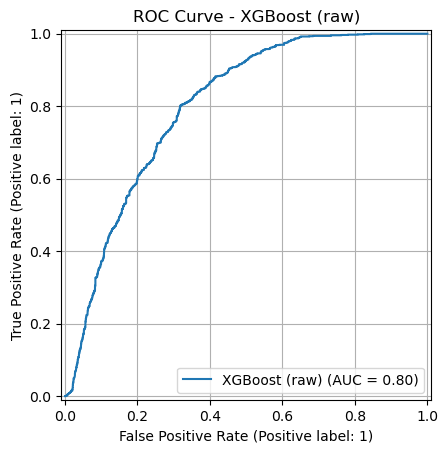

In [ ]:

# 5. Kriging par année avec variogramme moyen (sur TRAIN)
print("\n--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---")
kriging_models = fit_kriging_with_mean_variogram(
    df_train, "p_raw", mean_params, year_col
)
# 6. Application de la correction spatiale sur le TEST
print("\n--- APPLYING SPATIAL CORRECTION (TEST) ---")
df_test_corr = apply_kriging_by_year(
    df_test, "p_raw", kriging_models, year_col
)
print("\n--- CORRECTED PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test_corr["p_corr"])
plot_roc_curve(df_test[target], df_test_corr["p_corr"], model_name_3 + " (raw)")

### Choix du modèle

Voici les modèles que j'ai testés : RandomForest, Logistic, SVM, XGBoost. Après avoir examiné les performances de chaque modèle en termes de métriques telles que l'AUC-ROC et la précision, j'ai constaté que le modèle XGBoost offrait les meilleurs résultats globaux pour notre tâche de classification. Par conséquent, nous choisissons d'utiliser ***Logistic***  comme modèle principal pour notre analyse.
Pour la suite nous tenterons d'améliorer les performances de ce modèle en explorant des techniques avancées telles que l'optimisation des hyperparamètres et l'ingénierie des caractéristiques.

## Optimisation du modèle final

In [ ]:
Best_Model = LogisticRegression(max_iter=5000, solver="lbfgs")
print("\n--- TRAINING MODEL ---")
Best_Model.fit(df_train[features], df_train[target])


# 3. Predict raw probabilities
df_train["p_raw"] = Best_Model.predict_proba(df_train[features])[:, 1]
df_test["p_raw"] = Best_Model.predict_proba(df_test[features])[:, 1]
print("\n--- RAW PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test["p_raw"])
plot_roc_curve(df_test[target], df_test["p_raw"], model_name_3 + " (raw)")

In [9]:
param_grid = [
    # L2 – lbfgs
    {
        "solver": ["lbfgs", "newton-cg"],
        "penalty": ["l2"],
        "C": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100],
        "class_weight": [None, "balanced"],
        "tol": [1e-5, 1e-4, 1e-3],
        "fit_intercept": [True, False]
    },

    # L1 – liblinear
    {
        "solver": ["liblinear"],
        "penalty": ["l1"],
        "C": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
        "class_weight": [None, "balanced"],
        "tol": [1e-5, 1e-4],
        "fit_intercept": [True, False]
    },

    # ElasticNet – saga
    {
        "solver": ["saga"],
        "penalty": ["elasticnet"],
        "C": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        "class_weight": [None, "balanced"],
        "tol": [1e-5, 1e-4],
        "fit_intercept": [True, False]
    }
]


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

base_model = LogisticRegression(
    max_iter=5000,
    multi_class="auto"
)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="neg_log_loss",   # PROBABILITÉS
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(df_train[features], df_train[target])

Best_Model = grid.best_estimator_

print("BEST PARAMS:\n", grid.best_params_)
print("BEST CV LOG-LOSS:", -grid.best_score_)


Fitting 5 folds for each of 456 candidates, totalling 2280 fits
BEST PARAMS:
 {'C': 0.01, 'class_weight': None, 'fit_intercept': False, 'penalty': 'l2', 'solver': 'newton-cg', 'tol': 0.001}
BEST CV LOG-LOSS: 0.5206943584916376



--- TRAINING MODEL ---

--- RAW PROBABILITY METRICS (TEST) ---

---------------- Metrics ----------------
AUC : 0.866047460981795

Confusion Matrix:
[[3629 1086]
 [ 129 1054]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.86      4715
           1       0.49      0.89      0.63      1183

    accuracy                           0.79      5898
   macro avg       0.73      0.83      0.75      5898
weighted avg       0.87      0.79      0.81      5898



<Figure size 600x500 with 0 Axes>

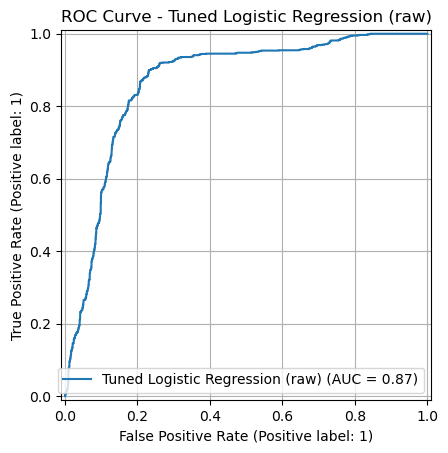

In [12]:
print("\n--- TRAINING MODEL ---")
Best_Model.fit(df_train[features], df_train[target])
model_name= "Tuned Logistic Regression"

# 3. Predict raw probabilities
df_train["p_raw"] = Best_Model.predict_proba(df_train[features])[:, 1]
df_test["p_raw"] = Best_Model.predict_proba(df_test[features])[:, 1]
print("\n--- RAW PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test["p_raw"])
plot_roc_curve(df_test[target], df_test["p_raw"], model_name + " (raw)")


   MODEL: gaussian



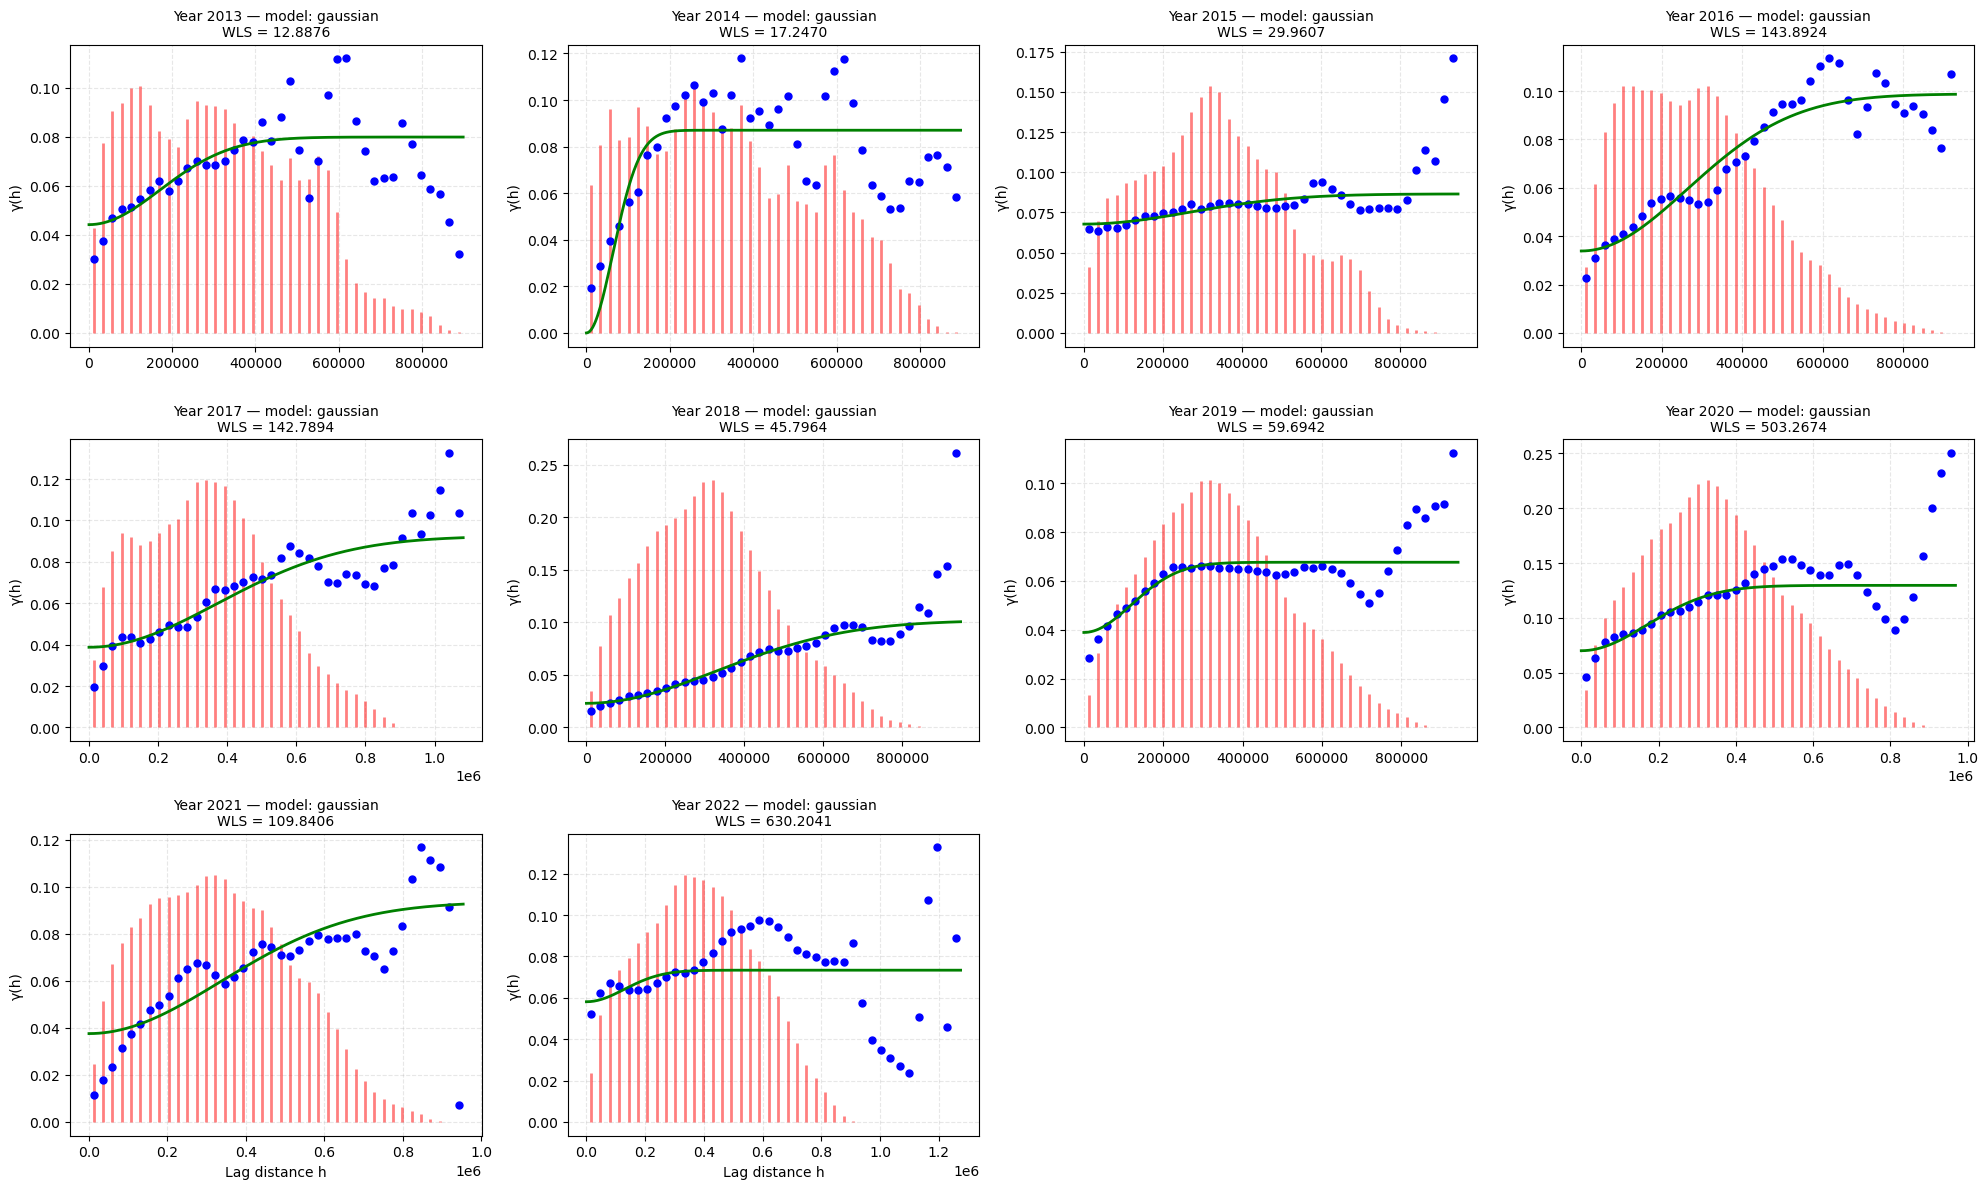


   MODEL: spherical



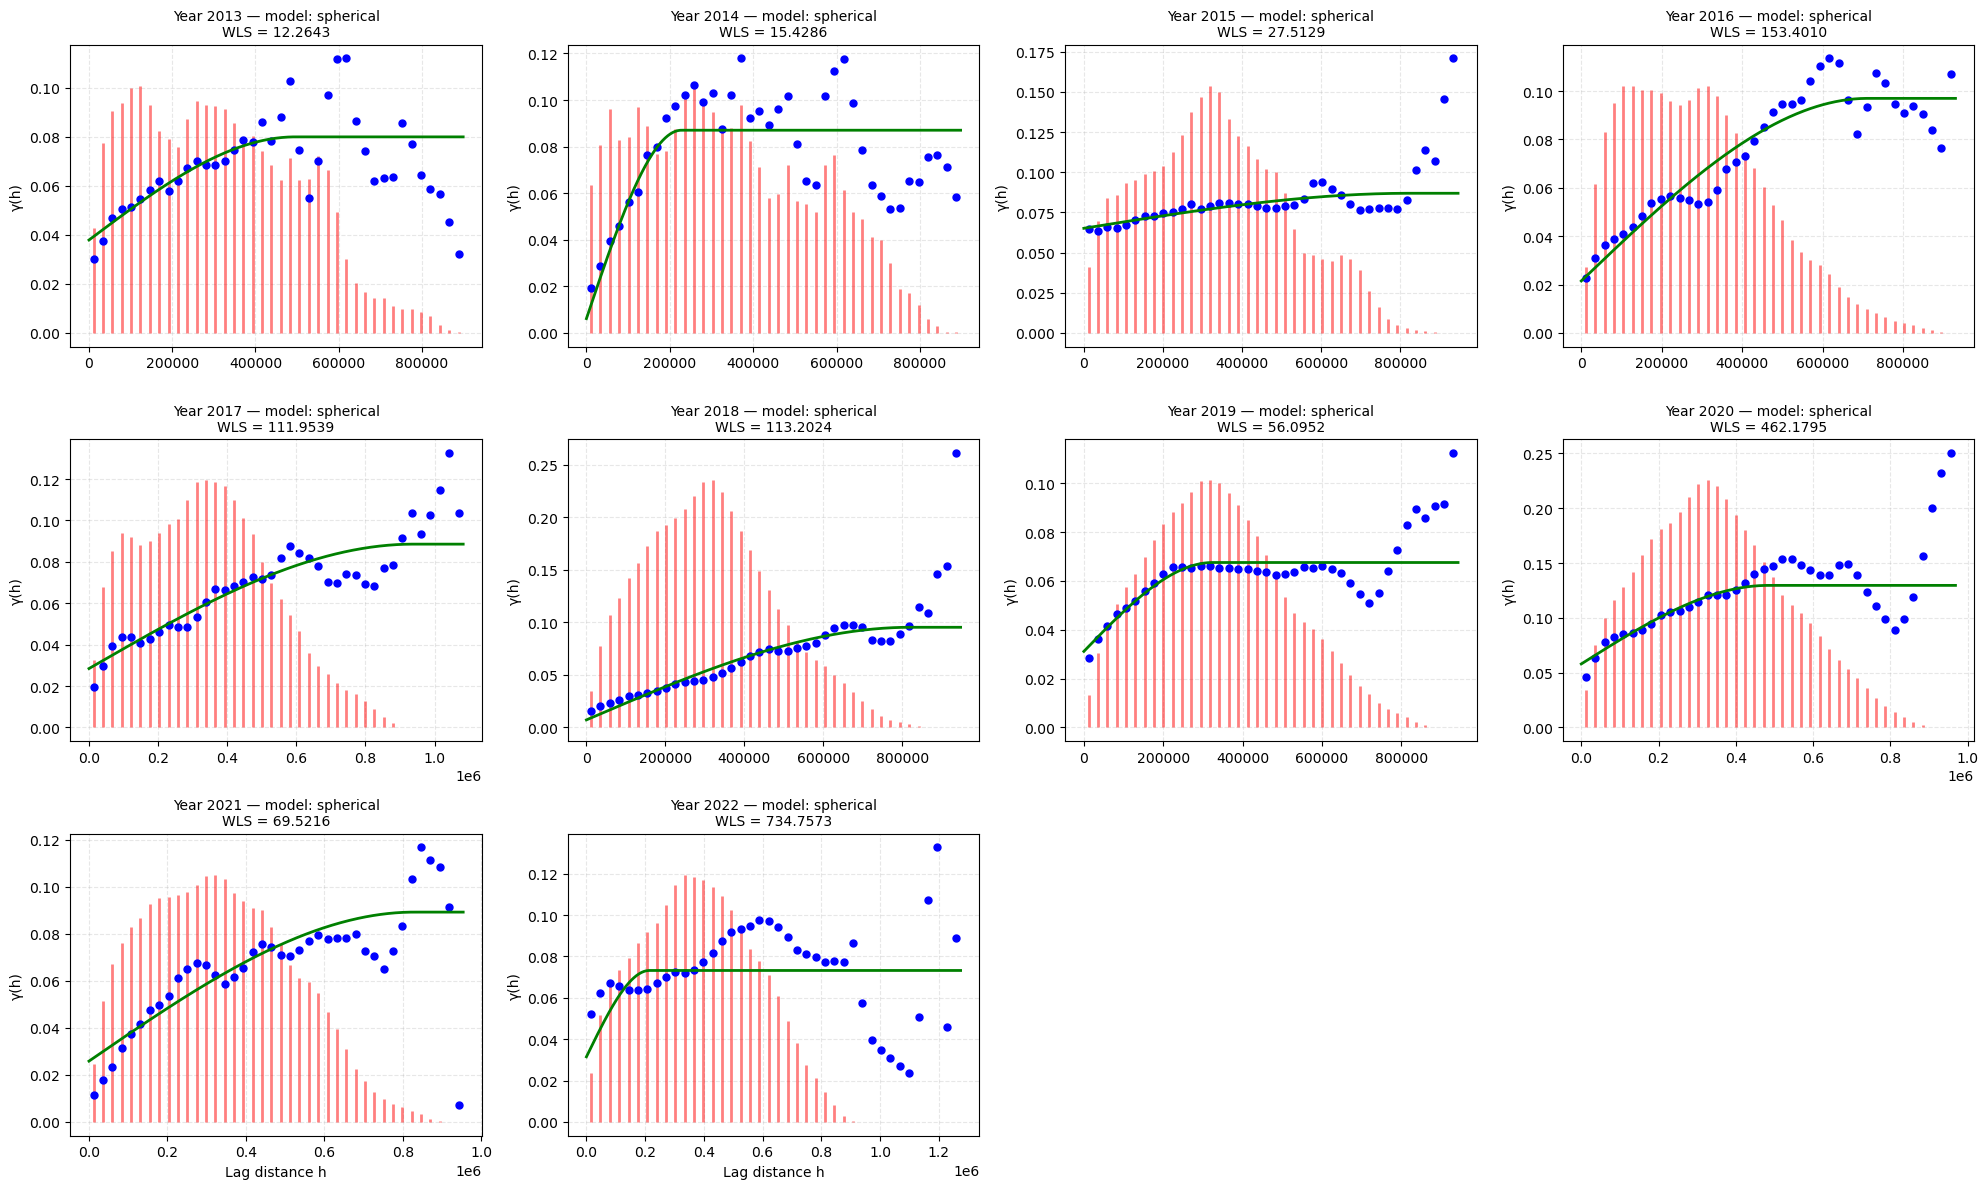


   MODEL: exponential



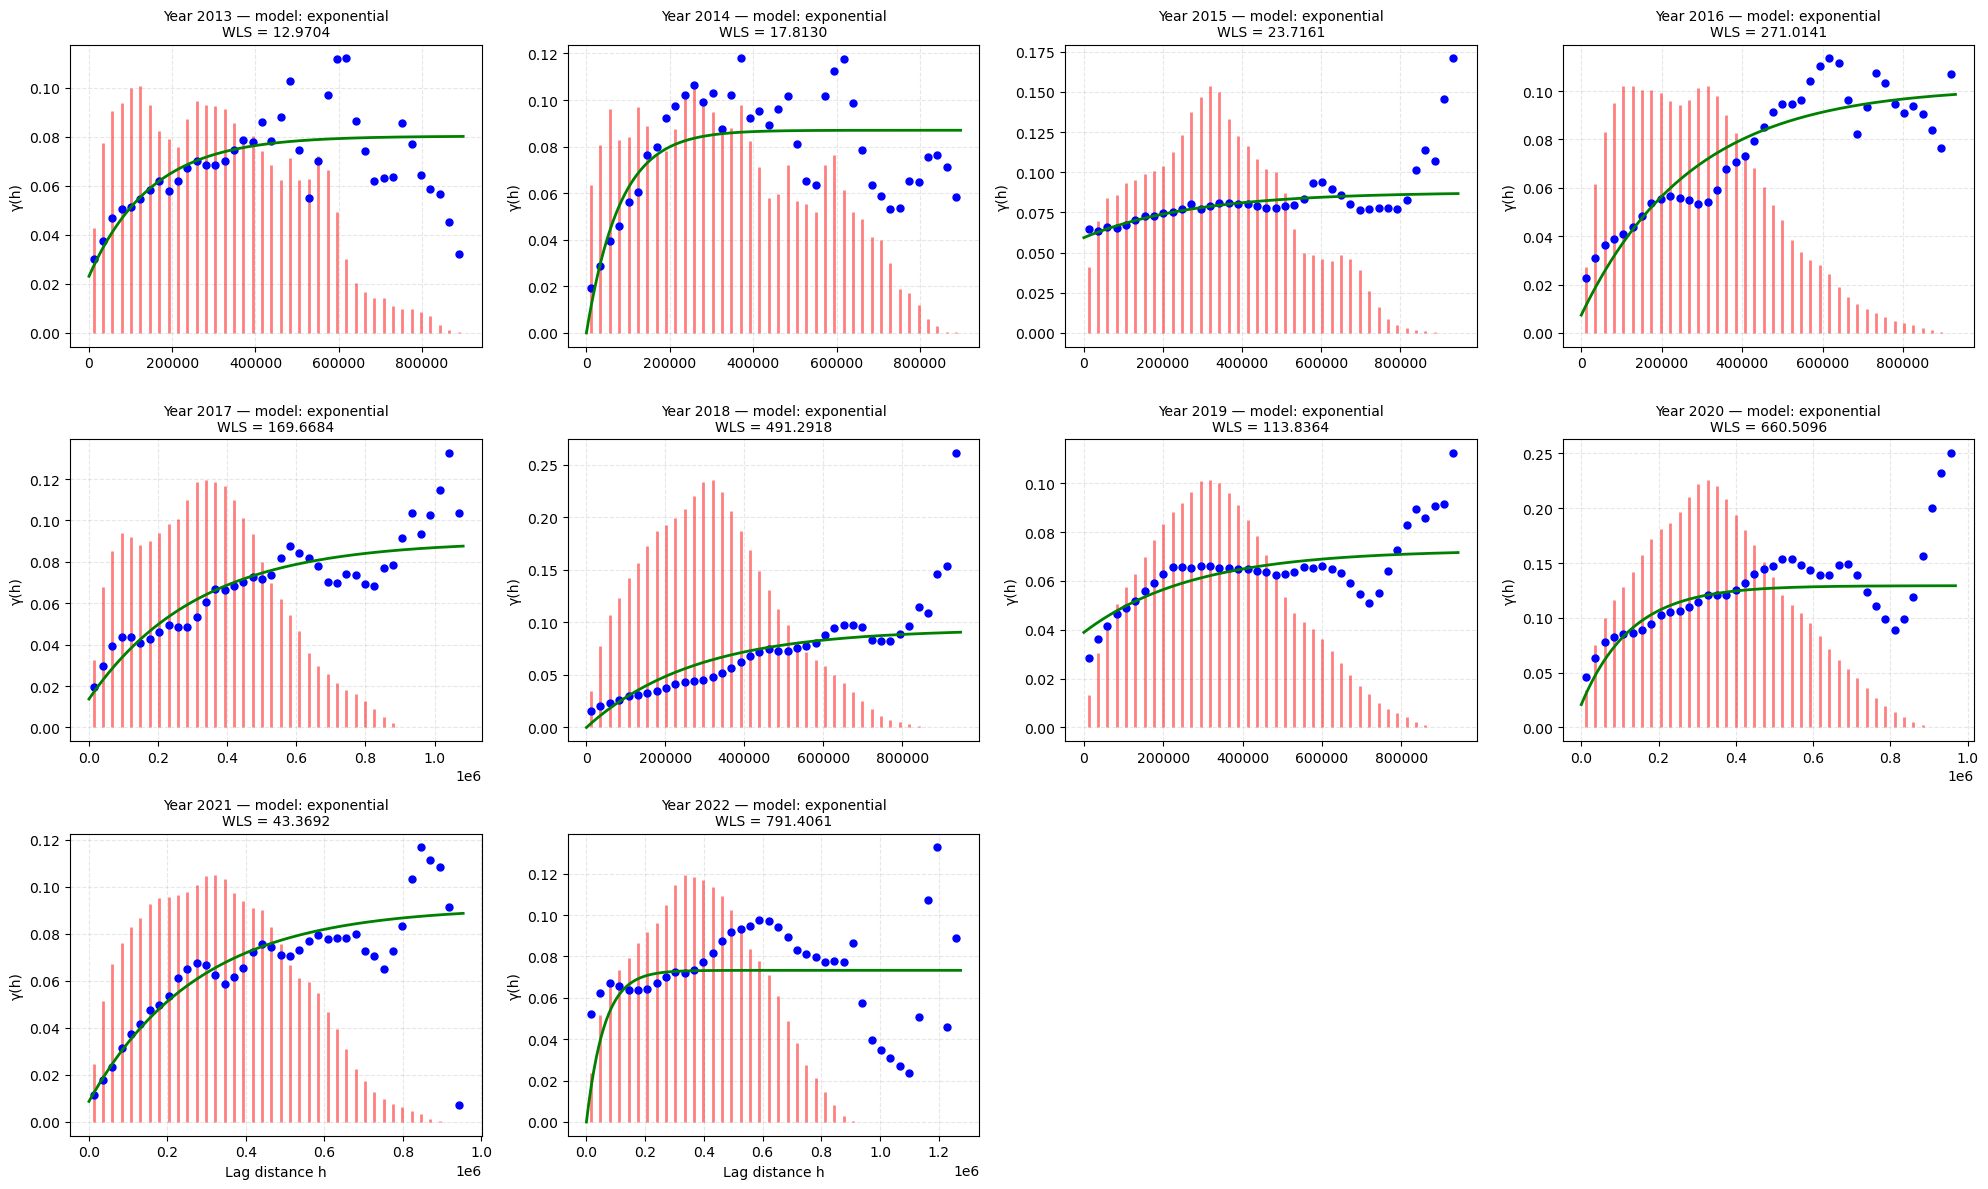


   MODEL: power



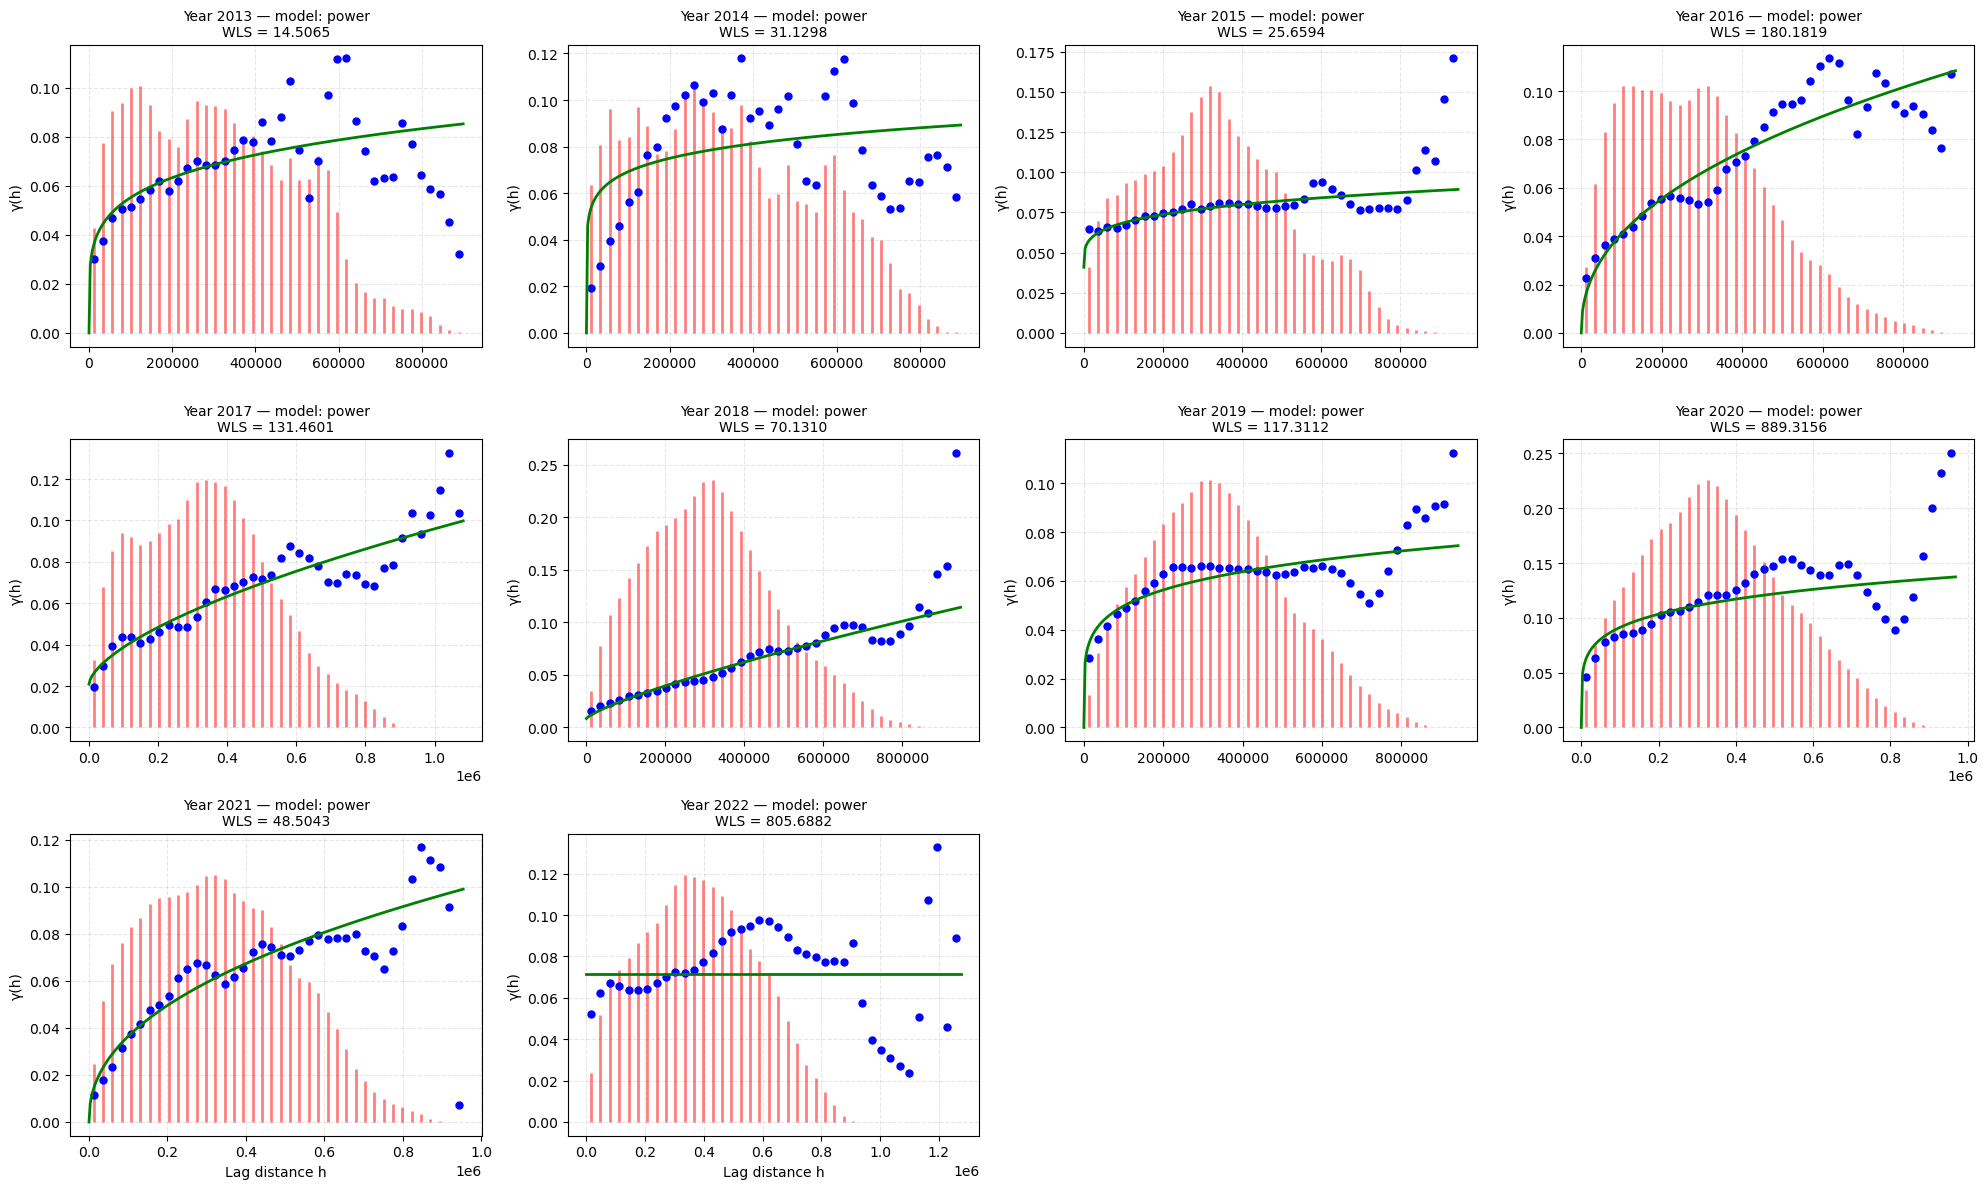


   MODEL: hole-effect



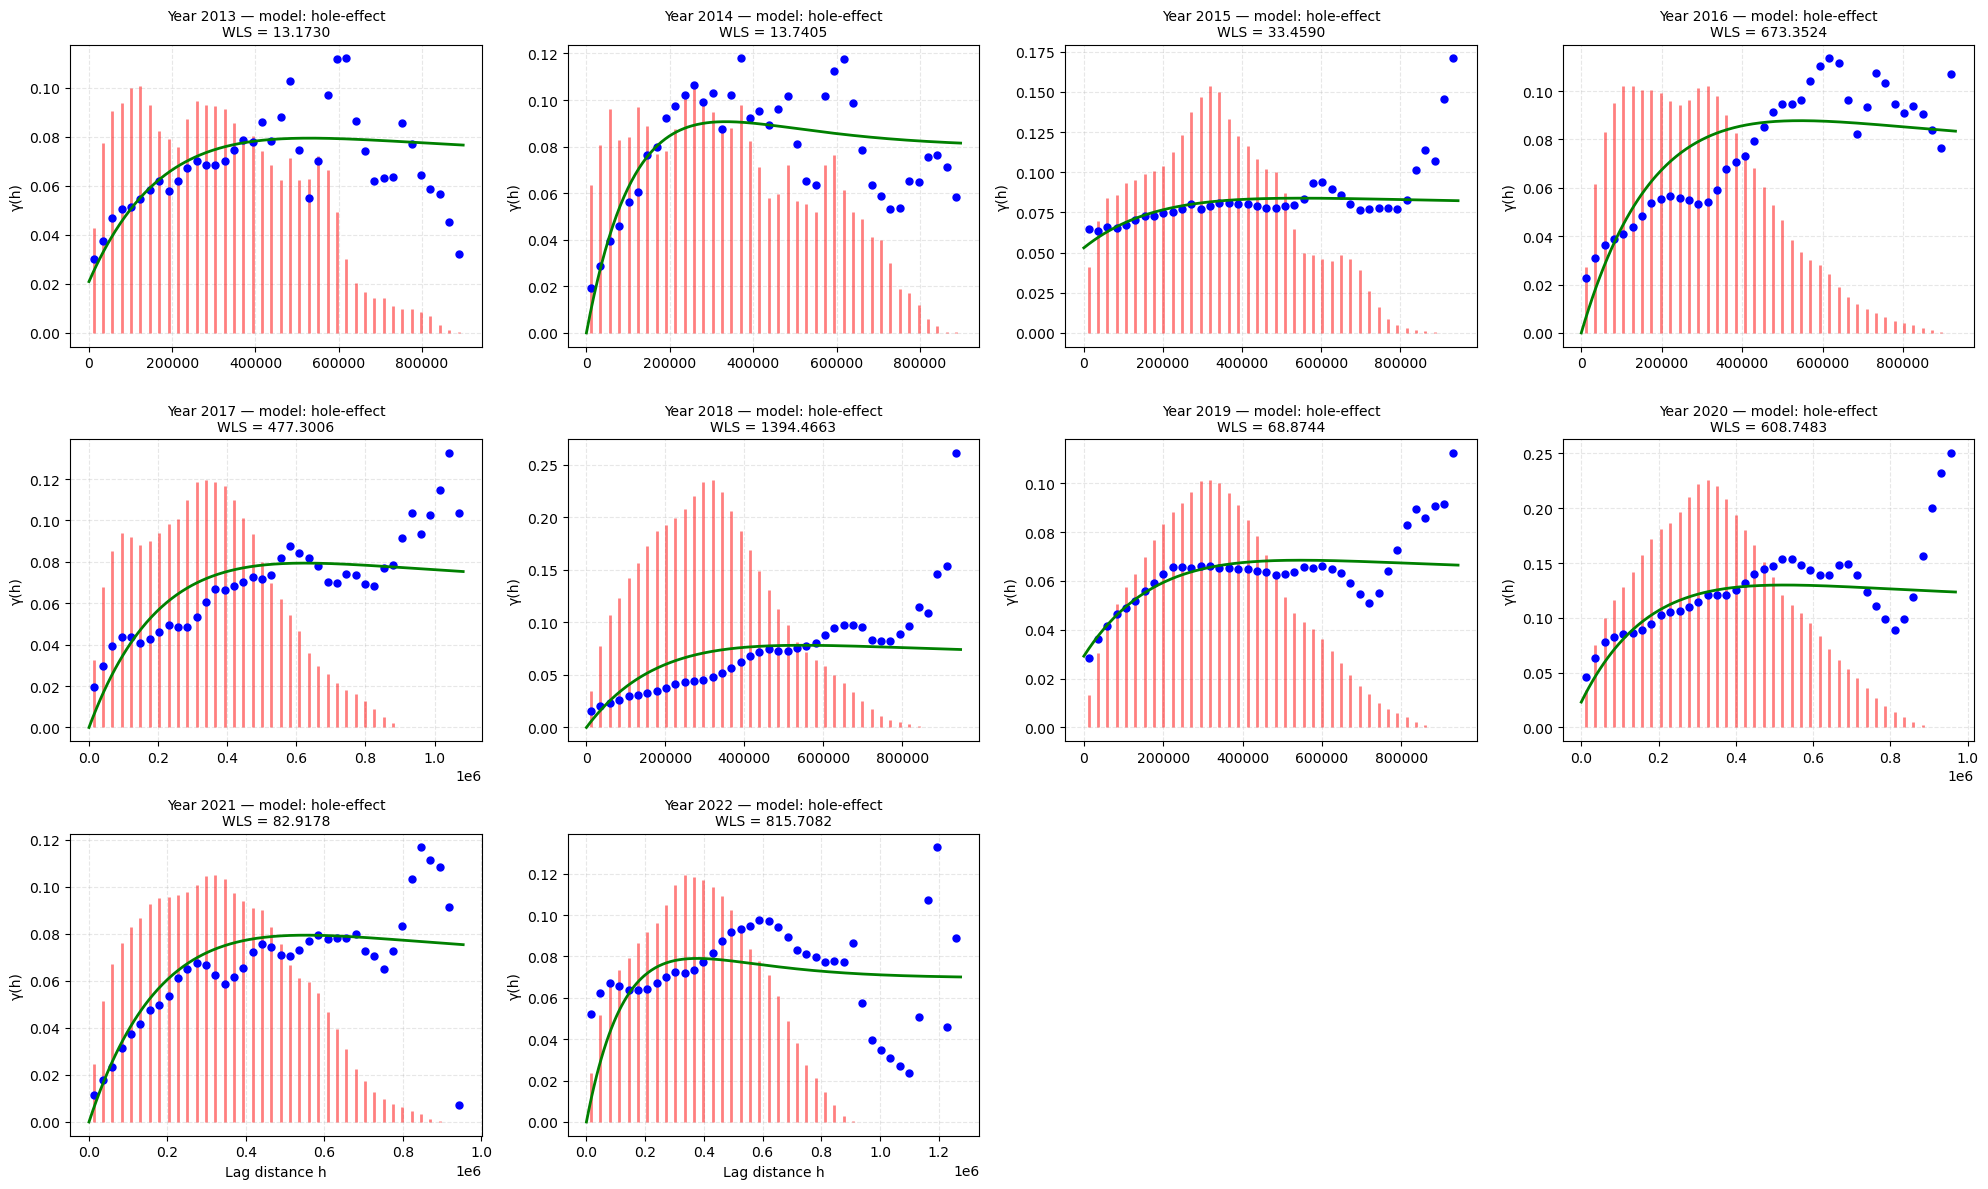


================ WLS METRIC TABLE ================

        gaussian   spherical exponential       power  hole-effect   Best Model
2013   12.887563   12.264268   12.970409   14.506529    13.173029    spherical
2014   17.246987   15.428584   17.812985   31.129846    13.740484  hole-effect
2015   29.960677   27.512855   23.716127   25.659359    33.459046  exponential
2016   143.89244  153.400984  271.014083  180.181913   673.352377     gaussian
2017  142.789445  111.953936  169.668375  131.460079   477.300581    spherical
2018   45.796381  113.202429  491.291765   70.130974  1394.466305     gaussian
2019    59.69424   56.095204   113.83643  117.311216    68.874441    spherical
2020  503.267442   462.17946  660.509649  889.315605   608.748296    spherical
2021  109.840587   69.521594   43.369199   48.504304    82.917804  exponential
2022  630.204146  734.757327  791.406129  805.688175   815.708233     gaussian


In [13]:

_ = compare_variogram_models(df_train, prob_col="p_raw", year_col=year_col,
                             n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect"))


Detected years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

=== STEP 1: Annual variograms ===


=== Mean variogram computed ===


=== STEP 2: Fitting models to mean variogram ===

Model gaussian: params=[5.20625197e-02 2.95988993e+05 3.43338204e-02] → WLS=0.004144
Model spherical: params=[6.09407270e-02 2.95988993e+05 2.42923488e-02] → WLS=0.004679
Model exponential: params=[7.41543132e-02 2.95988993e+05 1.16813705e-02] → WLS=0.004583
Model power: params=[0.00492707 0.20475715 0.01117293] → WLS=0.003997
Model hole-effect: params=[5.40133055e-02 2.95988993e+05 2.36848458e-02] → WLS=0.010819


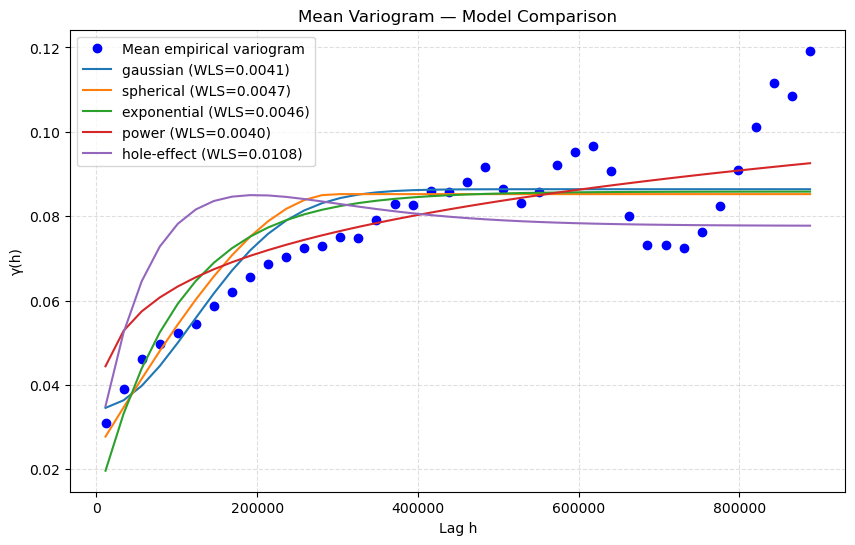


=== FINAL MODEL COMPARISON ===

                  WLS  Rank
power        0.003997   1.0
gaussian     0.004144   2.0
exponential  0.004583   3.0
spherical    0.004679   4.0
hole-effect  0.010819   5.0


In [14]:
_,_ = compare_variogram_models_with_mean(df_train, prob_col="p_raw", year_col=year_col,
                              n_bins=40, max_points=3000,
                             models=("gaussian","spherical","exponential","power","hole-effect")   )


--- COMPUTING MEAN VARIOGRAM ---
[Variogram] Fitting variogram for year 2013...
[Variogram] Fitting variogram for year 2014...
[Variogram] Fitting variogram for year 2015...
[Variogram] Fitting variogram for year 2016...
[Variogram] Fitting variogram for year 2017...
[Variogram] Fitting variogram for year 2018...
[Variogram] Fitting variogram for year 2019...
[Variogram] Fitting variogram for year 2020...
[Variogram] Fitting variogram for year 2021...
[Variogram] Fitting variogram for year 2022...

=== MEAN VARIOGRAM PARAMETERS ===
Mean range  = 554658.8692
Mean sill   = 0.0504
Mean nugget = 0.0411

--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---
[Kriging] Fitting Kriging for year 2013 with mean variogram.
[Kriging] Fitting Kriging for year 2014 with mean variogram.
[Kriging] Fitting Kriging for year 2015 with mean variogram.
[Kriging] Fitting Kriging for year 2016 with mean variogram.
[Kriging] Fitting Kriging for year 2017 with mean variogram.
[Kriging] Fitting Kriging for 

<Figure size 600x500 with 0 Axes>

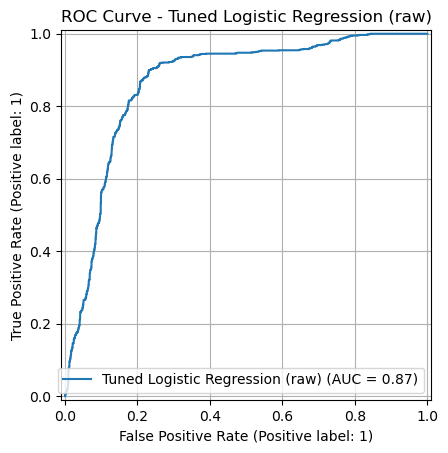

In [16]:

# 4. Mean variogram (sur TRAIN)
print("\n--- COMPUTING MEAN VARIOGRAM ---")
mean_params = compute_mean_variogram(df_train, "p_raw", year_col)

# 5. Kriging par année avec variogramme moyen (sur TRAIN)
print("\n--- FITTING PER-YEAR KRIGING MODELS (MEAN VARIOGRAM) ---")
kriging_models = fit_kriging_with_mean_variogram(
    df_train, "p_raw", mean_params, year_col
)
# 6. Application de la correction spatiale sur le TEST
print("\n--- APPLYING SPATIAL CORRECTION (TEST) ---")
df_test_corr = apply_kriging_by_year(
    df_test, "p_raw", kriging_models, year_col
)
print("\n--- CORRECTED PROBABILITY METRICS (TEST) ---")
print_metrics(df_test[target], df_test_corr["p_corr"])
plot_roc_curve(df_test[target], df_test_corr["p_corr"], model_name + " (raw)")

In [23]:

SAVE_PATH = "df_test_reconnaissance"

df_test_corr.to_csv(f"{SAVE_PATH}.csv", index=False)
print("df_test sauvegardée avec succès.")

df_test sauvegardée avec succès.


##  ***Interprétation des résultats de classification – Reconnaissance de la sécheresse***

On considère la variable cible suivante :

- **Classe 1** : sécheresse reconnue  
- **Classe 0** : absence de sécheresse reconnue  


###  ***Performance globale du modèle***

#### ***Aire sous la courbe ROC (AUC)***

$$
\text{AUC} = 0.87
$$

Cette valeur indique une **excellente capacité de discrimination** du modèle : il sépare efficacement les situations de sécheresse reconnues des situations normales, indépendamment du seuil de classification choisi.

### Rapport recapitulatif

| Classe | Precision | Recall | F1-score | Support |
|------|-----------|--------|----------|---------|
| **0 (non reconnue)** | 0.97 | 0.77 | 0.86 | 4715 |
| **1 (reconnue)** | 0.49 | 0.89 | 0.63 | 1183 |
| **Accuracy** |  |  | **0.79** | 5898 |
| **Macro avg** | 0.73 | 0.83 | 0.75 | 5898 |
| **Weighted avg** | 0.87 | 0.79 | 0.81 | 5898 |


###  ***Matrice de confusion***

| Réalité \ Prédiction | 0 | 1 |
|----------------------|---|---|
| **0 (non reconnue)** | 3629 | 1086 |
| **1 (reconnue)** | 129 | 1054 |

#### ***Interprétation des composantes***

- **Vrais négatifs (TN)** : 3629  
- **Faux positifs (FP)** : 1086  
- **Faux négatifs (FN)** : 129  
- **Vrais positifs (TP)** : 1054  



###  ***Analyse par classe***

####  ***Classe 1 – Sécheresse reconnue***

##### ***Rappel (Recall)***

$$
\text{Recall}_1 = \frac{TP}{TP + FN}
= \frac{1054}{1054 + 129}
\approx 0.89
$$

Le modèle détecte **89 % des sécheresses reconnues**, ce qui est particulièrement satisfaisant pour un phénomène à fort enjeu.



##### ***Précision*** 

$$
\text{Precision}_1 = \frac{TP}{TP + FP}
= \frac{1054}{1054 + 1086}
\approx 0.49
$$

Lorsqu’une sécheresse reconnue est prédite, elle est correcte dans environ **un cas sur deux**, traduisant une **sur-détection volontaire**.



##### ***F1-score***

$$
F1_1 \approx 0.63
$$

Ce score reflète un compromis équilibré entre un rappel élevé et une précision plus modérée.



####  ***Classe 0 – Absence de reconnaissance***

- **Précision** : $0.97$  
- **Rappel** : $0.77$

Le modèle est très fiable lorsqu’il prédit une non reconnaissance.


###  ***Effet du déséquilibre des classes***

- Observations sans reconnaissance : 4715  
- Observations avec reconnaissance : 1183  

Malgré ce déséquilibre, le modèle maintient des performances solides :

- **Accuracy** :
$$
\text{Accuracy} = 0.79
$$

- **Macro F1-score** :
$$
\text{Macro F1} = 0.75
$$

L’accuracy reste correcte, mais le **macro F1-score** confirme une performance équilibrée entre les deux classes.



###  ***Interprétation stratégique***

#### ***Points forts***
- Faible nombre de sécheresses manquées ($FN = 129$)
- Très bonne capacité discriminante ($\text{AUC} = 0.866$)
- Modèle orienté **prévention du risque**

#### ***Points de vigilance***
- Nombre important de faux positifs ($FP = 1086$)
- Risque d’alertes excessives ou de surcoûts opérationnels



###  ***Conclusion***

Le modèle adopte une stratégie **conservatrice** :

$$
\text{Maximisation du rappel} \;\Rightarrow\; \text{augmentation des faux positifs}
$$

Ce choix est **cohérent dans un contexte de gestion du risque climatique**, où le coût d’une sécheresse non reconnue est généralement supérieur à celui d’une fausse alerte.
